In [1]:
# --- Setup ---
!git clone https://github.com/MothMalone/SolutionRecommendation.git
%cd SolutionRecommendation
!pip install -q openml "autogluon.tabular"

# --- Core Python ---
import os
import shutil
import tempfile
import warnings

# --- Data & Utilities ---
import numpy as np
import pandas as pd

# --- scikit-learn ---
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder
)
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, r2_score
from sklearn.utils import shuffle
from sklearn.metrics.pairwise import cosine_similarity

# --- Optimization ---
from scipy.optimize import minimize

# --- External Libraries ---
from autogluon.tabular import TabularPredictor
import openml

# --- Config ---
warnings.filterwarnings('ignore')
predictor_path = '/kaggle/working/autogluon_models'

from autogluon.features.generators import IdentityFeatureGenerator
!pip install -U "xgboost>=2.1.4,<3.1"

Cloning into 'SolutionRecommendation'...
remote: Enumerating objects: 267, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (190/190), done.
remote: Total 267 (delta 40), reused 181 (delta 25), pack-reused 46 (from 1)
Receiving objects: 100% (267/267), 4.36 MiB | 12.11 MiB/s, done.
Resolving deltas: 100% (53/53), done.
/kaggle/working/SolutionRecommendation
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 4.6 MB/s eta 0:00:00
ERROR: 

In [ ]:
import autogluon.tabular
print(autogluon.tabular.__version__)

AUTOGLUON_CONFIG = {
    "eval_metric": "accuracy",
    "time_limit": 300,  # 5 minutes per dataset
    "presets": "medium_quality",
    "verbosity": 0,
    "hyperparameter_tune_kwargs": None,
    "ag_args_fit": {
        "ag.max_memory_usage_ratio": 0.9,
    },
    "seed": 42
}

1.5.0


In [3]:
# # Old version of preprocessing with old space

# import os
# os.environ["OMP_NUM_THREADS"] = "1"

# from xgboost import XGBRanker 
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer, KNNImputer
# from sklearn.preprocessing import (
#     StandardScaler, MinMaxScaler, RobustScaler,
#     MaxAbsScaler, OneHotEncoder, LabelEncoder
# )
# from sklearn.feature_selection import (
#     VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
# )
# from sklearn.decomposition import PCA, TruncatedSVD
# from sklearn.ensemble import IsolationForest
# from sklearn.neighbors import LocalOutlierFactor
# import numpy as np
# import pandas as pd
# from sklearn.compose import ColumnTransformer
# import category_encoders as ce


# # --------------------------
# # Preprocessing pipeline (numeric only)
# # --------------------------
# def create_preprocessing_pipeline(config):
#     """Create a scikit-learn preprocessing pipeline for numeric data only"""
#     def get_column_transformer(X):
#         numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
#         transformers = []

#         if numeric_cols:
#             numeric_steps = []

#             # Imputation
#             if config['imputation'] != 'none':
#                 if config['imputation'] in ['mean', 'median', 'most_frequent', 'constant']:
#                     numeric_steps.append(('imputer', SimpleImputer(strategy=config['imputation'])))
#                 elif config['imputation'] == 'knn':
#                     numeric_steps.append(('imputer', KNNImputer(n_neighbors=min(5, len(X) - 1))))
#                 else:
#                     numeric_steps.append(('imputer', SimpleImputer(strategy='mean')))
            
#             # Scaling
#             if config['scaling'] != 'none':
#                 if config['scaling'] == 'standard':
#                     numeric_steps.append(('scaler', StandardScaler()))
#                 elif config['scaling'] == 'minmax':
#                     numeric_steps.append(('scaler', MinMaxScaler()))
#                 elif config['scaling'] == 'robust':
#                     numeric_steps.append(('scaler', RobustScaler())) 
#                 elif config['scaling'] == 'maxabs':
#                     numeric_steps.append(('scaler', MaxAbsScaler()))
            
#             if numeric_steps:
#                 numeric_pipeline = Pipeline(numeric_steps)
#                 transformers.append(('num', numeric_pipeline, numeric_cols))
#             else:
#                 transformers.append(('num', 'passthrough', numeric_cols))

#         if not transformers:
#             return None
#         return ColumnTransformer(transformers, remainder='drop')
    
#     return get_column_transformer


# # --------------------------
# # Apply preprocessing
# # --------------------------
# def apply_preprocessing(X, y, config):
#     """Apply preprocessing pipeline based on configuration with extended methods"""
#     try:
#         X_processed = X.copy().reset_index(drop=True)
#         y_processed = pd.Series(y).reset_index(drop=True)

#         # --- Baseline ---
#         if config['name'] == 'baseline':
#             X_baseline = X_processed.copy()
#             for col in X_baseline.select_dtypes(include=['object']).columns:
#                 le = LabelEncoder()
#                 X_baseline[col] = le.fit_transform(X_baseline[col])
#             return X_baseline, y_processed

#         # --- Numeric preprocessing ---
#         preprocessor_func = create_preprocessing_pipeline(config)
#         preprocessor = preprocessor_func(X_processed)
#         if preprocessor is not None:
#             X_transformed = preprocessor.fit_transform(X_processed)
#             try:
#                 feature_names = preprocessor.get_feature_names_out()
#             except:
#                 feature_names = [f'feature_{i}' for i in range(X_transformed.shape[1])]
#             X_transformed = pd.DataFrame(X_transformed, columns=feature_names)
#         else:
#             X_transformed = X_processed.copy()

#         X_transformed = X_transformed.reset_index(drop=True)
#         y_processed = y_processed.reset_index(drop=True)

#         # --- Encoding Stage (explicit) ---
#         cat_cols = X_processed.select_dtypes(exclude=['number']).columns.tolist()
#         enc_df = None
#         if cat_cols:
#             if config["encoding"] == "onehot":
#                 enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
#                 enc_df = pd.DataFrame(enc.fit_transform(X_processed[cat_cols]))
#                 enc_df.columns = enc.get_feature_names_out(cat_cols)
#             elif config["encoding"] == "none":
#                 # Just keep categorical columns as-is
#                 enc_df = X_processed[cat_cols].copy()
#             elif config["encoding"] == "frequency":
#                 enc = ce.CountEncoder(normalize=True)
#                 enc_df = enc.fit_transform(X_processed[cat_cols])
#             elif config["encoding"] == "count":
#                 enc = ce.CountEncoder(normalize=False)
#                 enc_df = enc.fit_transform(X_processed[cat_cols])
#             elif config["encoding"] == "ordinal":
#                 enc = ce.OrdinalEncoder()
#                 enc_df = enc.fit_transform(X_processed[cat_cols])
#             elif config["encoding"] == "binary":
#                 enc = ce.BinaryEncoder()
#                 enc_df = enc.fit_transform(X_processed[cat_cols])
#             else:
#                 raise ValueError(f"Unsupported encoding type: {config['encoding']}")

#             # Drop old categorical cols and join encoded
#             X_transformed = pd.concat(
#                 [X_transformed.drop(columns=[c for c in cat_cols if c in X_transformed.columns], errors="ignore"),
#                  enc_df.reset_index(drop=True)],
#                 axis=1
#             )

#         # --- Outlier removal ---
#         if config['outlier_removal'] == 'iqr':
#             for col in X_transformed.select_dtypes(include=['number']):
#                 Q1, Q3 = X_transformed[col].quantile([0.25, 0.75])
#                 IQR = Q3 - Q1
#                 if IQR > 0:
#                     mask = (X_transformed[col] >= Q1 - 1.5 * IQR) & (X_transformed[col] <= Q3 + 1.5 * IQR)
#                     X_transformed, y_processed = X_transformed[mask], y_processed[mask]

#         elif config['outlier_removal'] == 'zscore':
#             from scipy.stats import zscore
#             z_scores = np.abs(zscore(X_transformed.select_dtypes(include=['number'])))
#             mask = (z_scores < 3).all(axis=1)
#             X_transformed, y_processed = X_transformed[mask], y_processed[mask]

#         elif config['outlier_removal'] == 'lof':
#             lof = LocalOutlierFactor(n_neighbors=20)
#             y_pred = lof.fit_predict(X_transformed.select_dtypes(include=['number']))
#             mask = y_pred == 1
#             X_transformed, y_processed = X_transformed[mask], y_processed[mask]

#         elif config['outlier_removal'] == 'isolation_forest':
#             iso = IsolationForest(contamination=0.05, random_state=42)
#             y_pred = iso.fit_predict(X_transformed.select_dtypes(include=['number']))
#             mask = y_pred == 1
#             X_transformed, y_processed = X_transformed[mask], y_processed[mask]

#         # --- Feature selection ---
#         if config['feature_selection'] == 'variance_threshold':
#             selector = VarianceThreshold(threshold=0.01)
#             X_transformed = pd.DataFrame(
#                 selector.fit_transform(X_transformed),
#                 columns=X_transformed.columns[selector.get_support()]
#             )

#         elif config['feature_selection'] == 'k_best':
#             k = min(20, X_transformed.shape[1])
#             if k > 0 and len(X_transformed) > k:
#                 selector = SelectKBest(f_classif, k=k)
#                 X_transformed = pd.DataFrame(
#                     selector.fit_transform(X_transformed, y_processed),
#                     columns=X_transformed.columns[selector.get_support()]
#                 )

#         elif config['feature_selection'] == 'mutual_info':
#             k = min(20, X_transformed.shape[1])
#             if k > 0 and len(X_transformed) > k:
#                 selector = SelectKBest(mutual_info_classif, k=k)
#                 X_transformed = pd.DataFrame(
#                     selector.fit_transform(X_transformed, y_processed),
#                     columns=X_transformed.columns[selector.get_support()]
#                 )

#         # --- Dimensionality reduction ---
#         if config['dimensionality_reduction'] in ['pca', 'svd']:
#             n_components = min(10, X_transformed.shape[1], len(X_transformed) - 1)
#             if n_components > 0:
#                 reducer = PCA(n_components=n_components) if config['dimensionality_reduction'] == 'pca' else TruncatedSVD(n_components=n_components)
#                 reducer.fit(X_transformed)
#                 X_transformed = pd.DataFrame(
#                     reducer.transform(X_transformed),
#                     index=X_transformed.index
#                 )

#         # --- Final cleanup ---
#         X_transformed = X_transformed.replace([np.inf, -np.inf], np.nan).fillna(0).reset_index(drop=True)
#         y_processed = y_processed.reset_index(drop=True)

#         return X_transformed, y_processed

#     except Exception as e:
#         print(f"Error in preprocessing {config['name']}: {e}")
#         X_fallback = X.copy()
#         for col in X_fallback.select_dtypes(include=['object']).columns:
#             le = LabelEncoder()
#             X_fallback[col] = le.fit_transform(X_fallback[col].fillna('missing'))
#         return X_fallback.reset_index(drop=True), pd.Series(y).reset_index(drop=True)

In [4]:
# # Preprocessing space of DiffPrep

# import os
# os.environ["OMP_NUM_THREADS"] = "1"

# import numpy as np
# import pandas as pd

# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer, KNNImputer
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.preprocessing import (
#     OneHotEncoder,
#     StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
#     KBinsDiscretizer
# )
# from scipy.stats import zscore
# from copy import deepcopy


# # =========================================================
# # Phase A: Imputation + One-Hot Encoding (FIXED ORDER)
# # =========================================================
# def create_preprocessing_pipeline(config):

#     def get_column_transformer(X):
#         num_cols = X.select_dtypes(include=['number']).columns.tolist()
#         cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

#         transformers = []

#         # ---------- NUMERIC ----------
#         if num_cols:
#             num_steps = []
        
#             if config['numeric_imputation'] != 'none':
#                 if config['numeric_imputation'] in ['mean', 'median', 'most_frequent']:
#                     num_steps.append(
#                         ('imputer', SimpleImputer(strategy=config['numeric_imputation']))
#                     )
#                 elif config['numeric_imputation'] == 'mode':
#                     # mode is same as most_frequent
#                     num_steps.append(
#                         ('imputer', SimpleImputer(strategy='most_frequent'))
#                     )
#                 elif config['numeric_imputation'] == 'knn':
#                     num_steps.append(
#                         ('imputer', KNNImputer(n_neighbors=min(5, len(X) - 1)))
#                     )
#                 elif config['numeric_imputation'] == 'DT':
#                     # Decision Tree based imputation
#                     num_steps.append(
#                         ('imputer', IterativeImputer(
#                             DecisionTreeRegressor(max_features='sqrt', random_state=0),
#                             random_state=0,
#                             skip_complete=True
#                         ))
#                     )
#                 elif config['numeric_imputation'] == 'MICE':
#                     # Multivariate Imputation by Chained Equations
#                     num_steps.append(
#                         ('imputer', IterativeImputer(random_state=0, skip_complete=True))
#                     )
        
#             if num_steps:
#                 transformers.append(
#                     ('num', Pipeline(num_steps), num_cols)
#                 )
#             else:
#                 transformers.append(
#                     ('num', 'passthrough', num_cols)
#                 )

#         # ---------- CATEGORICAL ----------
#         if cat_cols:
#             cat_steps = []

#             if config['categorical_imputation'] != 'none':
#                 if config['categorical_imputation'] in ['most_frequent', 'mode']:
#                     # mode and most_frequent are the same
#                     cat_steps.append(
#                         ('imputer', SimpleImputer(strategy='most_frequent'))
#                     )
#                 elif config['categorical_imputation'] in ['constant', 'dummy']:
#                     # Use 'dummy_category' as default (matching main repo)
#                     cat_steps.append(
#                         ('imputer', SimpleImputer(
#                             strategy='constant',
#                             fill_value=config.get('categorical_fill_value', 'dummy_category')
#                         ))
#                     )

#             # 🔒 Mandatory One-Hot
#             cat_steps.append(
#                 ('onehot', OneHotEncoder(
#                     handle_unknown='ignore',
#                     sparse_output=False
#                 ))
#             )

#             transformers.append(('cat', Pipeline(cat_steps), cat_cols))

#         return ColumnTransformer(transformers, remainder='drop')

#     return get_column_transformer





# # =========================================================
# # MAIN PREPROCESSOR CLASS
# # =========================================================
# class Preprocessor:
#     """
#     Sklearn-style preprocessor with fit and transform methods.
#     Mimics the main repo's pipeline structure.
#     """
#     def __init__(self, config):
#         self.config = config
#         self.impute_encoder = None
#         self.scaler = None
#         self.outlier_cleaner = None
#         self.discretizer = None
        
#     def fit(self, X, y=None):
#         """Fit all preprocessing steps on training data."""
#         X = X.reset_index(drop=True)
#         if y is not None:
#             y = pd.Series(y).reset_index(drop=True)
        
#         # ----- Phase A: Imputation + One-Hot Encoding -----
#         self.impute_encoder = create_preprocessing_pipeline(self.config)(X)
#         X_transformed = pd.DataFrame(self.impute_encoder.fit_transform(X))
        
#         # ----- Phase B: Scaling -----
#         scaler_map = {
#             'standard': StandardScaler(),
#             'minmax': MinMaxScaler(clip=True),
#             'robust': RobustScaler(),
#             'maxabs': MaxAbsScaler(),
#             'none': None
#         }
#         self.scaler = scaler_map.get(self.config['scaling'], None)
        
#         if self.scaler is not None:
#             X_transformed = pd.DataFrame(
#                 self.scaler.fit_transform(X_transformed),
#                 columns=X_transformed.columns
#             )
        
#         # ----- Phase C: Outlier Cleaning -----
#         self.outlier_cleaner = self._fit_outlier_cleaner(X_transformed)
        
#         # Only apply outlier cleaning to training data during fit
#         if self.outlier_cleaner is not None:
#             X_transformed = self._clean_outliers(X_transformed)
        
#         # ----- Phase D: Discretization -----
#         method = self.config['discretization']
#         if method != 'none':
#             strategy, n_bins = method.split('-')
#             self.discretizer = KBinsDiscretizer(
#                 n_bins=int(n_bins),
#                 encode='ordinal',
#                 strategy=strategy
#             )
#             X_transformed = pd.DataFrame(
#                 self.discretizer.fit_transform(X_transformed),
#                 columns=X_transformed.columns
#             )
        
#         return self
    
#     def transform(self, X):
#         """Transform new data using fitted parameters."""
#         X = X.reset_index(drop=True)
        
#         # ----- Phase A: Imputation + One-Hot Encoding -----
#         X_transformed = pd.DataFrame(self.impute_encoder.transform(X))
        
#         # ----- Phase B: Scaling -----
#         if self.scaler is not None:
#             X_scaled = self.scaler.transform(X_transformed)
#             X_scaled = np.clip(X_scaled, -1e10, 1e10)
#             X_transformed = pd.DataFrame(
#                 X_scaled,
#                 columns=X_transformed.columns
#             )
        
#         # ----- Phase C: Outlier Cleaning -----
#         if self.outlier_cleaner is not None:
#             X_transformed = self._clean_outliers(X_transformed)
        
#         # ----- Phase D: Discretization -----
#         if self.discretizer is not None:
#             X_transformed = pd.DataFrame(
#                 self.discretizer.transform(X_transformed),
#                 columns=X_transformed.columns
#             )
        
#         # ----- Final cleanup -----
#         X_transformed = X_transformed.replace([np.inf, -np.inf], np.nan).fillna(0)
        
#         return X_transformed.reset_index(drop=True)
    
#     def fit_transform(self, X, y=None):
#         """
#         Fit and transform in one step.
#         ALWAYS return (X_transformed, y) for consistency.
#         """
#         self.fit(X, y)
#         X_transformed = self.transform(X)
    
#         if y is not None:
#             y = pd.Series(y).reset_index(drop=True)
    
#         return X_transformed, y

    
    # def _fit_outlier_cleaner(self, X):
    #     """Fit the outlier detection/cleaning parameters."""
    #     method = self.config['outlier_cleaning']
        
    #     if method == 'none':
    #         return None
        
    #     X_array = X.values
        
    #     cleaner_params = {}
        
    #     # ---------- Z-SCORE ----------
    #     # Support both "zscore-3" (your format) and "ZS_3" (repo format)
    #     if method.startswith('zscore') or (method.startswith('ZS') and '_' in method):
    #         if '-' in method:
    #             nstd = float(method.split('-')[1])
    #         else:
    #             nstd = float(method.split('_')[1])
    #         mean = X_array.mean(axis=0)
    #         std = X_array.std(axis=0)
    #         cut_off = std * nstd
    #         cleaner_params['lower'] = (mean - cut_off).reshape(1, -1)
    #         cleaner_params['upper'] = (mean + cut_off).reshape(1, -1)
    #         cleaner_params['method'] = 'zscore'
        
    #     # ---------- IQR ----------
    #     # Support both "iqr-1.5" (your format) and "IQR_1.5" (repo format)
    #     elif method.startswith('iqr') or (method.startswith('IQR') and '_' in method):
    #         if '-' in method:
    #             k = float(method.split('-')[1])
    #         else:
    #             k = float(method.split('_')[1])
    #         q25 = np.percentile(X_array, 25, axis=0)
    #         q75 = np.percentile(X_array, 75, axis=0)
    #         iqr = q75 - q25
    #         cut_off = iqr * k
    #         cleaner_params['lower'] = (q25 - cut_off).reshape(1, -1)
    #         cleaner_params['upper'] = (q75 + cut_off).reshape(1, -1)
    #         cleaner_params['method'] = 'iqr'
        
    #     # ---------- MAD ----------
    #     # Support both "mad-2.5" (your format) and "MAD_2.5" (repo format)
    #     elif method.startswith('mad') or (method.startswith('MAD') and '_' in method):
    #         if '-' in method:
    #             nmad = float(method.split('-')[1])
    #         else:
    #             nmad = float(method.split('_')[1])
    #         median = np.median(X_array, axis=0, keepdims=True)
    #         mad = np.median(np.abs(X_array - median), axis=0, keepdims=True)
    #         cleaner_params['lower'] = median - nmad * mad
    #         cleaner_params['upper'] = median + nmad * mad
    #         cleaner_params['method'] = 'mad'
        
    #     else:
    #         raise ValueError(f"Unknown outlier cleaning method: {method}")
        
    #     # Fit the imputer for repairing outliers (matching repo: SimpleImputer() defaults to mean)
    #     indicator = np.logical_or(X_array > cleaner_params['upper'], X_array < cleaner_params['lower'])
    #     X_clean = deepcopy(X_array)
    #     X_clean[indicator] = np.nan
        
    #     cleaner_params['imputer'] = SimpleImputer()  # Default strategy is 'mean'
    #     cleaner_params['imputer'].fit(X_clean)
        
    #     return cleaner_params
    
    # def _clean_outliers(self, X):
    #     """Apply outlier cleaning using fitted parameters."""
    #     if self.outlier_cleaner is None:
    #         return X
        
    #     X_array = X.values
    #     indicator = np.logical_or(
    #         X_array > self.outlier_cleaner['upper'],
    #         X_array < self.outlier_cleaner['lower']
    #     )
        
    #     X_clean = deepcopy(X_array)
    #     X_clean[indicator] = np.nan
    #     X_repaired = self.outlier_cleaner['imputer'].transform(X_clean)
        
    #     return pd.DataFrame(X_repaired, columns=X.columns, index=X.index)

In [ ]:
# Our new preprocesser with old opeartor space

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy.stats import zscore
import category_encoders as ce
from copy import deepcopy


# ======================================================
# Preprocessor
# ======================================================
class Preprocessor:
    def __init__(self, config, step_order=None):
        self.config = config

        # order origin
        self.step_order = [
            "imputation",
            "scaling",
            "encoding",
            "outlier_removal",
            #"outlier_cleaning",
            "feature_selection",
            "dimensionality_reduction"
        ]
        
        self.fitted = False

        # Saved transformers
        self.num_imputer = None
        self.cat_imputer = None
        self.encoder = None
        self.selector = None
        self.scaler = None
        self.reducer = None

        self.selected_columns_ = None
        self.num_cols = None
        self.cat_cols = None
        self.num_columns_ = None
        self.cat_columns_ = None

        self.outlier_cleaner_num = None
        self.outlier_cleaner_cat = None

    
    # ==================================================
    # FIT
    # ==================================================
    def fit_transform(self, X, y=None):
        self.num_cols = X.select_dtypes(include=['number']).columns.tolist()
        self.cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

        X_num = X[self.num_cols].copy() if self.num_cols else None
        X_cat = X[self.cat_cols].copy() if self.cat_cols else None

        for step in self.step_order:

            if step == "imputation":
                X_num, X_cat = self._fit_imputation(X_num, X_cat)

            elif step == "outlier_removal":
                X_num, X_cat, y = self._fit_outlier_removal(X_num, X_cat, y)

            elif step == "outlier_cleaning":
                X_num, X_cat = self._fit_outlier_cleaning(X_num, X_cat)
                
            elif step == "encoding":
                X_cat = self._fit_encoding(X_cat)

            elif step == "feature_selection":
                X_num, X_cat = self._fit_feature_selection(X_num, X_cat, y)

            elif step == "scaling":
                X_num = self._fit_scaling(X_num)

            elif step == "dimensionality_reduction":
                X_num = self._fit_dim_reduction(X_num)

        if X_num is not None:
            X_num.columns = X_num.columns.astype(str)  # 🔧
        if X_cat is not None:
            X_cat.columns = X_cat.columns.astype(str)  # 🔧

        
        # Merge num + cat
        X_out = None
        if X_cat is not None and X_num is not None:
            X_out = pd.concat([X_num, X_cat], axis=1)
        elif X_num is not None:
            X_out = X_num
        elif X_cat is not None:
            X_out = X_cat

        
        self.fitted = True
        return X_out, y

    # ==================================================
    # TRANSFORM
    # ==================================================
    def transform(self, X):
        assert self.fitted, "You must call fit() before transform()"

        X_num = X[self.num_cols].copy() if self.num_cols else None
        X_cat = X[self.cat_cols].copy() if self.cat_cols else None

        for step in self.step_order:
            if step == "imputation":
                X_num, X_cat = self._transform_imputation(X_num, X_cat)

            elif step == "outlier_removal":
                # NO removal on test
                pass

            elif step == "outlier_cleaning":
                X_num, X_cat = self._transform_outlier_cleaning(X_num, X_cat)
                
            elif step == "encoding":
                X_cat = self._transform_encoding(X_cat)

            elif step == "feature_selection":
                X_num, X_cat = self._transform_feature_selection(X_num, X_cat)

            elif step == "scaling":
                X_num = self._transform_scaling(X_num)

            elif step == "dimensionality_reduction":
                X_num = self._transform_dim_reduction(X_num)

        if X_num is not None:
            X_num.columns = X_num.columns.astype(str)  # 🔧
        if X_cat is not None:
            X_cat.columns = X_cat.columns.astype(str)  # 🔧

        if X_cat is not None and X_num is not None:
            return pd.concat([X_num, X_cat], axis=1).reset_index(drop=True)

        if X_cat is not None:
            return X_cat.reset_index(drop=True)

        return X_num.reset_index(drop=True)

    # ======================================================
    # STEP IMPLEMENTATIONS
    # ======================================================

    # -----------------------------
    # 1. Imputation
    # -----------------------------
    def _fit_imputation(self, X_num, X_cat):
        method = self.config["imputation"]
    
        # --- numeric imputer ---
        if X_num is not None and method != "none":
            if method == "knn":
                self.num_imputer = KNNImputer(
                    n_neighbors=min(5, len(X_num) - 1)
                )
            elif method in ["mean", "median", "most_frequent", "constant"]:
                self.num_imputer = SimpleImputer(strategy=method)
            else:
                self.num_imputer = SimpleImputer(strategy="mean")
    
            X_num = pd.DataFrame(
                self.num_imputer.fit_transform(X_num),
                index=X_num.index,
                columns=X_num.columns
            )
    
        # --- categorical imputer ---
        if X_cat is not None and method != "none":
            self.cat_imputer = SimpleImputer(strategy="most_frequent")

            X_cat = pd.DataFrame(
                self.cat_imputer.fit_transform(X_cat),
                index=X_cat.index,
                columns=X_cat.columns
            )
            
        return X_num, X_cat
    

    def _transform_imputation(self, X_num, X_cat):
        # numeric
        if X_num is not None and self.num_imputer is not None:
            X_num = pd.DataFrame(
                self.num_imputer.transform(X_num),
                index=X_num.index,
                columns=X_num.columns
            )
                
        # categorical
        if X_cat is not None and self.cat_imputer is not None:

            X_cat = pd.DataFrame(
                self.cat_imputer.transform(X_cat),
                index=X_cat.index,
                columns=X_cat.columns
            )
        return X_num, X_cat

    
    def _fit_outlier_removal(self, X_num, X_cat, y):
        method = self.config["outlier_removal"]
        if X_num is None or method == "none":
            return X_num, X_cat, y
    
       
        if X_num is not None:
            X_num = X_num.reset_index(drop=True)
        if X_cat is not None:
            X_cat = X_cat.reset_index(drop=True)
        if y is not None:
            y = y.reset_index(drop=True)
    
        # --- compute mask ---
        if method == "iqr":
            mask = pd.Series(True, index=X_num.index)
            for col in X_num.columns:
                Q1, Q3 = X_num[col].quantile([0.25, 0.75])
                IQR = Q3 - Q1
                if IQR > 0:
                    mask &= (X_num[col] >= Q1 - 1.5 * IQR) & (X_num[col] <= Q3 + 1.5 * IQR)
    
        elif method == "zscore":
            Z = np.abs(zscore(X_num))
            mask = pd.Series((Z < 3).all(axis=1), index=X_num.index)
    
        elif method == "lof":
            lof = LocalOutlierFactor(n_neighbors=20)
            mask = pd.Series(lof.fit_predict(X_num) == 1, index=X_num.index)
    
        elif method == "isolation_forest":
            iso = IsolationForest(contamination=0.05, random_state=42)
            mask = pd.Series(iso.fit_predict(X_num) == 1, index=X_num.index)
    
        # --- apply mask safely ---
        X_num = X_num.loc[mask].reset_index(drop=True)
        if X_cat is not None:
            X_cat = X_cat.loc[mask].reset_index(drop=True)
        if y is not None:
            y = y.loc[mask].reset_index(drop=True)
    
        return X_num, X_cat, y

    
    def _fit_outlier_cleaning(self, X_num, X_cat):
        method = self.config.get("outlier_cleaning", "none")
    
        # reset state
        self.outlier_cleaner_num = None
        self.outlier_cleaner_cat = None
    
        if method == "none":
            return X_num, X_cat
    
        # check encoded categorical
        is_cat_encoded = (
            X_cat is not None
            and all(pd.api.types.is_numeric_dtype(X_cat[c]) for c in X_cat.columns)
        )
    
        # ------------------------------------------------
        # internal helper
        # ------------------------------------------------
        def _fit_cleaner(X):
            X_array = X.values.astype(float)
            params = {}
    
            # ---------- CELL-WISE METHODS ----------
            if method.startswith("zscore"):
                nstd = float(method.split("-")[1]) if "-" in method else 3.0
                mean = X_array.mean(axis=0)
                std = X_array.std(axis=0)
                cut = std * nstd
                params["lower"] = (mean - cut).reshape(1, -1)
                params["upper"] = (mean + cut).reshape(1, -1)
                params["mode"] = "cell"
    
            elif method.startswith("iqr"):
                k = float(method.split("-")[1]) if "-" in method else 1.5
                q25 = np.percentile(X_array, 25, axis=0)
                q75 = np.percentile(X_array, 75, axis=0)
                iqr = q75 - q25
                cut = iqr * k
                params["lower"] = (q25 - cut).reshape(1, -1)
                params["upper"] = (q75 + cut).reshape(1, -1)
                params["mode"] = "cell"
    
            elif method.startswith("mad"):
                nmad = float(method.split("-")[1]) if "-" in method else 2.5
                median = np.median(X_array, axis=0, keepdims=True)
                mad = np.median(np.abs(X_array - median), axis=0, keepdims=True)
                params["lower"] = median - nmad * mad
                params["upper"] = median + nmad * mad
                params["mode"] = "cell"
    
            # ---------- ROW-WISE METHODS ----------
            elif method == "lof":
                lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
                lof.fit(X_array)
                params["model"] = lof
                params["mode"] = "row"
    
            elif method == "isolation_forest":
                iso = IsolationForest(contamination=0.05, random_state=42)
                iso.fit(X_array)
                params["model"] = iso
                params["mode"] = "row"
    
            else:
                raise ValueError(f"Unknown outlier_cleaning method: {method}")
    
            # ---------- FIT IMPUTER ----------
            X_tmp = deepcopy(X_array)
    
            if params["mode"] == "cell":
                mask = (X_tmp < params["lower"]) | (X_tmp > params["upper"])
                X_tmp[mask] = np.nan
            else:
                row_mask = params["model"].predict(X_tmp) == -1
                X_tmp[row_mask, :] = np.nan
    
            params["imputer"] = SimpleImputer(strategy="mean")
            params["imputer"].fit(X_tmp)
    
            return params
    
        # ------------------------------------------------
        # FIT CLEANERS
        # ------------------------------------------------
        if X_num is not None:
            self.outlier_cleaner_num = _fit_cleaner(X_num)
    
        if is_cat_encoded:
            self.outlier_cleaner_cat = _fit_cleaner(X_cat)
    
        return X_num, X_cat
    
    def _transform_outlier_cleaning(self, X_num, X_cat):
    
        is_cat_encoded = (
            X_cat is not None
            and all(pd.api.types.is_numeric_dtype(X_cat[c]) for c in X_cat.columns)
        )
    
        def _apply_cleaner(X, cleaner):
            if cleaner is None:
                return X
    
            X_array = X.values.astype(float)
    
            if cleaner["mode"] == "cell":
                indicator = (X_array < cleaner["lower"]) | (X_array > cleaner["upper"])
                X_array[indicator] = np.nan
    
            else:  # row-wise
                model = cleaner["model"]
                row_mask = model.predict(X_array) == -1
                X_array[row_mask, :] = np.nan
    
            X_repaired = cleaner["imputer"].transform(X_array)
            return pd.DataFrame(X_repaired, columns=X.columns, index=X.index)
    
        if X_num is not None:
            X_num = _apply_cleaner(X_num, self.outlier_cleaner_num)
    
        if is_cat_encoded:
            X_cat = _apply_cleaner(X_cat, self.outlier_cleaner_cat)
    
        return X_num, X_cat


    
    # -----------------------------
    # 3. Encoding
    # -----------------------------
    def _fit_encoding(self, X_cat):
        if X_cat is None or self.config["encoding"] == "none":
            return X_cat

        method = self.config["encoding"]

        if method == "onehot":
            self.encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
            arr = self.encoder.fit_transform(X_cat)
            return pd.DataFrame(
                arr,
                index=X_cat.index,  # 🔥 THIS IS THE KEY
                columns=self.encoder.get_feature_names_out(X_cat.columns)
            )

        elif method == "frequency":
            self.encoder = ce.CountEncoder(normalize=True)
        elif method == "count":
            self.encoder = ce.CountEncoder(normalize=False)
        elif method == "ordinal":
            self.encoder = ce.OrdinalEncoder()
        elif method == "binary":
            self.encoder = ce.BinaryEncoder()
        else:
            self.encoder = ce.OrdinalEncoder()

        return self.encoder.fit_transform(X_cat)

    def _transform_encoding(self, X_cat):
        if X_cat is None or self.encoder is None:
            return X_cat

        arr = self.encoder.transform(X_cat)

        if hasattr(self.encoder, "get_feature_names_out"):
            return pd.DataFrame(
                arr,
                index=X_cat.index,
                columns=self.encoder.get_feature_names_out()
            )
            
        return pd.DataFrame(arr, index=X_cat.index)

    # -----------------------------
    # 4. FEATURE SELECTION (FIT)
    # -----------------------------
    def _fit_feature_selection(self, X_num, X_cat, y):
        fs = self.config["feature_selection"]

        # reset state
        self.selector = None
        self.selected_columns_ = None
        self.num_columns_ = pd.Index([])
        self.cat_columns_ = pd.Index([])

        if fs == "none":
            return X_num, X_cat

        # check if categorical is already encoded
        is_cat_encoded = (
            X_cat is not None
            and all(pd.api.types.is_numeric_dtype(X_cat[c]) for c in X_cat.columns)
        )

        # nothing to select from
        if X_num is None and not is_cat_encoded:
            return X_num, X_cat

        # build X_all (IMPORTANT: deterministic order)
        if X_num is not None and is_cat_encoded:
            X_all = pd.concat([X_num, X_cat], axis=1)
            self.num_columns_ = X_num.columns
            self.cat_columns_ = X_cat.columns

        elif X_num is not None:
            X_all = X_num.copy()
            self.num_columns_ = X_num.columns

        else:
            X_all = X_cat.copy()
            self.cat_columns_ = X_cat.columns

        # -----------------------------
        # SELECTOR
        # -----------------------------
        if fs == "variance_threshold":
            self.selector = VarianceThreshold(threshold=0.01)
            self.selector.fit(X_all)

        else:
            k = min(20, X_all.shape[1])

            if fs == "k_best":
                self.selector = SelectKBest(f_classif, k=k)
                self.selector.fit(X_all, y.values.ravel())

            elif fs == "mutual_info":
                self.selector = SelectKBest(
                    lambda X, y: mutual_info_classif(
                        X,
                        y,
                        discrete_features="auto"
                    ),
                    k=k
                )
                self.selector.fit(X_all, y.values.ravel())

            else:
                raise ValueError(f"Unknown feature_selection: {fs}")

        # -----------------------------
        # STORE SELECTED COLUMNS
        # -----------------------------
        support = self.selector.get_support()
        self.selected_columns_ = X_all.columns[support]

        X_selected = X_all[self.selected_columns_]

        # split back safely by column name
        X_num_sel = (
            X_selected[self.selected_columns_.intersection(self.num_columns_)]
            if len(self.num_columns_) > 0 else None
        )

        X_cat_sel = (
            X_selected[self.selected_columns_.intersection(self.cat_columns_)]
            if is_cat_encoded else X_cat
        )

        return X_num_sel, X_cat_sel

    # -----------------------------
    # FEATURE SELECTION (TRANSFORM)
    # -----------------------------
    def _transform_feature_selection(self, X_num, X_cat):
        if self.selector is None:
            return X_num, X_cat

        is_cat_encoded = (
            X_cat is not None
            and all(pd.api.types.is_numeric_dtype(X_cat[c]) for c in X_cat.columns)
        )

        # rebuild X_all in the SAME ORDER as fit
        if len(self.num_columns_) > 0 and len(self.cat_columns_) > 0:
            X_all = pd.concat(
                [X_num[self.num_columns_], X_cat[self.cat_columns_]],
                axis=1
            )
        elif len(self.num_columns_) > 0:
            X_all = X_num[self.num_columns_]
        else:
            X_all = X_cat[self.cat_columns_]

        # transform
        arr = self.selector.transform(X_all)

        X_selected = pd.DataFrame(
            arr,
            index=X_all.index,
            columns=self.selected_columns_
        )

        # split back safely
        X_num_sel = (
            X_selected[self.selected_columns_.intersection(self.num_columns_)]
            if len(self.num_columns_) > 0 else None
        )

        X_cat_sel = (
            X_selected[self.selected_columns_.intersection(self.cat_columns_)]
            if is_cat_encoded else X_cat
        )

        return X_num_sel, X_cat_sel
        
    # -----------------------------
    # 5. Scaling
    # -----------------------------
    def _fit_scaling(self, X):
        method = self.config["scaling"]
        if X is None or method == "none":
            return X

        self.scaler = {
            "standard": StandardScaler(),
            "minmax": MinMaxScaler(),
            "robust": RobustScaler(),
            "maxabs": MaxAbsScaler(),
        }.get(method)

        if self.scaler:
            return pd.DataFrame(self.scaler.fit_transform(X), index=X.index, columns=X.columns)
        return X

    def _transform_scaling(self, X):
        if X is None or self.scaler is None:
            return X
        return pd.DataFrame(self.scaler.transform(X), index=X.index, columns=X.columns)

    # -----------------------------
    # 6. Dimensionality Reduction
    # -----------------------------
    def _fit_dim_reduction(self, X):
        dr = self.config["dimensionality_reduction"]
        if (
            X is None
            or dr == "none"
            or X.shape[1] <= 1
            or len(X) < 2
        ):
            self.reducer = None
            return X

        n_components = min(10, X.shape[1], len(X)-1)

        if dr == "pca":
            self.reducer = PCA(n_components=n_components)
        else:
            self.reducer = TruncatedSVD(n_components=n_components)

        arr = self.reducer.fit_transform(X)
        return pd.DataFrame(arr, index=X.index)

    def _transform_dim_reduction(self, X):
        if X is None or self.reducer is None:
            return X
        arr = self.reducer.transform(X)
        return pd.DataFrame(arr, index=X.index)

In [ ]:
# ==================================================
# ADD: Operator Space + Preprocessor Selector
#      Switch between CURRENT and DIFFPREP easily
# ==================================================

# ADD: Choose operator space here
PREPROCESSOR_VARIANT = "diffprep"  # CHANGE: "current" or "diffprep"

# ADD: Keep a handle to the current (existing) Preprocessor
Preprocessor_Current = Preprocessor

# ADD: DiffPrep operator space + Preprocessor (self-contained)
import numpy as np
import pandas as pd
from copy import deepcopy
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
    KBinsDiscretizer
)

# ADD: DiffPrep operator space
DIFFPREP_PIPELINE_OPTIONS = {
    "numeric_imputation": ["none", "mean", "median", "most_frequent", "mode", "knn", "DT", "MICE"],
    "categorical_imputation": ["none", "most_frequent", "mode", "constant", "dummy"],
    "scaling": ["none", "standard", "minmax", "robust", "maxabs"],
    "outlier_cleaning": ["none", "zscore-3", "iqr-1.5", "iqr-2", "mad-2.5"],
    "discretization": ["none", "uniform-10", "quantile-10"]
}

# ADD: Optional curated DiffPrep configs
DIFFPREP_PIPELINE_CONFIGS = [
    {"name": "baseline", "numeric_imputation": "none", "categorical_imputation": "none", "scaling": "none", "outlier_cleaning": "none", "discretization": "none"},
    {"name": "mean_standard", "numeric_imputation": "mean", "categorical_imputation": "most_frequent", "scaling": "standard", "outlier_cleaning": "none", "discretization": "none"},
    {"name": "median_robust", "numeric_imputation": "median", "categorical_imputation": "most_frequent", "scaling": "robust", "outlier_cleaning": "none", "discretization": "none"},
    {"name": "iqr_1_5_robust", "numeric_imputation": "median", "categorical_imputation": "most_frequent", "scaling": "robust", "outlier_cleaning": "iqr-1.5", "discretization": "none"},
    {"name": "zscore_3_standard", "numeric_imputation": "mean", "categorical_imputation": "most_frequent", "scaling": "standard", "outlier_cleaning": "zscore-3", "discretization": "none"},
    {"name": "uniform_10_bins", "numeric_imputation": "mean", "categorical_imputation": "most_frequent", "scaling": "none", "outlier_cleaning": "none", "discretization": "uniform-10"},
    {"name": "quantile_10_bins", "numeric_imputation": "median", "categorical_imputation": "most_frequent", "scaling": "none", "outlier_cleaning": "none", "discretization": "quantile-10"},
    {"name": "safe_full", "numeric_imputation": "median", "categorical_imputation": "dummy", "scaling": "robust", "outlier_cleaning": "iqr-1.5", "discretization": "none"},
]

# ADD: DiffPrep preprocessing builder
def create_preprocessing_pipeline(config):
    # FIX: guard defaults to avoid KeyError
    num_imp = config.get("numeric_imputation", "none")
    cat_imp = config.get("categorical_imputation", "none")

    def get_column_transformer(X):
        num_cols = X.select_dtypes(include=["number"]).columns.tolist()
        cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

        transformers = []

        # ---------- NUMERIC ----------
        if num_cols:
            num_steps = []
            if num_imp != "none":
                if num_imp in ["mean", "median", "most_frequent"]:
                    num_steps.append(("imputer", SimpleImputer(strategy=num_imp)))
                elif num_imp == "mode":
                    num_steps.append(("imputer", SimpleImputer(strategy="most_frequent")))
                elif num_imp == "knn":
                    num_steps.append(("imputer", KNNImputer(n_neighbors=min(5, len(X) - 1))))
                elif num_imp == "DT":
                    num_steps.append(("imputer", IterativeImputer(
                        DecisionTreeRegressor(max_features="sqrt", random_state=0),
                        random_state=0,
                        skip_complete=True
                    )))
                elif num_imp == "MICE":
                    num_steps.append(("imputer", IterativeImputer(random_state=0, skip_complete=True)))

            transformers.append(("num", Pipeline(num_steps) if num_steps else "passthrough", num_cols))

        # ---------- CATEGORICAL ----------
        if cat_cols:
            cat_steps = []
            if cat_imp != "none":
                if cat_imp in ["most_frequent", "mode"]:
                    cat_steps.append(("imputer", SimpleImputer(strategy="most_frequent")))
                elif cat_imp in ["constant", "dummy"]:
                    cat_steps.append(("imputer", SimpleImputer(
                        strategy="constant",
                        fill_value=config.get("categorical_fill_value", "dummy_category")
                    )))

            # 🔒 Mandatory One-Hot
            cat_steps.append(("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)))
            transformers.append(("cat", Pipeline(cat_steps), cat_cols))

        return ColumnTransformer(transformers, remainder="drop")

    return get_column_transformer

# ADD: DiffPrep Preprocessor
class Preprocessor_DiffPrep:
    def __init__(self, config):
        self.config = config
        self.impute_encoder = None
        self.scaler = None
        self.outlier_cleaner = None
        self.discretizer = None

    def fit(self, X, y=None):
        X = X.reset_index(drop=True)
        if y is not None:
            y = pd.Series(y).reset_index(drop=True)

        # ----- Phase A: Imputation + One-Hot Encoding -----
        self.impute_encoder = create_preprocessing_pipeline(self.config)(X)
        X_transformed = pd.DataFrame(self.impute_encoder.fit_transform(X))

        # ----- Phase B: Scaling -----
        scaling = self.config.get("scaling", "none")
        scaler_map = {
            "standard": StandardScaler(),
            "minmax": MinMaxScaler(clip=True),
            "robust": RobustScaler(),
            "maxabs": MaxAbsScaler(),
            "none": None
        }
        self.scaler = scaler_map.get(scaling, None)
        if self.scaler is not None:
            X_transformed = pd.DataFrame(self.scaler.fit_transform(X_transformed), columns=X_transformed.columns)

        # ----- Phase C: Outlier Cleaning -----
        self.outlier_cleaner = self._fit_outlier_cleaner(X_transformed)
        if self.outlier_cleaner is not None:
            X_transformed = self._clean_outliers(X_transformed)

        # ----- Phase D: Discretization -----
        method = self.config.get("discretization", "none")
        if method != "none":
            strategy, n_bins = method.split("-")
            self.discretizer = KBinsDiscretizer(n_bins=int(n_bins), encode="ordinal", strategy=strategy)
            X_transformed = pd.DataFrame(self.discretizer.fit_transform(X_transformed), columns=X_transformed.columns)

        # FIX: consistent cleanup
        X_transformed = X_transformed.replace([np.inf, -np.inf], np.nan).fillna(0)
        return self

    def transform(self, X):
        X = X.reset_index(drop=True)
        X_transformed = pd.DataFrame(self.impute_encoder.transform(X))

        if self.scaler is not None:
            X_scaled = self.scaler.transform(X_transformed)
            X_scaled = np.clip(X_scaled, -1e10, 1e10)
            X_transformed = pd.DataFrame(X_scaled, columns=X_transformed.columns)

        if self.outlier_cleaner is not None:
            X_transformed = self._clean_outliers(X_transformed)

        if self.discretizer is not None:
            X_transformed = pd.DataFrame(self.discretizer.transform(X_transformed), columns=X_transformed.columns)

        X_transformed = X_transformed.replace([np.inf, -np.inf], np.nan).fillna(0)
        return X_transformed.reset_index(drop=True)

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        X_transformed = self.transform(X)
        if y is not None:
            y = pd.Series(y).reset_index(drop=True)
        return X_transformed, y

    # ADD: Outlier cleaning methods
    def _fit_outlier_cleaner(self, X):
        method = self.config.get("outlier_cleaning", "none")
        if method == "none":
            return None

        X_array = X.values
        cleaner_params = {}

        if method.startswith("zscore") or (method.startswith("ZS") and "_" in method):
            nstd = float(method.split("-")[1]) if "-" in method else float(method.split("_")[1])
            mean = X_array.mean(axis=0)
            std = X_array.std(axis=0)
            cut_off = std * nstd
            cleaner_params["lower"] = (mean - cut_off).reshape(1, -1)
            cleaner_params["upper"] = (mean + cut_off).reshape(1, -1)

        elif method.startswith("iqr") or (method.startswith("IQR") and "_" in method):
            k = float(method.split("-")[1]) if "-" in method else float(method.split("_")[1])
            q25 = np.percentile(X_array, 25, axis=0)
            q75 = np.percentile(X_array, 75, axis=0)
            iqr = q75 - q25
            cut_off = iqr * k
            cleaner_params["lower"] = (q25 - cut_off).reshape(1, -1)
            cleaner_params["upper"] = (q75 + cut_off).reshape(1, -1)

        elif method.startswith("mad") or (method.startswith("MAD") and "_" in method):
            nmad = float(method.split("-")[1]) if "-" in method else float(method.split("_")[1])
            median = np.median(X_array, axis=0, keepdims=True)
            mad = np.median(np.abs(X_array - median), axis=0, keepdims=True)
            cleaner_params["lower"] = median - nmad * mad
            cleaner_params["upper"] = median + nmad * mad
        else:
            raise ValueError(f"Unknown outlier cleaning method: {method}")

        indicator = np.logical_or(X_array > cleaner_params["upper"], X_array < cleaner_params["lower"])
        X_clean = deepcopy(X_array)
        X_clean[indicator] = np.nan

        cleaner_params["imputer"] = SimpleImputer()
        cleaner_params["imputer"].fit(X_clean)
        return cleaner_params

    def _clean_outliers(self, X):
        if self.outlier_cleaner is None:
            return X
        X_array = X.values
        indicator = np.logical_or(
            X_array > self.outlier_cleaner["upper"],
            X_array < self.outlier_cleaner["lower"]
        )
        X_clean = deepcopy(X_array)
        X_clean[indicator] = np.nan
        X_repaired = self.outlier_cleaner["imputer"].transform(X_clean)
        return pd.DataFrame(X_repaired, columns=X.columns, index=X.index)

# FIX: Apply chosen operator space globally
if PREPROCESSOR_VARIANT == "diffprep":
    Preprocessor = Preprocessor_DiffPrep
    pipeline_options = DIFFPREP_PIPELINE_OPTIONS
    pipeline_configs = DIFFPREP_PIPELINE_CONFIGS
else:
    Preprocessor = Preprocessor_Current
    # NOTE: keep your existing pipeline_options/pipeline_configs below if defined later

print(f"[INFO] Active Preprocessor: {PREPROCESSOR_VARIANT}")


In [ ]:
# --- YData Profiling utilities ---
try:
    from ydata_profiling import ProfileReport
except Exception:
    !pip install -q ydata-profiling
    from ydata_profiling import ProfileReport

import re

def _slugify(value):
    return re.sub(r'[^A-Za-z0-9_-]+', '_', str(value)).strip('_')

def _build_profile_df(dataset):
    X = dataset["X"].copy()
    y = dataset["y"].copy()
    df = X.copy()
    df["target"] = y
    return df

def _apply_pipeline_for_profile(dataset, pipeline_config):
    pre = Preprocessor(pipeline_config)
    X_proc, y_proc = pre.fit_transform(dataset["X"].copy(), dataset["y"].copy())
    df = X_proc.copy()
    df["target"] = y_proc
    return df

def _save_profile(df, title, filename, sample_n=None):
    if sample_n is not None and len(df) > sample_n:
        df = df.sample(sample_n, random_state=42)
    profile = ProfileReport(df, title=title, minimal=True, explorative=True)
    profile.to_file(filename)
    print(f"✅ Saved profile to {filename}")

ENABLE_PROFILING = True
PROFILE_SAMPLE_N = None  # set to int to subsample for speed


In [ ]:
# # Our new preprocesser with old opeartor space

# import numpy as np
# import pandas as pd

# from sklearn.impute import SimpleImputer, KNNImputer
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, OneHotEncoder
# from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
# from sklearn.decomposition import PCA, TruncatedSVD
# from sklearn.ensemble import IsolationForest
# from sklearn.neighbors import LocalOutlierFactor
# from scipy.stats import zscore
# import category_encoders as ce


# # ======================================================
# # Preprocessor
# # ======================================================
# class Preprocessor:
#     def __init__(self, config, step_order=None):
#         self.config = config

#         # order origin
#         self.step_order = [
#             "imputation",
#             "scaling",
#             "encoding",
#             "outlier_removal",
#             "feature_selection",
#             "dimensionality_reduction"
#         ]
        
#         self.fitted = False

#         # Saved transformers
#         self.imputer_num = None
#         self.imputer_cat = None
#         self.encoder = None
#         self.selector = None
#         self.scaler = None
#         self.reducer = None

#         self.num_cols = None
#         self.cat_cols = None

    
#     # ==================================================
#     # FIT
#     # ==================================================
#     def fit_transform(self, X, y=None):
#         self.num_cols = X.select_dtypes(include=['number']).columns.tolist()
#         self.cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

#         X_num = X[self.num_cols].copy() if self.num_cols else None
#         X_cat = X[self.cat_cols].copy() if self.cat_cols else None

#         for step in self.step_order:
#             if step == "imputation":
#                 X_num, X_cat = self._fit_imputation(X_num, X_cat)

#             elif step == "outlier_removal":
#                 X_num, X_cat, y = self._fit_outlier_removal(X_num, X_cat, y)

#             elif step == "encoding":
#                 X_cat = self._fit_encoding(X_cat)

#             elif step == "feature_selection":
#                 X_num, X_cat = self._fit_feature_selection(X_num, X_cat, y)

#             elif step == "scaling":
#                 X_num = self._fit_scaling(X_num)

#             elif step == "dimensionality_reduction":
#                 X_num = self._fit_dim_reduction(X_num)

#         # Merge num + cat
#         X_out = None
#         if X_cat is not None and X_num is not None:
#             X_out = pd.concat([X_num, X_cat], axis=1)
#         elif X_num is not None:
#             X_out = X_num
#         elif X_cat is not None:
#             X_out = X_cat
            
#         self.fitted = True
#         return X_out, y

#     # ==================================================
#     # TRANSFORM
#     # ==================================================
#     def transform(self, X):
#         assert self.fitted, "You must call fit() before transform()"

#         X_num = X[self.num_cols].copy() if self.num_cols else None
#         X_cat = X[self.cat_cols].copy() if self.cat_cols else None

#         for step in self.step_order:
#             if step == "imputation":
#                 X_num, X_cat = self._transform_imputation(X_num, X_cat)

#             elif step == "outlier_removal":
#                 # NO removal on test
#                 pass

#             elif step == "encoding":
#                 X_cat = self._transform_encoding(X_cat)

#             elif step == "feature_selection":
#                 X_num, X_cat = self._transform_feature_selection(X_num, X_cat)

#             elif step == "scaling":
#                 X_num = self._transform_scaling(X_num)

#             elif step == "dimensionality_reduction":
#                 X_num = self._transform_dim_reduction(X_num)

#         if X_cat is not None and X_num is not None:
#             return pd.concat([X_num, X_cat], axis=1).reset_index(drop=True)

#         if X_cat is not None:
#             return X_cat.reset_index(drop=True)

#         return X_num.reset_index(drop=True)

#     # ======================================================
#     # STEP IMPLEMENTATIONS
#     # ======================================================

#     # -----------------------------
#     # 1. Imputation
#     # -----------------------------
#     def _fit_imputation(self, X_num, X_cat):
#         method = self.config["imputation"]
    
#         # --- numeric imputer ---
#         if X_num is not None and method != "none":
#             if method == "knn":
#                 self.num_imputer = KNNImputer(n_neighbors=min(5, len(X_num)-1))
#             elif method in ["mean", "median", "most_frequent", "constant"]:
#                 self.num_imputer = SimpleImputer(strategy=method)
#             else:
#                 self.num_imputer = SimpleImputer(strategy="mean")
#             X_num = pd.DataFrame(self.num_imputer.fit_transform(X_num), columns=X_num.columns)
    
#         # --- categorical imputer ---
#         if X_cat is not None and method != "none":
#             if method in ["most_frequent", "constant"]:
#                 self.cat_imputer = SimpleImputer(strategy=method, fill_value="missing")
#                 X_cat = pd.DataFrame(self.cat_imputer.fit_transform(X_cat), columns=X_cat.columns)
#             else:
#                 # unsupported → leave X_cat unchanged
#                 pass
    
#         return X_num, X_cat

#         # ---------------------------
#         # CATEGORICAL IMPUTATION
#         # ---------------------------
#         if X_cat is None or method == "none":
#             self.imputer_cat = None
#         else:
#             # always MOST FREQUENT (safe for categorical)
#             self.imputer_cat = SimpleImputer(strategy="most_frequent")
#             X_cat = pd.DataFrame(self.imputer_cat.fit_transform(X_cat),
#                                  columns=X_cat.columns)
    
#         return X_num, X_cat


#     def _transform_imputation(self, X_num, X_cat):
#         # numeric
#         if X_num is not None and self.imputer_num is not None:
#             X_num = pd.DataFrame(self.imputer_num.transform(X_num),
#                                  columns=X_num.columns)
    
#         # categorical
#         if X_cat is not None and self.imputer_cat is not None:
#             X_cat = pd.DataFrame(self.imputer_cat.transform(X_cat),
#                                  columns=X_cat.columns)
    
#         return X_num, X_cat

    
#     def _fit_outlier_removal(self, X_num, X_cat, y):
#         method = self.config["outlier_removal"]
#         if X_num is None or method == "none":
#             return X_num, X_cat, y
    
#    
#         if X_num is not None:
#             X_num = X_num.reset_index(drop=True)
#         if X_cat is not None:
#             X_cat = X_cat.reset_index(drop=True)
#         if y is not None:
#             y = y.reset_index(drop=True)
    
#         # --- compute mask ---
#         if method == "iqr":
#             mask = pd.Series(True, index=X_num.index)
#             for col in X_num.columns:
#                 Q1, Q3 = X_num[col].quantile([0.25, 0.75])
#                 IQR = Q3 - Q1
#                 if IQR > 0:
#                     mask &= (X_num[col] >= Q1 - 1.5 * IQR) & (X_num[col] <= Q3 + 1.5 * IQR)
    
#         elif method == "zscore":
#             Z = np.abs(zscore(X_num))
#             mask = pd.Series((Z < 3).all(axis=1), index=X_num.index)
    
#         elif method == "lof":
#             lof = LocalOutlierFactor(n_neighbors=20)
#             mask = pd.Series(lof.fit_predict(X_num) == 1, index=X_num.index)
    
#         elif method == "isolation_forest":
#             iso = IsolationForest(contamination=0.05, random_state=42)
#             mask = pd.Series(iso.fit_predict(X_num) == 1, index=X_num.index)
    
#         # --- apply mask safely ---
#         X_num = X_num.loc[mask].reset_index(drop=True)
#         if X_cat is not None:
#             X_cat = X_cat.loc[mask].reset_index(drop=True)
#         if y is not None:
#             y = y.loc[mask].reset_index(drop=True)
    
#         return X_num, X_cat, y

#     # -----------------------------
#     # 3. Encoding
#     # -----------------------------
#     def _fit_encoding(self, X_cat):
#         if X_cat is None or self.config["encoding"] == "none":
#             return X_cat

#         method = self.config["encoding"]

#         if method == "onehot":
#             self.encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
#             arr = self.encoder.fit_transform(X_cat)
#             return pd.DataFrame(arr, columns=self.encoder.get_feature_names_out())

#         elif method == "frequency":
#             self.encoder = ce.CountEncoder(normalize=True)
#         elif method == "count":
#             self.encoder = ce.CountEncoder(normalize=False)
#         elif method == "ordinal":
#             self.encoder = ce.OrdinalEncoder()
#         elif method == "binary":
#             self.encoder = ce.BinaryEncoder()
#         else:
#             self.encoder = ce.OrdinalEncoder()

#         return self.encoder.fit_transform(X_cat)

#     def _transform_encoding(self, X_cat):
#         if X_cat is None or self.encoder is None:
#             return X_cat

#         arr = self.encoder.transform(X_cat)

#         if hasattr(self.encoder, "get_feature_names_out"):
#             return pd.DataFrame(arr, columns=self.encoder.get_feature_names_out())
#         return pd.DataFrame(arr)

#     # -----------------------------
#     # 4. Feature Selection
#     # -----------------------------
#     def _fit_feature_selection(self, X_num, X_cat, y):
#         fs = self.config["feature_selection"]
#         if fs == "none":
#             return X_num, X_cat
    
#         # Only use X_cat if it is encoded (numeric)
#         is_cat_encoded = (
#             X_cat is not None 
#             and all(pd.api.types.is_numeric_dtype(X_cat[col]) for col in X_cat.columns)
#         )
    
#         # Build X_all
#         if X_num is None and not is_cat_encoded:
#             return X_num, X_cat     # nothing to select from
    
#         if X_num is not None and is_cat_encoded:
#             X_all = pd.concat([X_num, X_cat], axis=1)
#             num_cols_count = X_num.shape[1]
#         elif X_num is not None:
#             X_all = X_num.copy()
#             num_cols_count = X_num.shape[1]
#             X_cat = None
#         else:
#             X_all = X_cat.copy()
#             num_cols_count = 0
    
#         # -----------------------------
#         # 1. Variance Threshold
#         # -----------------------------
#         if fs == "variance_threshold":
#             self.selector = VarianceThreshold(threshold=0.01)
#             arr = self.selector.fit_transform(X_all)
#             X_selected = pd.DataFrame(arr)
    
#             mask = self.selector.get_support()
    
#             # Split back
#             if num_cols_count > 0:
#                 X_num_sel = X_selected.iloc[:, :sum(mask[:num_cols_count])]
#             else:
#                 X_num_sel = None
    
#             if is_cat_encoded:
#                 X_cat_sel = X_selected.iloc[:, sum(mask[:num_cols_count]):]
#             else:
#                 X_cat_sel = X_cat
    
#             return X_num_sel, X_cat_sel
    
#         # -----------------------------
#         # 2. K-best / Mutual Info
#         # -----------------------------
#         k = min(20, X_all.shape[1])
    
#         if fs == "k_best":
#             self.selector = SelectKBest(f_classif, k=k)
#         else:
#             self.selector = SelectKBest(mutual_info_classif, k=k)
    
#         arr = self.selector.fit_transform(X_all, y.values.ravel())
#         X_selected = pd.DataFrame(arr)
#         mask = self.selector.get_support()
    
#         # Split back
#         if num_cols_count > 0:
#             X_num_sel = X_selected.iloc[:, :sum(mask[:num_cols_count])]
#         else:
#             X_num_sel = None
    
#         if is_cat_encoded:
#             X_cat_sel = X_selected.iloc[:, sum(mask[:num_cols_count]):]
#         else:
#             X_cat_sel = X_cat  # untouched
    
#         return X_num_sel, X_cat_sel
    
    
#     # -----------------------------
#     # TRANSFORM
#     # -----------------------------
#     def _transform_feature_selection(self, X_num, X_cat):
#         if self.selector is None:
#             return X_num, X_cat
    
#         # Only use X_cat if numeric
#         is_cat_encoded = (
#             X_cat is not None 
#             and all(pd.api.types.is_numeric_dtype(X_cat[c]) for c in X_cat.columns)
#         )
    
#         if X_num is not None and is_cat_encoded:
#             X_all = pd.concat([X_num, X_cat], axis=1)
#             num_cols_count = X_num.shape[1]
#         elif X_num is not None:
#             X_all = X_num
#             num_cols_count = X_num.shape[1]
#             X_cat = None
#         else:
#             X_all = X_cat
#             num_cols_count = 0
    
#         arr = self.selector.transform(X_all)
#         X_selected = pd.DataFrame(arr)
#         mask = self.selector.get_support()
    
#         if num_cols_count > 0:
#             X_num_sel = X_selected.iloc[:, :sum(mask[:num_cols_count])]
#         else:
#             X_num_sel = None
    
#         if is_cat_encoded:
#             X_cat_sel = X_selected.iloc[:, sum(mask[:num_cols_count]):]
#         else:
#             X_cat_sel = X_cat
    
#         return X_num_sel, X_cat_sel


#     # -----------------------------
#     # 5. Scaling
#     # -----------------------------
#     def _fit_scaling(self, X):
#         method = self.config["scaling"]
#         if X is None or method == "none":
#             return X

#         self.scaler = {
#             "standard": StandardScaler(),
#             "minmax": MinMaxScaler(),
#             "robust": RobustScaler(),
#             "maxabs": MaxAbsScaler(),
#         }.get(method)

#         if self.scaler:
#             return pd.DataFrame(self.scaler.fit_transform(X), columns=X.columns)
#         return X

#     def _transform_scaling(self, X):
#         if X is None or self.scaler is None:
#             return X
#         return pd.DataFrame(self.scaler.transform(X), columns=X.columns)

#     # -----------------------------
#     # 6. Dimensionality Reduction
#     # -----------------------------
#     def _fit_dim_reduction(self, X):
#         dr = self.config["dimensionality_reduction"]
#         if X is None or dr == "none":
#             return X

#         n_components = min(10, X.shape[1], len(X)-1)

#         if dr == "pca":
#             self.reducer = PCA(n_components=n_components)
#         else:
#             self.reducer = TruncatedSVD(n_components=n_components)

#         arr = self.reducer.fit_transform(X)
#         return pd.DataFrame(arr)

#     def _transform_dim_reduction(self, X):
#         if X is None or self.reducer is None:
#             return X
#         arr = self.reducer.transform(X)
#         return pd.DataFrame(arr)

In [7]:
# Extract metafeatures

# ============================================================
# 0. Imports
# ============================================================
import pandas as pd
import numpy as np
import openml

# ============================================================
# 1. Load meta-features CSV
# ============================================================
meta_features_df = pd.read_csv(
    "/kaggle/working/SolutionRecommendation/data/openml/dataset_feats.csv",
    index_col=0
)

meta_features_df.index = meta_features_df.index.astype(int)

print("Original shape:", meta_features_df.shape)

# ============================================================
# 2. Meta-feature list (69 features)
# ============================================================
meta_feature_columns = [
    # --- general ---
    "Dimensionality",
    "NumberOfBinaryFeatures",
    "NumberOfClasses",
    "NumberOfFeatures",
    "NumberOfInstances",
    "NumberOfInstancesWithMissingValues",
    "NumberOfMissingValues",
    "NumberOfNumericFeatures",
    "NumberOfSymbolicFeatures",

    # --- statistical ---
    "AutoCorrelation",
    "MajorityClassPercentage",
    "MajorityClassSize",
    "MaxNominalAttDistinctValues",
    "MeanNominalAttDistinctValues",
    "MinNominalAttDistinctValues",
    "MinorityClassPercentage",
    "MinorityClassSize",
    "PercentageOfBinaryFeatures",
    "PercentageOfInstancesWithMissingValues",
    "PercentageOfMissingValues",
    "PercentageOfNumericFeatures",
    "PercentageOfSymbolicFeatures",
    "StdvNominalAttDistinctValues",

    # --- info-theory ---
    "ClassEntropy",

    # --- landmarking ---
    "CfsSubsetEval_DecisionStumpAUC", "CfsSubsetEval_DecisionStumpErrRate",
    "CfsSubsetEval_DecisionStumpKappa", "CfsSubsetEval_NaiveBayesAUC",
    "CfsSubsetEval_NaiveBayesErrRate", "CfsSubsetEval_NaiveBayesKappa",
    "CfsSubsetEval_kNN1NAUC", "CfsSubsetEval_kNN1NErrRate",
    "CfsSubsetEval_kNN1NKappa",

    "DecisionStumpAUC", "DecisionStumpErrRate", "DecisionStumpKappa",

    "J48.00001.AUC", "J48.00001.ErrRate", "J48.00001.Kappa",
    "J48.0001.AUC", "J48.0001.ErrRate", "J48.0001.Kappa",
    "J48.001.AUC", "J48.001.ErrRate", "J48.001.Kappa",

    "NaiveBayesAUC", "NaiveBayesErrRate", "NaiveBayesKappa",

    "REPTreeDepth1AUC", "REPTreeDepth1ErrRate", "REPTreeDepth1Kappa",
    "REPTreeDepth2AUC", "REPTreeDepth2ErrRate", "REPTreeDepth2Kappa",
    "REPTreeDepth3AUC", "REPTreeDepth3ErrRate", "REPTreeDepth3Kappa",

    "RandomTreeDepth1AUC", "RandomTreeDepth1ErrRate", "RandomTreeDepth1Kappa",
    "RandomTreeDepth2AUC", "RandomTreeDepth2ErrRate", "RandomTreeDepth2Kappa",
    "RandomTreeDepth3AUC", "RandomTreeDepth3ErrRate", "RandomTreeDepth3Kappa",

    "kNN1NAUC", "kNN1NErrRate", "kNN1NKappa"
]

# ============================================================
# 3. Filter to only those features
# ============================================================
meta_features_df = meta_features_df[meta_feature_columns]
print("Filtered shape:", meta_features_df.shape)

# ============================================================
# 4. Test dataset IDs
# ============================================================
test_dataset_ids = [
    44956,  # abalone
    1037,   # ada_prior
    42932,  # avila
    40668,  # connect-4
    1471,   # eeg
    1046,   # mozilla4
    46597,  # obesity
    802,    # pbcseq
    722,    # pol
    40685,  # shuttle
    1497,   # wall-robot-nav
    30,     # page-blocks
    42165,  # house
    41001,  # jungle_chess
    40922,  # run_or_walk
    # google
    # micro
    # uscensus
    # jungle_chess
]

# ============================================================
# 5. Find missing datasets
# ============================================================
existing_ids = set(meta_features_df.index)
missing_ids = [d for d in test_dataset_ids if d not in existing_ids]

print("Missing dataset IDs:", missing_ids)

# ============================================================
# 6. Function: load meta-features from OpenML
# ============================================================
def load_openml_metafeatures(dataset_id, meta_feature_columns):
    dataset = openml.datasets.get_dataset(dataset_id)
    qualities = dataset.qualities

    row = {}
    for col in meta_feature_columns:
        value = qualities.get(col, np.nan)
        try:
            value = float(value)
        except (TypeError, ValueError):
            value = np.nan
        row[col] = value

    return pd.DataFrame(row, index=[dataset_id])

# ============================================================
# 7. Download & append missing datasets
# ============================================================
new_rows = []

for did in missing_ids:
    try:
        print(f"Fetching meta-features for dataset {did}...")
        row_df = load_openml_metafeatures(did, meta_feature_columns)
        new_rows.append(row_df)
    except Exception as e:
        print(f"⚠️ Failed to load dataset {did}: {e}")

if new_rows:
    meta_features_df = pd.concat([meta_features_df] + new_rows, axis=0)

meta_features_df = meta_features_df.sort_index()

print("Final shape:", meta_features_df.shape)

# ============================================================
# 8. Sanity checks
# ============================================================
# All test datasets present
for did in test_dataset_ids:
    assert did in meta_features_df.index, f"Dataset {did} missing!"

# Column alignment
assert list(meta_features_df.columns) == meta_feature_columns

print("✅ All test datasets have 69 aligned meta-features")

# Optional: inspect one dataset
print("\nExample (dataset 1000 if exists):")
if 1000 in meta_features_df.index:
    print(meta_features_df.loc[1000])

Original shape: (2560, 107)
Filtered shape: (2560, 69)
Missing dataset IDs: [44956, 42932, 46597, 42165, 41001]
Fetching meta-features for dataset 44956...
Fetching meta-features for dataset 42932...
Fetching meta-features for dataset 46597...
Fetching meta-features for dataset 42165...
Fetching meta-features for dataset 41001...
Final shape: (2565, 69)
✅ All test datasets have 69 aligned meta-features

Example (dataset 1000 if exists):
Dimensionality                0.007953
NumberOfBinaryFeatures       21.000000
NumberOfClasses               2.000000
NumberOfFeatures             30.000000
NumberOfInstances          3772.000000
                              ...     
RandomTreeDepth3ErrRate       0.015642
RandomTreeDepth3Kappa         0.889279
kNN1NAUC                      0.664985
kNN1NErrRate                  0.085101
kNN1NKappa                    0.347929
Name: 1000, Length: 69, dtype: float64


In [8]:
# Extract metafeatures

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, cohen_kappa_score
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy.stats import entropy


def extract_69_metafeatures(X, y):
    """
    Extract 69 OpenML-style meta-features manually from raw data.
    Landmarking features are approximated using sklearn models.
    """

    X = pd.DataFrame(X).copy()
    y = pd.Series(y).copy()

    meta = {}

    # ============================================================
    # 1. Basic dataset characteristics
    # ============================================================
    n_instances, n_features = X.shape

    numeric_cols = X.select_dtypes(include=[np.number]).columns
    symbolic_cols = X.select_dtypes(exclude=[np.number]).columns

    meta["NumberOfInstances"] = n_instances
    meta["NumberOfFeatures"] = n_features
    meta["NumberOfNumericFeatures"] = len(numeric_cols)
    meta["NumberOfSymbolicFeatures"] = len(symbolic_cols)
    meta["NumberOfBinaryFeatures"] = sum(X[col].nunique(dropna=True) == 2 for col in X.columns)

    meta["PercentageOfNumericFeatures"] = meta["NumberOfNumericFeatures"] / max(n_features, 1)
    meta["PercentageOfSymbolicFeatures"] = meta["NumberOfSymbolicFeatures"] / max(n_features, 1)
    meta["PercentageOfBinaryFeatures"] = meta["NumberOfBinaryFeatures"] / max(n_features, 1)

    # ============================================================
    # 2. Missing values
    # ============================================================
    n_missing = X.isna().sum().sum()
    n_inst_missing = X.isna().any(axis=1).sum()

    meta["NumberOfMissingValues"] = n_missing
    meta["NumberOfInstancesWithMissingValues"] = n_inst_missing
    meta["PercentageOfMissingValues"] = n_missing / max(n_instances * n_features, 1)
    meta["PercentageOfInstancesWithMissingValues"] = n_inst_missing / max(n_instances, 1)

    # ============================================================
    # 3. Class-related features
    # ============================================================
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    class_counts = np.bincount(y_enc)
    probs = class_counts / class_counts.sum()

    meta["NumberOfClasses"] = len(class_counts)
    meta["MajorityClassSize"] = class_counts.max()
    meta["MinorityClassSize"] = class_counts.min()
    meta["MajorityClassPercentage"] = probs.max()
    meta["MinorityClassPercentage"] = probs.min()
    meta["ClassEntropy"] = entropy(probs)

    # ============================================================
    # 4. Nominal attribute statistics
    # ============================================================
    if len(symbolic_cols) > 0:
        distinct_vals = X[symbolic_cols].nunique(dropna=True)
        meta["MaxNominalAttDistinctValues"] = distinct_vals.max()
        meta["MinNominalAttDistinctValues"] = distinct_vals.min()
        meta["MeanNominalAttDistinctValues"] = distinct_vals.mean()
        meta["StdvNominalAttDistinctValues"] = distinct_vals.std()
    else:
        for k in [
            "MaxNominalAttDistinctValues",
            "MinNominalAttDistinctValues",
            "MeanNominalAttDistinctValues",
            "StdvNominalAttDistinctValues",
        ]:
            meta[k] = np.nan

    # ============================================================
    # 5. Landmarking (approximate)
    # ============================================================
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder
    
    
    def eval_model(model):
        aucs, accs, kappas = [], [], []
    
        num_cols = X.select_dtypes(include=[np.number]).columns
        cat_cols = X.select_dtypes(exclude=[np.number]).columns
    
        preprocessor = ColumnTransformer(
            transformers=[
                ("num", SimpleImputer(strategy="median"), num_cols),
                ("cat", Pipeline([
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
                ]), cat_cols),
            ],
            remainder="drop"
        )
    
        for tr, te in cv.split(X, y_enc):
            pipe = Pipeline([
                ("prep", preprocessor),
                ("mdl", model),
            ])
    
            pipe.fit(X.iloc[tr], y_enc[tr])
            preds = pipe.predict(X.iloc[te])
    
            accs.append(accuracy_score(y_enc[te], preds))
            kappas.append(cohen_kappa_score(y_enc[te], preds))
    
            if len(np.unique(y_enc)) == 2:
                probs = pipe.predict_proba(X.iloc[te])[:, 1]
                aucs.append(roc_auc_score(y_enc[te], probs))
            else:
                aucs.append(np.nan)
    
        return np.nanmean(aucs), 1 - np.nanmean(accs), np.nanmean(kappas)


    # Decision Stump
    auc, err, kap = eval_model(DecisionTreeClassifier(max_depth=1))
    meta["DecisionStumpAUC"] = auc
    meta["DecisionStumpErrRate"] = 1 - err
    meta["DecisionStumpKappa"] = kap

    # Naive Bayes
    auc, err, kap = eval_model(GaussianNB())
    meta["NaiveBayesAUC"] = auc
    meta["NaiveBayesErrRate"] = 1 - err
    meta["NaiveBayesKappa"] = kap

    # kNN (k=1)
    auc, err, kap = eval_model(KNeighborsClassifier(n_neighbors=1))
    meta["kNN1NAUC"] = auc
    meta["kNN1NErrRate"] = 1 - err
    meta["kNN1NKappa"] = kap

    # ============================================================
    # 6. Fill missing landmarking features
    # ============================================================
    for col in [
        "CfsSubsetEval_DecisionStumpAUC", "CfsSubsetEval_DecisionStumpErrRate",
        "CfsSubsetEval_DecisionStumpKappa", "CfsSubsetEval_NaiveBayesAUC",
        "CfsSubsetEval_NaiveBayesErrRate", "CfsSubsetEval_NaiveBayesKappa",
        "CfsSubsetEval_kNN1NAUC", "CfsSubsetEval_kNN1NErrRate",
        "CfsSubsetEval_kNN1NKappa",
        "J48.00001.AUC", "J48.00001.ErrRate", "J48.00001.Kappa",
        "J48.0001.AUC", "J48.0001.ErrRate", "J48.0001.Kappa",
        "J48.001.AUC", "J48.001.ErrRate", "J48.001.Kappa",
        "REPTreeDepth1AUC", "REPTreeDepth1ErrRate", "REPTreeDepth1Kappa",
        "REPTreeDepth2AUC", "REPTreeDepth2ErrRate", "REPTreeDepth2Kappa",
        "REPTreeDepth3AUC", "REPTreeDepth3ErrRate", "REPTreeDepth3Kappa",
        "RandomTreeDepth1AUC", "RandomTreeDepth1ErrRate", "RandomTreeDepth1Kappa",
        "RandomTreeDepth2AUC", "RandomTreeDepth2ErrRate", "RandomTreeDepth2Kappa",
        "RandomTreeDepth3AUC", "RandomTreeDepth3ErrRate", "RandomTreeDepth3Kappa",
        "Dimensionality", "AutoCorrelation"
    ]:
        meta[col] = np.nan

    return pd.Series(meta)

In [9]:
# Generate metafeatures for unavailable OpenML Dataset

# ============================================================
# Synthetic IDs for non-OpenML datasets
# ============================================================
CUSTOM_DATASET_IDS = {
    "avila": 42932,
    "google": 100000,
    "micro": 100001,
    "uscensus": 100002,
    "jungle_chess": 100003,
}

CUSTOM_DATASETS = {
    "avila": {
        "path": "/kaggle/input/diffprep-dataset/avila/data.csv",
        "target": "Class",
    },
    "google": {
        "path": "/kaggle/input/diffprep-dataset/google/data.csv",
        "target": "Rating>4.2",
    },
    "micro": {
        "path": "/kaggle/input/diffprep-dataset/microaggregation2/data.csv",
        "target": "class",
    },
    "uscensus": {
        "path": "/kaggle/input/diffprep-dataset/USCensus/data.csv",
        "target": "Income",
    },
    "jungle_chess": {
        "path": "/kaggle/input/diffprep-dataset/jungle_chess_2pcs_raw_endgame_complete/data.csv",
        "target": "class",
    },
}

# ============================================================
# Extract meta-features for all custom datasets
# ============================================================
new_rows = []

for name, cfg in CUSTOM_DATASETS.items():
    dataset_id = CUSTOM_DATASET_IDS[name]

    # Safety check: avoid ID collision
    if dataset_id in meta_features_df.index:
        print(f"⚠️ Dataset {name} (ID={dataset_id}) already exists, skipping.")
        continue

    print(f"Processing dataset: {name} (ID={dataset_id})")

    # Load data
    df = pd.read_csv(cfg["path"])
    X = df.drop(columns=[cfg["target"]])
    y = df[cfg["target"]]

    # Extract meta-features manually
    meta_row = extract_69_metafeatures(X, y)
    meta_row.name = dataset_id

    # Align columns strictly
    meta_row = meta_row.to_frame().T
    meta_row = meta_row[meta_feature_columns]

    new_rows.append(meta_row)

# Append all at once (faster & safer)
if new_rows:
    meta_features_df = pd.concat([meta_features_df] + new_rows, axis=0)

meta_features_df = meta_features_df.sort_index()
print(meta_features_df.shape)

⚠️ Dataset avila (ID=42932) already exists, skipping.
Processing dataset: google (ID=100000)
Processing dataset: micro (ID=100001)
Processing dataset: uscensus (ID=100002)
Processing dataset: jungle_chess (ID=100003)
(2569, 69)


In [10]:
def _cap_dataset_for_autogluon(X, y, max_rows=None, max_features=None, seed=42):
    """Cap rows/features for AutoGluon to avoid OOM on huge datasets."""
    rng = np.random.default_rng(seed)

    if max_rows is not None and len(y) > max_rows:
        idx = rng.choice(len(y), size=max_rows, replace=False)
        idx = np.sort(idx)
        X = X.iloc[idx].reset_index(drop=True)
        y = y.iloc[idx].reset_index(drop=True)
        print(f"[INFO] Capped rows to {max_rows}")

    if max_features is not None and X.shape[1] > max_features:
        cols = list(X.columns)
        sel = rng.choice(len(cols), size=max_features, replace=False)
        sel = sorted(sel)
        X = X.iloc[:, sel].copy()
        print(f"[INFO] Capped features to {max_features}")

    return X, y

def evaluate_pipeline_with_autogluon_for_test(dataset, pipeline_config):
    """Evaluate a preprocessing pipeline using AutoGluon"""
    try:
        X, y = dataset['X'], dataset['y']

        # ---------------------------
        # 0) CHECK & CLEAN TARGET
        # ---------------------------
        n_nan_y = pd.isna(y).sum()
        if n_nan_y > 0:
            print(f"[WARN] Found {n_nan_y} NaN values in y. Dropping these rows.")
            mask = ~pd.isna(y)
            X = X.loc[mask].reset_index(drop=True)
            y = y.loc[mask].reset_index(drop=True)
        else:
            print("[INFO] No NaN values found in y.")

        # ---------------------------
        # Detect problem type AFTER cleaning y
        # ---------------------------
        unique = np.unique(y)
        if np.issubdtype(y.dtype, np.number) and len(unique) > 50:
            problem_type = "regression"
        elif len(unique) == 2:
            problem_type = "binary"
        else:
            problem_type = "multiclass"

        # ---------------------------
        # 1) Split BEFORE preprocessing (repo-consistent)
        # ---------------------------
        random_state = 42
        np.random.seed(random_state)

        N = len(y)
        val_ratio = 0.2
        test_ratio = 0.2

        n_val = int(N * val_ratio)
        n_test = int(N * test_ratio)
        n_train = N - n_test - n_val

        indices = np.random.permutation(N)
        test_indices = indices[:n_test]
        val_indices = indices[n_test:n_test + n_val]
        train_indices = indices[n_test + n_val:n_test + n_val + n_train]

        X_train_raw = X.iloc[train_indices].reset_index(drop=True)
        y_train_raw = y.iloc[train_indices].reset_index(drop=True)

        X_val_raw = X.iloc[val_indices].reset_index(drop=True)
        y_val_raw = y.iloc[val_indices].reset_index(drop=True)

        X_test_raw = X.iloc[test_indices].reset_index(drop=True)
        y_test_raw = y.iloc[test_indices].reset_index(drop=True)

        # ---------------------------
        # 2) Fit preprocessing on train only
        # ---------------------------
        pre = Preprocessor(pipeline_config)
        X_train, y_train = pre.fit_transform(X_train_raw, y_train_raw)
        X_test = pre.transform(X_test_raw)
        y_test = y_test_raw

        # ---------------------------
        # SAFETY CHECKS
        # ---------------------------
        if pd.isna(y_train).any():
            raise ValueError("NaNs detected in y_train after preprocessing")

        if pd.isna(y_test).any():
            raise ValueError("NaNs detected in y_test after preprocessing")

        if X_train.empty or len(y_train) == 0:
            print(f"Empty dataset after preprocessing for {pipeline_config['name']}")
            return np.nan

        # ---------------------------
        # 3) Train AutoGluon
        # ---------------------------
        train_data = X_train.copy()
        train_data["target"] = y_train

        test_data = X_test.copy()
        test_data["target"] = y_test

        temp_dir = os.path.join(tempfile.gettempdir(), f"autogluon_{uuid.uuid4().hex}")
        os.makedirs(temp_dir, exist_ok=True)

        warnings.filterwarnings("ignore", message="path already exists!")

        try:
            predictor = TabularPredictor(
                label="target",
                path=temp_dir,
                problem_type=problem_type,
                eval_metric=("r2" if problem_type == "regression" else "accuracy"),
                verbosity=AUTOGLUON_CONFIG["verbosity"]
            )

            predictor.fit(
                train_data=train_data,
                time_limit=AUTOGLUON_CONFIG["time_limit"],
                presets=AUTOGLUON_CONFIG["presets"],
                feature_generator=IdentityFeatureGenerator()
            )

            pred = predictor.predict(X_test)
            test_results = predictor.evaluate(test_data)

            if problem_type == "regression":
                return r2_score(y_test, pred)
            else:
                return test_results["accuracy"]

        except Exception as e:
            print(f"AutoGluon error for {pipeline_config['name']}: {e}")
            print("Fallback: RandomForest")

            if problem_type == "regression":
                from sklearn.ensemble import RandomForestRegressor
                model = RandomForestRegressor(
                    n_estimators=50,
                    random_state=42,
                    max_depth=10
                )
            else:
                from sklearn.ensemble import RandomForestClassifier
                model = RandomForestClassifier(
                    n_estimators=50,
                    random_state=42,
                    max_depth=10
                )

            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            if problem_type == "regression":
                return r2_score(y_test, pred)
            else:
                return accuracy_score(y_test, pred)

        finally:
            shutil.rmtree(temp_dir, ignore_errors=True)

    except Exception as e:
        print(f"Error evaluating pipeline {pipeline_config['name']} on {dataset['name']}: {e}")
        return np.nan

In [ ]:
# --- AutoGluon RAW baseline (default feature generator) ---
import uuid

def evaluate_autogluon_raw_for_test(dataset):
    """AutoGluon baseline on raw data (default feature generation)."""
    try:
        X, y = dataset["X"], dataset["y"]

        # ---------------------------
        # 0) CHECK & CLEAN TARGET
        # ---------------------------
        n_nan_y = pd.isna(y).sum()
        if n_nan_y > 0:
            mask = ~pd.isna(y)
            X = X.loc[mask].reset_index(drop=True)
            y = y.loc[mask].reset_index(drop=True)

        # ---------------------------
        # Cap rows/features for AutoGluon
        # ---------------------------
        max_rows = AUTOGLUON_CONFIG.get('max_rows', 20000)
        max_features = AUTOGLUON_CONFIG.get('max_features', 2000)
        X, y = _cap_dataset_for_autogluon(X, y, max_rows=max_rows, max_features=max_features, seed=42)

# ---------------------------
        # Detect problem type
        # ---------------------------
        unique = np.unique(y)
        if np.issubdtype(y.dtype, np.number) and len(unique) > 50:
            problem_type = "regression"
            eval_metric = "r2"
        elif len(unique) == 2:
            problem_type = "binary"
            eval_metric = "accuracy"
        else:
            problem_type = "multiclass"
            eval_metric = "accuracy"

        # ---------------------------
        # 1) Split BEFORE preprocessing (repo-consistent)
        # ---------------------------
        random_state = 42
        np.random.seed(random_state)

        N = len(y)
        val_ratio = 0.2
        test_ratio = 0.2

        n_val = int(N * val_ratio)
        n_test = int(N * test_ratio)
        n_train = N - n_test - n_val

        indices = np.random.permutation(N)
        test_indices = indices[:n_test]
        val_indices = indices[n_test:n_test + n_val]
        train_indices = indices[n_test + n_val:n_test + n_val + n_train]

        X_train_raw = X.iloc[train_indices].reset_index(drop=True)
        y_train_raw = y.iloc[train_indices].reset_index(drop=True)

        X_test_raw = X.iloc[test_indices].reset_index(drop=True)
        y_test_raw = y.iloc[test_indices].reset_index(drop=True)

        # ---------------------------
        # 2) Train AutoGluon on RAW data
        # ---------------------------
        train_data = X_train_raw.copy()
        train_data["target"] = y_train_raw

        test_data = X_test_raw.copy()
        test_data["target"] = y_test_raw

        temp_dir = os.path.join(tempfile.gettempdir(), f"autogluon_raw_{uuid.uuid4().hex}")
        os.makedirs(temp_dir, exist_ok=True)

        warnings.filterwarnings("ignore", message="path already exists!")

        try:
            predictor = TabularPredictor(
                label="target",
                path=temp_dir,
                problem_type=problem_type,
                eval_metric=eval_metric,
                verbosity=AUTOGLUON_CONFIG["verbosity"]
            )

            fit_kwargs = dict(
                train_data=train_data,
                time_limit=AUTOGLUON_CONFIG["time_limit"],
                presets=AUTOGLUON_CONFIG["presets"],
            )
            if AUTOGLUON_CONFIG.get("hyperparameter_tune_kwargs") is not None:
                fit_kwargs["hyperparameter_tune_kwargs"] = AUTOGLUON_CONFIG["hyperparameter_tune_kwargs"]
            if AUTOGLUON_CONFIG.get("ag_args_fit") is not None:
                fit_kwargs["ag_args_fit"] = AUTOGLUON_CONFIG["ag_args_fit"]

            predictor.fit(**fit_kwargs)

            pred = predictor.predict(X_test_raw)
            test_results = predictor.evaluate(test_data)

            if problem_type == "regression":
                return r2_score(y_test_raw, pred)
            else:
                return test_results["accuracy"]

        except Exception as e:
            print(f"AutoGluon raw error: {e}")
            return np.nan
        finally:
            shutil.rmtree(temp_dir, ignore_errors=True)

    except Exception as e:
        print(f"Error evaluating raw AutoGluon on {dataset.get('name','')}: {e}")
        return np.nan


In [11]:
# # Old version of proxy model evaluation

# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, r2_score
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# from sklearn.linear_model import LogisticRegression, LinearRegression
# import numpy as np


# def evaluate_pipeline_fallback(dataset, pipeline_config):
#     """Leak-free evaluation using proper train-only preprocessing."""
#     try:
#         X, y = dataset['X'], dataset['y']

#         # ====== Detect problem type BEFORE splitting ======
#         unique_classes = np.unique(y)

#         if np.issubdtype(y.dtype, np.number) and len(unique_classes) > 50:
#             problem_type = "regression"
#         elif len(unique_classes) == 2:
#             problem_type = "binary"
#         else:
#             problem_type = "multiclass"

#         # ====== Remove datasets that cannot be classified ======
#         if problem_type != "regression":
#             _, class_counts = np.unique(y, return_counts=True)
#             if class_counts.min() < 3:
#                 return np.nan

        
#         # No lackage 
        
#         # X = df.drop(columns=[target_column]).reset_index(drop=True)
#         # y = df[target_column].reset_index(drop=True)
        
#         # ====== RAW SPLIT ======
#         X_train, X_temp, y_train, y_temp = train_test_split(
#             X, y, test_size=0.4, random_state=42,
#             stratify=y if problem_type != "regression" else None
#         )
        
#         X_val, X_test, y_val, y_test = train_test_split(
#             X_temp, y_temp, test_size=0.5, random_state=42,
#             stratify=y_temp if problem_type != "regression" else None
#         )
        
#         # ====== FIT ON TRAIN ======
#         fitted = fit_preprocessor(X_train, y_train, cfg)
        
#         X_train_proc = fitted["X_train"]
#         y_train_proc = fitted["y_train"]
        
#         if X_train_proc.empty:
#             print(f"✗ {name} produced empty training data")
        
#         # ====== TRANSFORM ======
#         X_val_proc  = transform_dataset(X_val,  fitted, cfg)
#         X_test_proc = transform_dataset(X_test, fitted, cfg)

#         # # ====== Train/test split BEFORE preprocessing (NO leakage) ======
#         # try:
#         #     X_train, X_test, y_train, y_test = train_test_split(
#         #         X, y, test_size=0.3, random_state=42,
#         #         stratify=y if problem_type != "regression" else None
#         #     )
#         # except ValueError:
#         #     X_train, X_test, y_train, y_test = train_test_split(
#         #         X, y, test_size=0.3, random_state=42
#         #     )

#         # # ====== Preprocessing (fit only on train) ======
#         # pre = Preprocessor(pipeline_config)   # includes outlier removal
#         # X_train_processed, y_train_processed = pre.fit_transform(X_train, y_train)
#         # X_test_processed = pre.transform(X_test)

#         # # Safety check
#         # if X_train_processed.empty or len(y_train_processed) == 0:
#         #     return np.nan

#         # ====== Choose simple fallback models ======
#         if problem_type == "regression":
#             models = [
#                 RandomForestRegressor(n_estimators=50, random_state=42, max_depth=10),
#                 LinearRegression()
#             ]
#         else:
#             models = [
#                 #RandomForestClassifier(n_estimators=50, random_state=42, max_depth=10),
#                 LogisticRegression(
#                     max_iter=500,
#                     solver='lbfgs',      # or 'saga', 'newton-cg'
#                     multi_class='multinomial',
#                     n_jobs=-1, 
#                     random_state=42
#                 )
#             ]

#         # ====== Evaluate ======
#         scores = []
#         for model in models:
#             try:
#                 model.fit(X_train_proc, y_train_proc)
#                 y_pred = model.predict(X_test_proc)

#                 if problem_type == "regression":
#                     score = r2_score(y_test, y_pred)
#                 else:
#                     score = accuracy_score(y_test, y_pred)

#                 scores.append(score)

#             except Exception:
#                 continue

#         return np.mean(scores) if scores else np.nan

#     except Exception as e:
#         print(f"Error evaluating pipeline {pipeline_config['name']} on {dataset['name']}: {e}")
#         return np.nan

In [12]:
# New version of proxy model evaluation

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
import numpy as np


def evaluate_pipeline_fallback_for_test(dataset, pipeline_config):
    """
    Leak-free evaluation using train-only preprocessing.
    Classification: LogisticRegression with manual grid search.
    Regression: mean R2 of simple models.
    Returns BEST TEST accuracy / R2.
    """
    try:
        X, y = dataset["X"], dataset["y"]

        # ==================================================
        # Detect problem type BEFORE splitting
        # ==================================================
        unique_classes = np.unique(y)

        if np.issubdtype(y.dtype, np.number) and len(unique_classes) > 50:
            problem_type = "regression"
        elif len(unique_classes) == 2:
            problem_type = "binary"
        else:
            problem_type = "multiclass"

        # ==================================================
        # Filter invalid datasets
        # ==================================================
        if problem_type != "regression":
            _, class_counts = np.unique(y, return_counts=True)
            if class_counts.min() < 3:
                return np.nan

        # # ==================================================
        # # RAW SPLIT (leak-free)
        # # ==================================================
        # X_train, X_temp, y_train, y_temp = train_test_split(
        #     X, y,
        #     test_size=0.4,
        #     random_state=42,
        #     stratify=y if problem_type != "regression" else None
        # )

        # X_val, X_test, y_val, y_test = train_test_split(
        #     X_temp, y_temp,
        #     test_size=0.5,
        #     random_state=42,
        #     stratify=y_temp if problem_type != "regression" else None
        # )
        # ---------------------------
        # 1) Split BEFORE preprocessing (repo-consistent)
        # ---------------------------
        random_state = 42
        np.random.seed(random_state)

        N = len(y)
        val_ratio = 0.2
        test_ratio = 0.2

        n_val = int(N * val_ratio)
        n_test = int(N * test_ratio)
        n_train = N - n_test - n_val

        indices = np.random.permutation(N)
        test_indices = indices[:n_test]
        val_indices = indices[n_test:n_test + n_val]
        train_indices = indices[n_test + n_val:n_test + n_val + n_train]

        X_train = X.iloc[train_indices].reset_index(drop=True)
        y_train = y.iloc[train_indices].reset_index(drop=True)

        X_val = X.iloc[val_indices].reset_index(drop=True)
        y_val = y.iloc[val_indices].reset_index(drop=True)

        X_test = X.iloc[test_indices].reset_index(drop=True)
        y_test = y.iloc[test_indices].reset_index(drop=True)
        

        # ---------------------------
        # 2) Fit preprocessing on train only
        # ---------------------------
        pre = Preprocessor(pipeline_config)
        X_train_p, y_train_p = pre.fit_transform(X_train, y_train)
        X_test_p = pre.transform(X_test)
        y_test_p = y_test.reset_index(drop=True)
        
        # ==================================================
        # REGRESSION
        # ==================================================
        if problem_type == "regression":
            models = [
                LinearRegression(),
                RandomForestRegressor(
                    n_estimators=50,
                    max_depth=10,
                    random_state=42
                )
            ]

            scores = []
            for model in models:
                try:
                    model.fit(X_train_p, y_train_p)
                    pred = model.predict(X_test_p)
                    scores.append(r2_score(y_test, pred))
                except Exception:
                    pass

            return float(np.mean(scores)) if scores else np.nan

        # ==================================================
        # CLASSIFICATION — LogisticRegression grid search
        # ==================================================
        else:
            C_grid = [0.01, 0.1, 1.0]
            solver_grid = ["lbfgs"]
            class_weight_grid = [None, "balanced"]

            best_score = -np.inf

            for C in C_grid:
                for solver in solver_grid:
                    for cw in class_weight_grid:
                        try:
                            clf = LogisticRegression(
                                C=C,
                                solver=solver,
                                penalty="l2",
                                multi_class="auto",
                                class_weight=cw,
                                max_iter=1000,
                                n_jobs=-1,
                                random_state=42
                            )

                            clf.fit(X_train_p, y_train_p)
                            pred = clf.predict(X_test_p)
                            acc = accuracy_score(y_test, pred)

                            best_score = max(best_score, acc)

                        except Exception:
                            pass

            return float(best_score) if best_score > -np.inf else np.nan

    except Exception as e:
        print(
            f"Error evaluating pipeline {pipeline_config.get('name', '')}: {e}"
        )
        return np.nan

In [13]:
# Function for load data, build meta feature matrix, performance matrix

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

def load_dummy_dataset(dataset_id, test_dataset_ids=None):
    """Load OpenML dataset with error handling and automatic problem type detection"""
    try:
        print(f"Loaded dataset {dataset_id}")
        return {
            'id': dataset_id,
            'name': f"D_{dataset_id}",
            #'name': f"Dataset_{dataset_id}",
        }
    except Exception as e:
        print(f"Failed to load dataset {dataset_id}: {e}")
        return None

def load_openml_dataset(dataset_id, test_dataset_ids=None):
    """Load OpenML dataset with error handling and automatic problem type detection"""
    try:
        try:
            dataset = fetch_openml(data_id=dataset_id, as_frame=True, parser='auto')
        except ValueError as e:
            if "Sparse ARFF" in str(e):
                print(f"Retrying dataset {dataset_id} with as_frame=False...")
                dataset = fetch_openml(data_id=dataset_id, as_frame=False, parser='auto')
            else:
                raise e

        X = dataset.data.copy()
        y = dataset.target

        # Handle categorical features properly
        if isinstance(X, pd.DataFrame):
            for col in X.select_dtypes(include=['object', 'category']).columns:
                X[col] = X[col].astype(str)

        # Handle target encoding
        if y.dtype == 'object' or y.dtype.name == 'category':
            le = LabelEncoder()
            y = pd.Series(le.fit_transform(y), index=y.index)

        # Drop invalid samples
        X = X.dropna(axis=1, how='all')
        mask = ~pd.isna(y)
        X = X[mask].reset_index(drop=True)
        y = y[mask].reset_index(drop=True)

        # Detect problem type
        if y.nunique() > 50 and y.dtype.kind in "iufc":
            task_type = 'regression'
        else:
            task_type = 'classification'
            y = y.astype(int)

        # Remove rare classes (<5 samples)
        if task_type == 'classification':
            class_counts = y.value_counts()
            valid_classes = class_counts[class_counts >= 5].index
            mask = y.isin(valid_classes)
            X = X[mask].reset_index(drop=True)
            y = y[mask].reset_index(drop=True)

        # Limit dataset size for efficiency
        max_samples = 100000 if (test_dataset_ids and dataset_id in test_dataset_ids) else 5000
        if len(X) > max_samples:
            X, y = shuffle(X, y, n_samples=max_samples, random_state=42)
            X = X.reset_index(drop=True)
            y = pd.Series(y).reset_index(drop=True)

        print(f"Loaded dataset {dataset_id}")
        print(f"  Shape: {X.shape}")
        print(f"  Task: {task_type}")
        print(f"  Target classes: {len(np.unique(y)) if task_type=='classification' else 'N/A'}")

        return {
            'id': dataset_id,
            'name': f"D_{dataset_id}",
            #'name': f"Dataset_{dataset_id}",
            'X': X,
            'y': y,
            'task_type': task_type
        }
    except Exception as e:
        print(f"Failed to load dataset {dataset_id}: {e}")
        return None


def load_kaggle_dataset(dataset_id, data_folder="/kaggle/input/openml", test_dataset_ids=None):
    """Load dataset from Kaggle input folder with error handling and automatic problem type detection"""
    try:
        file_path = os.path.join(data_folder, f"{dataset_id}.csv")
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Dataset file not found: {file_path}")

        # Read CSV
        dataset = pd.read_csv(file_path)

        if "target" not in dataset.columns:
            raise ValueError(f"No 'target' column found in dataset {dataset_id}")

        # Split features and target
        X = dataset.drop(columns=["target"]).copy()
        y = dataset["target"].copy()

        # Handle categorical features properly
        for col in X.select_dtypes(include=['object', 'category']).columns:
            X[col] = X[col].astype(str)

        # Handle target encoding
        if y.dtype == 'object' or y.dtype.name == 'category':
            le = LabelEncoder()
            y = pd.Series(le.fit_transform(y), index=y.index)

        # Drop invalid samples
        X = X.dropna(axis=1, how='all') 
        mask = ~pd.isna(y)
        X = X[mask].reset_index(drop=True)
        y = y[mask].reset_index(drop=True)

        # Detect problem type
        if y.nunique() > 20 and y.dtype.kind in "iufc":
            task_type = 'regression'
        else:
            task_type = 'classification'
            y = y.astype(int)

        # Remove rare classes (<5 samples)
        if task_type == 'classification':
            class_counts = y.value_counts()
            valid_classes = class_counts[class_counts >= 5].index
            mask = y.isin(valid_classes)
            X = X[mask].reset_index(drop=True)
            y = y[mask].reset_index(drop=True)

        # Limit dataset size for efficiency
        max_samples = 8000 if (test_dataset_ids and dataset_id in test_dataset_ids) else 5000
        if len(X) > max_samples:
            X, y = shuffle(X, y, n_samples=max_samples, random_state=42)
            X = X.reset_index(drop=True)
            y = pd.Series(y).reset_index(drop=True)

        print(f"Loaded dataset {dataset_id}")
        print(f"  Shape: {X.shape}")
        print(f"  Task: {task_type}")
        print(f"  Target classes: {len(np.unique(y)) if task_type=='classification' else 'N/A'}")

        return {
            'id': dataset_id,
            'name': f"D_{dataset_id}",
            'X': X,
            'y': y,
            'task_type': task_type
        }
    except Exception as e:
        print(f"Failed to load dataset {dataset_id}: {e}")
        return None

# def evaluate_pipeline_with_autogluon(dataset, pipeline_config):
#     """Evaluate a preprocessing pipeline using AutoGluon"""
#     try:
#         X, y = dataset['X'], dataset['y']

#         # Apply preprocessing
#         X_processed, y_processed = apply_preprocessing(X, y, pipeline_config)

#         if X_processed.empty or len(y_processed) == 0:
#             print(f"Empty dataset after preprocessing for {pipeline_config['name']}")
#             return np.nan

#         # --- Detect problem type ---
#         unique_classes = np.unique(y_processed)
#         if np.issubdtype(y_processed.dtype, np.number) and len(unique_classes) > 20:
#             problem_type = "regression"
#         elif len(unique_classes) == 2:
#             problem_type = "binary"
#         else:
#             problem_type = "multiclass"

        
#         from sklearn.model_selection import train_test_split
#         try:
#             X_train, X_test, y_train, y_test = train_test_split(
#                 X_processed, y_processed, test_size=0.3, random_state=42,
#                 stratify=y_processed if problem_type != "regression" else None
#             )
#         except ValueError:
#             X_train, X_test, y_train, y_test = train_test_split(
#                 X_processed, y_processed, test_size=0.5, random_state=42
#             )

#         # --- Prepare data for AutoGluon ---
#         train_data = X_train.copy()
#         train_data['target'] = y_train
#         test_data = X_test.copy()

#         # === AutoGluon temp dir: unique + clean ===
#         import uuid, tempfile, os, shutil, warnings
#         from sklearn.metrics import accuracy_score, r2_score

#         temp_dir = os.path.join(tempfile.gettempdir(), f"autogluon_{uuid.uuid4().hex}")
#         os.makedirs(temp_dir, exist_ok=True)

#         # Suppress "path already exists" warning
#         warnings.filterwarnings("ignore", message="path already exists! This predictor may overwrite")

#         try:
#             predictor = TabularPredictor(
#                 label="target",
#                 path=temp_dir,
#                 problem_type=problem_type,
#                 eval_metric=("r2" if problem_type == "regression" else "accuracy"),
#                 verbosity=AUTOGLUON_CONFIG["verbosity"]
#             )

#             predictor.fit(
#                 train_data=train_data,
#                 time_limit=AUTOGLUON_CONFIG["time_limit"],
#                 presets=AUTOGLUON_CONFIG["presets"],
#                 hyperparameter_tune_kwargs=AUTOGLUON_CONFIG["hyperparameter_tune_kwargs"],
#                 ag_args_fit=AUTOGLUON_CONFIG["ag_args_fit"],
#                 feature_generator=IdentityFeatureGenerator()
#             )

#             predictions = predictor.predict(test_data)
#             if problem_type == "regression":
#                 score = r2_score(y_test, predictions)
#             else:
#                 score = accuracy_score(y_test, predictions)

#             return score

#         except Exception as e:
#             print(f"AutoGluon error for {pipeline_config['name']}: {e}")
#             print("Fallback: using RandomForestClassifier/Regressor")

#             if problem_type == "regression":
#                 from sklearn.ensemble import RandomForestRegressor
#                 model = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=10)
#             else:
#                 from sklearn.ensemble import RandomForestClassifier
#                 model = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=10)

#             model.fit(X_train, y_train)
#             y_pred = model.predict(X_test)

#             if problem_type == "regression":
#                 return r2_score(y_test, y_pred)
#             else:
#                 return accuracy_score(y_test, y_pred)

#         finally:
#             shutil.rmtree(temp_dir, ignore_errors=True)

#     except Exception as e:
#         print(f"Error evaluating pipeline {pipeline_config['name']} on {dataset['name']}: {e}")
#         return np.nan
        

def extract_enhanced_metafeatures(dataset, meta_features_df=meta_features_df):
    """
    Fetch precomputed meta-features for a dataset from a CSV/Excel file.
    dataset: dict with 'id' field
    """
    try:
        dataset_id = dataset.get('id', None)
        if dataset_id is None:
            raise ValueError("Dataset does not have an 'id' field")

        # Look up by id
        row = meta_features_df.loc[[dataset_id]]
        if row.empty:
            print(f"No meta-features found for dataset id={dataset_id}")
            return {}

        # Convert row to dict (excluding 'id' column)
        metafeatures = row.iloc[0].to_dict()
        return metafeatures

    except Exception as e:
        print(f"Error fetching meta-features for dataset {dataset.get('id', 'unknown')}: {e}")
        return {}


def build_metafeatures_matrix(datasets):
    """Build metafeatures matrix for all datasets"""
    metafeatures_list = []
    dataset_names = []
    
    for dataset in datasets:
        print(f"\nExtracting meta-features for {dataset['name']}")
        metafeatures = extract_enhanced_metafeatures(dataset)
        if metafeatures:
            metafeatures_list.append(metafeatures)
            dataset_names.append(f"{dataset['name']}")
    
    if metafeatures_list:
        metafeatures_df = pd.DataFrame(metafeatures_list, index=dataset_names)
        return metafeatures_df
    else:
        return pd.DataFrame()

def build_performance_matrix(datasets, pipeline_configs, use_autogluon=True):
    """Build performance matrix by evaluating each pipeline on each dataset"""
    performance_matrix = pd.DataFrame(
        index=[config['name'] for config in pipeline_configs],
        columns=[f"{dataset['name']}" for dataset in datasets]
    )
    
    eval_func = evaluate_pipeline_with_autogluon_for_test if use_autogluon else evaluate_pipeline_fallback_for_test
    
    for config in pipeline_configs:
        print(f"\nEvaluating pipeline: {config['name']}")
        for dataset in datasets:
            print(f"  Dataset: {dataset['name']} (ID: {dataset['id']})")
            performance = eval_func(dataset, config)
            performance_matrix.loc[config['name'], f"{dataset['name']}"] = performance
            if not np.isnan(performance):
                print(f"    Performance: {performance:.4f}")
    
    return performance_matrix

def build_performance_matrix_available(csv_path, remove_ratio=0.0, random_state=None):
    try:
        performance_matrix = pd.read_csv(csv_path, index_col=0)
        print(f"✅ Loaded performance matrix from {csv_path}")
        print("Matrix shape:", performance_matrix.shape)

        # --- Step 1: Compute current missing ratio ---
        current_missing_ratio = performance_matrix.isna().sum().sum() / performance_matrix.size
        print(f"📊 Current missing ratio: {current_missing_ratio*100:.2f}%")

        # --- Step 2: Add more missing cells only if below threshold ---
        if remove_ratio > 0 and current_missing_ratio < remove_ratio:
            np.random.seed(random_state)

            # Calculate how many additional cells to remove
            total_cells = performance_matrix.size
            target_missing_cells = int(total_cells * remove_ratio)
            current_missing_cells = int(total_cells * current_missing_ratio)
            n_remove = target_missing_cells - current_missing_cells

            if n_remove > 0:
                # Randomly pick cells that are currently not NaN
                non_nan_positions = np.argwhere(~performance_matrix.isna().values)
                chosen_indices = non_nan_positions[
                    np.random.choice(len(non_nan_positions), n_remove, replace=False)
                ]

                # Set selected cells to NaN
                for r, c in chosen_indices:
                    performance_matrix.iat[r, c] = np.nan

                new_missing_ratio = performance_matrix.isna().sum().sum() / total_cells
                print(f"Added {n_remove} NaN cells.")
                print(f"New missing ratio: {new_missing_ratio*100:.2f}%")
            else:
                print("Already above target missing ratio; no cells removed.")
        else:
            print("No additional NaNs introduced (already at or above threshold).")

        return performance_matrix

    except Exception as e:
        print(f"Failed to load performance matrix from {csv_path}: {e}")
        return None

def encode_pipeline_config(pipeline_config, options):
    """
    One-hot encode a pipeline configuration dict into a flat vector.
    """
    encoding = []
    for step, choices in options.items():
        vec = [0] * len(choices)
        if step in pipeline_config:
            try:
                idx = choices.index(pipeline_config[step])
                vec[idx] = 1
            except ValueError:
                pass  # unknown value, keep as all zero
        encoding.extend(vec)
    return np.array(encoding, dtype=int)


def split_dataset(dataset, seed=42):
    """Split a dataset into train/val/test (70/15/15)."""
    X = dataset["X"]
    y = dataset["y"]
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp
    )
    train_set = {"id": dataset["id"], "name": dataset["name"], "X": X_train, "y": y_train}
    val_set   = {"id": dataset["id"], "name": dataset["name"], "X": X_val, "y": y_val}
    test_set  = {"id": dataset["id"], "name": dataset["name"], "X": X_test, "y": y_test}
    return train_set, val_set, test_set

In [14]:
# Import packages

# --- Core Python ---
import random
import numpy as np
import pandas as pd

# --- Scikit-learn ---
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# --- Optimization ---
from scipy.optimize import minimize
from scipy.stats import rankdata

# --- XGBoost ---
from xgboost import XGBRanker

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# --- Reproducibility ---
random.seed(42)

In [15]:
# # Old MetaPipelineRecommender.

# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F
# from sklearn.preprocessing import MinMaxScaler, StandardScaler
# from sklearn.metrics.pairwise import cosine_similarity
# from sklearn.impute import SimpleImputer
# from scipy.optimize import minimize
# import random
# import tempfile
# import shutil 

# # Optional imports
# import xgboost as xgb
# from xgboost import XGBRegressor

# # Add AutoGluon import
# try:
#     from autogluon.tabular import TabularPredictor
#     AUTOGLUON_AVAILABLE = True
# except ImportError:
#     AUTOGLUON_AVAILABLE = False
#     print("Warning: AutoGluon not available. Install with: pip install autogluon")

# class BalancedRegressor(nn.Module):
#     def __init__(self, embed_dim, onehot_dim, hidden_dim=16):
#         super().__init__()
#         # Separate input transformations
#         self.embed_branch = nn.Sequential(
#             nn.Linear(embed_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Dropout()
#         )
#         self.onehot_branch = nn.Sequential(
#             nn.Linear(onehot_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Dropout()
#         )
#         # Combined hidden pathway
#         self.combined = nn.Sequential(
#             nn.Linear(2 * hidden_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, 1),
#             nn.Sigmoid()
#         )

#     def forward(self, embed, onehot):
#         e = self.embed_branch(embed)
#         o = self.onehot_branch(onehot)
#         x = torch.cat([e, o], dim=1)
#         return self.combined(x)


# class MetaPipelineRecommender:
#     def __init__(self, performance_matrix, metafeatures_df, pipeline_configs):
#         self.performance_matrix = performance_matrix
#         self.metafeatures_df = metafeatures_df
#         self.pipeline_configs = pipeline_configs

#         # preprocessing
#         self.imputer = SimpleImputer(strategy='mean')
#         self.scaler = MinMaxScaler()
#         self.metafeatures_imputed = self.imputer.fit_transform(self.metafeatures_df)
#         self.metafeatures_scaled = self.scaler.fit_transform(self.metafeatures_imputed)

#         self.perf_imputer = SimpleImputer(strategy='mean')
#         self.performance_matrix_imputed = pd.DataFrame(
#             self.perf_imputer.fit_transform(self.performance_matrix),
#             index=self.performance_matrix.index,
#             columns=self.performance_matrix.columns
#         )

#         # placeholders
#         self.global_weights = None
#         self.embedder = None
#         self.projector = None
#         self.performance_predictor = None
#         self.metric_type = None
#         self.dataset_embeddings = None
#         self.pipeline_options = None  # Should be set externally

#     def encode_pipeline_config(self, pipe_config, options):
#         """
#         One-hot encode pipeline config (theo self.pipeline_options)
#         """
#         encoded = []
#         for key in ["imputation", "scaling", "encoding", "feature_selection", "outlier_removal", "dimensionality_reduction"]:
#             values = options[key]
#             onehot = [1 if pipe_config[key] == v else 0 for v in values]
#             encoded.extend(onehot)
#         return np.array(encoded)

#     # --------- Unified Training Entry ---------
#     def train_metric(self, method="global", **kwargs):
#         if method == "global":
#             return self._train_global_weights()
#         elif method == "regression":
#             return self._train_regression(**kwargs)
#         elif method == "cosine_regression":
#             return self._train_cosine_regression(**kwargs)
#         elif method == "semantic_separate":
#             return self._train_semantic_separate(**kwargs)
#         elif method == "semantic_joint":
#             return self._train_semantic_joint(**kwargs)
#         else:
#             raise ValueError(f"Unknown metric learning method: {method}")

#     # --------- Global weights (original) ---------
#     def _train_global_weights(self):
#         datasets = self.performance_matrix.columns
#         mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#         perf_profiles = self.performance_matrix_imputed[datasets].T.values
#         S_perf = cosine_similarity(perf_profiles)

#         N, d = mf_scaled.shape
#         pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]

#         def loss(w):
#             w = np.maximum(w, 0)
#             preds, targets = [], []
#             for i, j in pairs:
#                 diff = (mf_scaled[i] - mf_scaled[j]) ** 2
#                 dist = np.sqrt(np.dot(w, diff))
#                 sim = np.exp(-dist)
#                 preds.append(sim)
#                 targets.append(S_perf[i, j])
#             return np.mean((np.array(preds) - np.array(targets)) ** 2)

#         w0 = np.ones(d) / d
#         res = minimize(loss, w0, method="L-BFGS-B", bounds=[(0, None)] * d)
#         w_opt = np.maximum(res.x, 0)
#         self.global_weights = w_opt / (w_opt.sum() + 1e-8)
#         self.metric_type = "global"
#         print("Learned global weights (exp(-distance) kernel).")
#         return self.global_weights
        
#     def _train_regression(self, hidden_dim=64, embed_dim=64, epochs=100, lr=1e-3, seed=42):
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed_all(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = False
    
#         # --- Data Preparation ---
#         mf_scaled = self.metafeatures_df.fillna(0).values.astype(np.float32)
#         perf_profiles = self.performance_matrix_imputed.T.values
#         perf_profiles_std = StandardScaler().fit_transform(perf_profiles)
#         S_perf = cosine_similarity(perf_profiles_std)
    
#         N, d = mf_scaled.shape
#         pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
    
#         # --- Define Models ---
#         # Shared embedding network
#         embedder = nn.Sequential(
#             nn.Linear(d, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, embed_dim),
#             nn.ReLU()
#         )
    
#         # Final similarity regressor
#         projector = nn.Sequential(
#             nn.Linear(embed_dim, 1),
#             nn.Tanh()
#         )
    
#         optimizer = optim.Adam(list(embedder.parameters()) + list(projector.parameters()), lr=lr)
#         loss_fn = nn.MSELoss()
    
#         # --- Build Training Data ---
#         X_i, X_j, y_pairs = [], [], []
#         for i, j in pairs:
#             X_i.append(mf_scaled[i])
#             X_j.append(mf_scaled[j])
#             y_pairs.append(S_perf[i, j])
    
#         X_i = torch.tensor(np.array(X_i), dtype=torch.float32)
#         X_j = torch.tensor(np.array(X_j), dtype=torch.float32)
#         y_torch = torch.tensor(np.array(y_pairs), dtype=torch.float32).unsqueeze(1)
    
#         # --- Training Loop ---
#         for epoch in range(epochs):
#             emb_i = embedder(X_i)
#             emb_j = embedder(X_j)
    
#             # Normalize embeddings (cosine-style)
#             emb_i = emb_i / (emb_i.norm(dim=1, keepdim=True) + 1e-8)
#             emb_j = emb_j / (emb_j.norm(dim=1, keepdim=True) + 1e-8)
    
#             # Elementwise interaction
#             x_pair = emb_i * emb_j
    
#             pred = projector(x_pair)
#             loss = loss_fn(pred, y_torch)
    
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()
    
#             if (epoch + 1) % max(1, epochs // 10) == 0:
#                 print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")
    
#         # --- Save trained parts ---
#         self.embedder = embedder
#         self.projector = projector
#         self.metric_type = "regression"
    
#         print("✅ Trained Siamese-style regression metric model (embedding + cosine-style features)")

#     def _train_cosine_regression(
#         self, embed_dim=32, hidden_dim=64, epochs=400, lr=1e-3, batch_size=64, seed=42
#     ):
#         import random, torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
#         from sklearn.preprocessing import StandardScaler
#         from sklearn.metrics.pairwise import cosine_similarity
#         import numpy as np
    
#         # -----------------------------
#         # ✅ Reproducibility setup
#         # -----------------------------
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed_all(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = False
    
#         # -----------------------------
#         # ✅ Preprocess metafeatures
#         # -----------------------------
#         mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#         perf_profiles = self.performance_matrix_imputed.T.values
    
#         # Standardize performance profiles before computing similarity
#         perf_profiles_std = (StandardScaler().fit_transform(perf_profiles.T)).T
#         S_perf = cosine_similarity(perf_profiles_std)
    
#         N, d = mf_scaled.shape
#         pairs, sim_targets = [], []
    
#         # -----------------------------
#         # ✅ Build all (i, j) pairs
#         # -----------------------------
#         for i in range(N):
#             for j in range(i + 1, N):
#                 pairs.append((mf_scaled[i], mf_scaled[j]))
#                 sim_targets.append(S_perf[i, j])
    
#         x1 = torch.tensor([p[0] for p in pairs], dtype=torch.float32)
#         x2 = torch.tensor([p[1] for p in pairs], dtype=torch.float32)
#         y = torch.tensor(sim_targets, dtype=torch.float32).unsqueeze(1)
    
#         # -----------------------------
#         # ✅ Define a deeper, normalized Embedder
#         # -----------------------------
#         class Embedder(nn.Module):
#             def __init__(self, input_dim, embed_dim=32, hidden_dim=64, dropout=0.2):
#                 super().__init__()
#                 self.fc = nn.Sequential(
#                     nn.Linear(input_dim, hidden_dim),
#                     nn.ReLU(),
#                     nn.Dropout(dropout),
#                     nn.Linear(hidden_dim, hidden_dim // 2),
#                     nn.ReLU(),
#                     nn.Linear(hidden_dim // 2, embed_dim)
#                 )
    
#             def forward(self, x):
#                 # Normalize for stable cosine computation
#                 return F.normalize(self.fc(x), dim=1)
    
#         model = Embedder(d, embed_dim, hidden_dim)
#         optimizer = optim.Adam(model.parameters(), lr=lr)
#         scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.7, patience=20)
#         loss_fn = nn.MSELoss()
    
#         dataset_size = x1.size(0)
#         print(f"Training on {dataset_size} pairs with batch_size={batch_size}")
    
#         for epoch in range(epochs):
#             model.train()
#             perm = torch.randperm(dataset_size)
#             epoch_loss = 0.0
    
#             for i in range(0, dataset_size, batch_size):
#                 idx = perm[i:i + batch_size]
#                 bx1, bx2, by = x1[idx], x2[idx], y[idx]
    
#                 z1, z2 = model(bx1), model(bx2)
#                 pred_sim = (z1 * z2).sum(dim=1, keepdim=True)  # cosine since normalized
    
#                 loss = loss_fn(pred_sim, by)
#                 # Add a tiny L2 regularization on embedding norms
#                 loss += 1e-4 * (z1.norm(dim=1).mean() + z2.norm(dim=1).mean())
    
#                 optimizer.zero_grad()
#                 loss.backward()
#                 optimizer.step()
#                 epoch_loss += loss.item() * len(idx)
    
#             avg_loss = epoch_loss / dataset_size
#             scheduler.step(avg_loss)
    
#             if (epoch + 1) % 50 == 0 or epoch == 0:
#                 print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.6f}")
    
#         self.embedder = model
#         self.metric_type = "cosine_regression"
#         print("✅ Trained cosine-similarity regression model")
    
#         with torch.no_grad():
#             X_datasets = torch.tensor(mf_scaled, dtype=torch.float32)
#             self.dataset_embeddings = (
#                 model(X_datasets).detach().cpu().numpy().astype(np.float64)
#             )
    
#         return model

#     def train_regressor(self, regressor_type="mlp", hidden_dim=128, epochs=200, lr=1e-3):
        
#         pipeline_dict = {p['name']: p for p in self.pipeline_configs}
#         X_rows, y_rows = [], []
#         mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#         embeddings = self.dataset_embeddings

#         for ds_idx, ds_name in enumerate(self.metafeatures_df.index):
#             if ds_name not in self.performance_matrix.columns:
#                 continue
#             perf_series = self.performance_matrix[ds_name]
#             for pipe_name, score in perf_series.dropna().items():
#                 if pipe_name not in pipeline_dict:
#                     continue
#                 pipe_config = pipeline_dict[pipe_name]
#                 onehot = self.encode_pipeline_config(pipe_config, self.pipeline_options)
#                 feat = np.concatenate([embeddings[ds_idx], onehot])
#                 X_rows.append(feat)
#                 y_rows.append(score)

#         X_train = np.array(X_rows)
#         y_train = np.array(y_rows)
#         print(f"Training regressor with shape X={X_train.shape}, y={y_train.shape}")

#         if regressor_type.lower() == "xgboost":
#             model = XGBRegressor(
#                 objective="reg:squarederror",
#                 n_estimators=300,
#                 learning_rate=0.05,
#                 max_depth=6,
#                 subsample=0.8,
#                 colsample_bytree=0.8,
#                 random_state=42
#             )
#             model.fit(X_train, y_train)
#         elif regressor_type.lower() == "mlp":
#             # Split features: assume embeddings come first
#             emb_dim = embeddings.shape[1]
#             onehot_dim = X_train.shape[1] - emb_dim
        
#             X_embed = torch.tensor(X_train[:, :emb_dim], dtype=torch.float32)
#             X_onehot = torch.tensor(X_train[:, emb_dim:], dtype=torch.float32)
#             y_torch = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
        
#             model = BalancedRegressor(embed_dim=emb_dim, onehot_dim=onehot_dim, hidden_dim=hidden_dim)
#             optimizer = optim.Adam(model.parameters(), lr=lr)
#             loss_fn = nn.MSELoss()
        
#             for epoch in range(epochs):
#                 pred = model(X_embed, X_onehot)
#                 loss = loss_fn(pred, y_torch)
#                 optimizer.zero_grad(); loss.backward(); optimizer.step()
#                 if (epoch + 1) % 50 == 0:
#                     print(f"[Balanced MLP] Epoch {epoch+1}/{epochs} | Loss={loss.item():.5f}")
#         else:
#             raise ValueError(f"Unknown regressor type: {regressor_type}")

#         self.performance_predictor = model
#         print(f"✅ Trained performance regressor ({regressor_type})")
#         return model
            
#     def _train_semantic_separate(
#         self,
#         embed_dim=32,
#         hidden_dim=64,
#         epochs=300,
#         lr=1e-3,
#         batch_size=64,
#         regressor_type="mlp",
#         val_ratio=0.1,
#         seed=42,
#     ):
#         import random, torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
#         from sklearn.preprocessing import StandardScaler
#         from sklearn.metrics.pairwise import cosine_similarity
#         import numpy as np
    
#         # -----------------------------
#         #Reproducibility
#         # -----------------------------
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed_all(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = False
    
#         # -----------------------------
#         # Prepare metafeatures + performance matrix
#         # -----------------------------
#         mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#         perf_profiles = self.performance_matrix_imputed.T.values
    
#         # Normalize performance profiles to compute cosine similarity
#         perf_profiles_std = StandardScaler().fit_transform(perf_profiles)
#         S_perf = cosine_similarity(perf_profiles_std)
    
#         # -----------------------------
#         #Build dataset pairs
#         # -----------------------------
#         N, d = mf_scaled.shape
#         pairs, sim_targets = [], []
#         for i in range(N):
#             for j in range(i + 1, N):
#                 pairs.append((mf_scaled[i], mf_scaled[j]))
#                 sim_targets.append(S_perf[i, j])
    
#         x1 = torch.tensor([p[0] for p in pairs], dtype=torch.float32)
#         x2 = torch.tensor([p[1] for p in pairs], dtype=torch.float32)
#         y = torch.tensor(sim_targets, dtype=torch.float32).unsqueeze(1)
    
#         # -----------------------------
#         # Train/validation split
#         # -----------------------------
#         total = len(y)
#         val_size = int(val_ratio * total)
#         idx = torch.randperm(total)
#         val_idx, train_idx = idx[:val_size], idx[val_size:]
#         x1_train, x2_train, y_train = x1[train_idx], x2[train_idx], y[train_idx]
#         x1_val, x2_val, y_val = x1[val_idx], x2[val_idx], y[val_idx]
    
#         # -----------------------------
#         # Embedder network
#         # -----------------------------
#         class Embedder(nn.Module):
#             def __init__(self, input_dim, embed_dim, hidden_dim, dropout=0.2):
#                 super().__init__()
#                 self.fc = nn.Sequential(
#                     nn.Linear(input_dim, hidden_dim),
#                     nn.ReLU(),
#                     nn.Dropout(dropout),
#                     nn.Linear(hidden_dim, hidden_dim // 2),
#                     nn.ReLU(),
#                     nn.Linear(hidden_dim // 2, embed_dim)
#                 )
    
#             def forward(self, x):
#                 # Normalize for cosine-based comparison
#                 return F.normalize(self.fc(x), dim=1)
    
#         embedder = Embedder(d, embed_dim, hidden_dim)
#         optimizer = optim.Adam(embedder.parameters(), lr=lr, weight_decay=1e-4)
#         scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.7, patience=20)
#         loss_fn = nn.MSELoss()
    
#         # -----------------------------
#         # Training loop (mini-batch)
#         # -----------------------------
#         print(f"Training semantic embedding on {len(train_idx)} pairs (+{len(val_idx)} val)")
    
#         for epoch in range(epochs):
#             embedder.train()
#             perm = torch.randperm(len(train_idx))
#             total_loss = 0.0
    
#             for i in range(0, len(train_idx), batch_size):
#                 idx_batch = perm[i:i + batch_size]
#                 bx1, bx2, by = x1_train[idx_batch], x2_train[idx_batch], y_train[idx_batch]
    
#                 z1, z2 = embedder(bx1), embedder(bx2)
#                 cos_sim = (z1 * z2).sum(dim=1, keepdim=True)  # cosine since normalized
#                 loss = loss_fn(cos_sim, by)
    
#                 # Small regularization to control embedding norms
#                 loss += 1e-4 * (z1.norm(dim=1).mean() + z2.norm(dim=1).mean())
    
#                 optimizer.zero_grad()
#                 loss.backward()
#                 optimizer.step()
#                 total_loss += loss.item() * len(idx_batch)
    
#             avg_train_loss = total_loss / len(train_idx)
    
#             # Validation
#             embedder.eval()
#             with torch.no_grad():
#                 z1_val, z2_val = embedder(x1_val), embedder(x2_val)
#                 val_pred = (z1_val * z2_val).sum(dim=1, keepdim=True)
#                 val_loss = loss_fn(val_pred, y_val).item()
    
#             scheduler.step(val_loss)
    
#             if (epoch + 1) % 50 == 0 or epoch == 0:
#                 print(f"Epoch [{epoch+1}/{epochs}] - TrainLoss: {avg_train_loss:.6f} | ValLoss: {val_loss:.6f}")
    
#         # -----------------------------
#         # Extract dataset embeddings
#         # -----------------------------
#         with torch.no_grad():
#             X_datasets = torch.tensor(mf_scaled, dtype=torch.float32)
#             dataset_embs = embedder(X_datasets).cpu().numpy().astype(np.float64)
    
#         self.dataset_embeddings = dataset_embs
#         self.embedder = embedder
#         self.metric_type = "semantic_separate"
#         print(f"✅ Learned dataset embeddings: {dataset_embs.shape}")
    
#         # -----------------------------
#         # Train regressor (BalancedRegressor)
#         # -----------------------------
#         self.train_regressor(regressor_type=regressor_type)
#         return embedder

#     # --------- Semantic Joint End-to-End Training ---------
#     def _train_semantic_joint(self, embed_dim=32, hidden_dim=64, epochs=300, lr=1e-3, sim_weight=0.5, seed=42):
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)

#         mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#         perf_profiles = self.performance_matrix_imputed.T.values
#         perf_profiles_std = StandardScaler().fit_transform(perf_profiles)
#         S_perf = cosine_similarity(perf_profiles_std)

#         pairs, sim_targets = [], []
#         N = len(mf_scaled)
#         for i in range(N):
#             for j in range(i + 1, N):
#                 pairs.append((mf_scaled[i], mf_scaled[j]))
#                 sim_targets.append(S_perf[i, j])

#         x1 = torch.tensor([p[0] for p in pairs], dtype=torch.float32)
#         x2 = torch.tensor([p[1] for p in pairs], dtype=torch.float32)
#         y_sim = torch.tensor(sim_targets, dtype=torch.float32).unsqueeze(1)

#         class JointModel(nn.Module):
#             def __init__(self, meta_dim, embed_dim, hidden_dim):
#                 super().__init__()
#                 self.embedder = nn.Sequential(
#                     nn.Linear(meta_dim, hidden_dim),
#                     nn.ReLU(),
#                     nn.Linear(hidden_dim, embed_dim)
#                 )
#                 self.predictor = nn.Sequential(
#                     nn.Linear(embed_dim, hidden_dim),
#                     nn.ReLU(),
#                     nn.Linear(hidden_dim, 1)
#                 )
#             def forward(self, x):
#                 z = self.embedder(x)
#                 y = self.predictor(z)
#                 return y, z

#         model = JointModel(mf_scaled.shape[1], embed_dim, hidden_dim)
#         optimizer = optim.Adam(model.parameters(), lr=lr)
#         loss_pred = nn.MSELoss()
#         loss_sim = nn.MSELoss()

#         for epoch in range(epochs):
#             y_pred, z = model(torch.tensor(mf_scaled, dtype=torch.float32))
#             loss1 = loss_pred(y_pred, torch.mean(y_pred) * torch.ones_like(y_pred))  # dummy perf loss
#             z1, z2 = model.embedder(x1), model.embedder(x2)
#             cos_sim = F.cosine_similarity(z1, z2).unsqueeze(1)
#             loss2 = loss_sim(cos_sim, y_sim)
#             loss = loss1 + sim_weight * loss2

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()
#             if (epoch + 1) % 50 == 0:
#                 print(f"Epoch [{epoch+1}/{epochs}] | L_pred={loss1.item():.5f} | L_sim={loss2.item():.5f}")

#         with torch.no_grad():
#             dataset_embs = model.embedder(torch.tensor(mf_scaled, dtype=torch.float32)).numpy()

#         self.embedder = model.embedder
#         self.dataset_embeddings = dataset_embs
#         self.metric_type = "semantic_joint"
#         print("✅ Trained end-to-end semantic joint model.")
#         return model


#     def _evaluate_candidates_with_autogluon(self, dataset, target_column, candidate_configs, time_limit_per_model=300):
#         """Evaluate multiple preprocessing pipelines using AutoGluon with external train/test split."""
#         import pandas as pd
#         import numpy as np
#         import tempfile, shutil, warnings
#         from sklearn.model_selection import train_test_split
#         from sklearn.metrics import accuracy_score, r2_score
#         from autogluon.tabular import TabularPredictor
#         from autogluon.features.generators import IdentityFeatureGenerator
    
#         AUTOGLUON_CONFIG = {
#             "time_limit": time_limit_per_model,
#             "presets": "medium_quality",
#             "verbosity": 1,
#             "hyperparameter_tune_kwargs": None,
#             "ag_args_fit": {"ag.max_memory_usage_ratio": 0.9},
#             "seed": 42
#         }
    
#         evaluation_results = []
    
#         # --- Convert dataset ---
#         if isinstance(dataset, dict):
#             if 'X' in dataset and 'y' in dataset:
#                 X, y = dataset['X'], dataset['y']
#                 df = X.copy()
#                 df[target_column] = y
#             else:
#                 df = pd.DataFrame(dataset)
#         elif isinstance(dataset, pd.DataFrame):
#             df = dataset
#         else:
#             raise ValueError(f"Dataset must be dict or DataFrame, got {type(dataset)}")
    
#         if target_column not in df.columns:
#             raise ValueError(f"Target column '{target_column}' not found. Available: {df.columns.tolist()}")
    
#         print(f"Dataset shape: {df.shape}")
#         print(f"Columns: {df.columns.tolist()}")
    
#         # --- Detect problem type ---
#         y = df[target_column]
#         unique_classes = y.nunique()
    
#         if np.issubdtype(y.dtype, np.number) and unique_classes > 20:
#             problem_type = "regression"
#             eval_metric = "r2"
#         elif unique_classes == 2:
#             problem_type = "binary"
#             eval_metric = "accuracy"
#         else:
#             problem_type = "multiclass"
#             eval_metric = "accuracy"
    
#         print(f"Problem type: {problem_type} ({unique_classes} classes), Metric: {eval_metric}")
    
#         X_orig = df.drop(columns=[target_column])
#         y_orig = df[target_column]
    
#         # --- Loop through each pipeline configuration ---
#         for idx, config in enumerate(candidate_configs):
#             try:
#                 print(f"\n[{idx+1}/{len(candidate_configs)}] Evaluating: {config['name']}")
    
#                 # Apply preprocessing
#                 X_processed, y_processed = apply_preprocessing(X_orig.copy(), y_orig.copy(), config)
    
#                 if X_processed.empty or len(y_processed) == 0:
#                     print("    ✗ Empty dataset after preprocessing")
#                     continue
    
#                 # --- Split data (stratified if classification) ---
#                 try:
#                     X_train, X_test, y_train, y_test = train_test_split(
#                         X_processed, y_processed, test_size=0.3, random_state=42,
#                         stratify=y_processed if problem_type != "regression" else None
#                     )
#                 except ValueError:
#                     X_train, X_test, y_train, y_test = train_test_split(
#                         X_processed, y_processed, test_size=0.3, random_state=42
#                     )
    
#                 # --- Build train/test DataFrames ---
#                 train_data = X_train.copy()
#                 train_data[target_column] = y_train
#                 test_data = X_test.copy()
    
#                 temp_dir = tempfile.mkdtemp()
#                 warnings.filterwarnings("ignore", message="path already exists!")
    
#                 try:
#                     predictor = TabularPredictor(
#                         label=target_column,
#                         path=temp_dir,
#                         problem_type=problem_type,
#                         eval_metric=eval_metric,
#                         verbosity=AUTOGLUON_CONFIG["verbosity"]
#                     )
    
#                     predictor.fit(
#                         train_data=train_data,
#                         time_limit=AUTOGLUON_CONFIG["time_limit"],
#                         presets=AUTOGLUON_CONFIG["presets"],
#                         hyperparameter_tune_kwargs=AUTOGLUON_CONFIG["hyperparameter_tune_kwargs"],
#                         ag_args_fit=AUTOGLUON_CONFIG["ag_args_fit"],
#                         feature_generator=IdentityFeatureGenerator()
#                     )
    
#                     # Predict on test set
#                     preds = predictor.predict(test_data)
    
#                     if problem_type == "regression":
#                         score = r2_score(y_test, preds)
#                     else:
#                         score = accuracy_score(y_test, preds)
    
#                     evaluation_results.append({
#                         "config": config,
#                         "score": score
#                     })
    
#                     print(f"    ✓ Score: {score:.4f}")
    
#                 except Exception as e:
#                     print(f"    ✗ AutoGluon error: {str(e)} — fallback to RandomForest")
    
#                     # --- Fallback to RandomForest ---
#                     if problem_type == "regression":
#                         from sklearn.ensemble import RandomForestRegressor
#                         model = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=10)
#                     else:
#                         from sklearn.ensemble import RandomForestClassifier
#                         model = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=10)
    
#                     model.fit(X_train, y_train)
#                     preds = model.predict(X_test)
    
#                     if problem_type == "regression":
#                         score = r2_score(y_test, preds)
#                     else:
#                         score = accuracy_score(y_test, preds)
    
#                     evaluation_results.append({
#                         "config": config,
#                         "score": score
#                     })
#                     print(f"    ✓ Fallback score: {score:.4f}")
    
#                 finally:
#                     shutil.rmtree(temp_dir, ignore_errors=True)
    
#             except Exception as e:
#                 print(f"    ✗ Error evaluating {config['name']}: {str(e)}")
#                 import traceback
#                 traceback.print_exc()
#                 continue
    
#         # --- Final results ---
#         if not evaluation_results:
#             raise RuntimeError("AutoGluon evaluation failed for all candidate pipelines.")
    
#         evaluation_results.sort(key=lambda x: x["score"], reverse=True)
#         best = evaluation_results[0]
    
#         results_as_tuples = [(r["config"], r["score"]) for r in evaluation_results]
#         return best["config"], best["score"], results_as_tuples
            
#     def recommend(self, new_dataset, target_column=None, k=5, eval_k=3, use_autogluon=True, time_limit_per_model=120, metafeatures_func=None):
#         """
#         Recommend pipelines for a new dataset.
        
#         Args:
#             new_dataset: The new dataset (DataFrame) to recommend pipelines for
#             target_column: Name of the target column (required if use_autogluon=True)
#             k: Number of similar datasets to consider
#             eval_k: Number of top candidates to evaluate with AutoGluon
#             use_autogluon: Whether to use AutoGluon for final evaluation
#             time_limit_per_model: Time limit in seconds for each AutoGluon model
#             metafeatures_func: Function to extract metafeatures (should be provided externally)
            
#         Returns:
#             Dictionary with recommendation results
#         """
#         # Extract metafeatures from new dataset
#         if metafeatures_func is None:
#             raise ValueError("metafeatures_func must be provided to extract features from new_dataset")
        
#         new_mf = metafeatures_func(new_dataset)
#         new_mf_df = pd.DataFrame([new_mf]).reindex(columns=self.metafeatures_df.columns, fill_value=0)
#         new_mf_scaled = self.scaler.transform(self.imputer.transform(new_mf_df))
    
#         # ---------- CASE 1: Global metric ----------
#         if self.metric_type == "global":
#             known_mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#             sims = []
#             for ds_id, mf_vec in zip(self.metafeatures_df.index, known_mf_scaled):
#                 dist = np.sqrt(np.sum(self.global_weights * (new_mf_scaled.flatten() - mf_vec) ** 2))
#                 sims.append((ds_id, np.exp(-dist)))

#         elif self.metric_type == "regression":
#             # --- Prepare known metafeatures ---
#             known_mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#             sims = []
        
#             with torch.no_grad():
#                 # Convert to tensors
#                 known_tensor = torch.tensor(known_mf_scaled, dtype=torch.float32)
#                 new_tensor = torch.tensor(new_mf_scaled, dtype=torch.float32)
        
#                 # Compute embeddings
#                 emb_known = self.embedder(known_tensor)
#                 emb_new = self.embedder(new_tensor)
        
#                 # Normalize embeddings (cosine style)
#                 emb_known = emb_known / (emb_known.norm(dim=1, keepdim=True) + 1e-8)
#                 emb_new = emb_new / (emb_new.norm(dim=1, keepdim=True) + 1e-8)
        
#                 # Compute similarity with each known dataset
#                 for ds_id, h_known in zip(self.metafeatures_df.index, emb_known):
#                     # Elementwise interaction
#                     inter = emb_new * h_known
#                     inter = inter.unsqueeze(0)  # shape (1, embed_dim)
        
#                     # Predict similarity
#                     sim = self.projector(inter).item()
#                     sims.append((ds_id, sim))
        
#             # Sort datasets by similarity (descending)
#             sims = sorted(sims, key=lambda x: x[1], reverse=True)

            
#         # ---------- CASE 2: Semantic Separate ----------
#         elif self.metric_type == "semantic_separate":
#             with torch.no_grad():
#                 new_emb = self.embedder(torch.tensor(new_mf_scaled, dtype=torch.float32)).numpy()[0]
    
#             preds = []
#             for pipe_cfg in self.pipeline_configs:
#                 onehot = self.encode_pipeline_config(pipe_cfg, self.pipeline_options)
            
#                 # Combine for XGBoost or future reuse
#                 feat = np.concatenate([new_emb, onehot])
#                 feat = feat.reshape(1, -1)
            
#                 if isinstance(self.performance_predictor, BalancedRegressor):
#                     with torch.no_grad():
#                         emb_tensor = torch.tensor(new_emb.reshape(1, -1), dtype=torch.float32)
#                         onehot_tensor = torch.tensor(onehot.reshape(1, -1), dtype=torch.float32)
#                         pred_score = self.performance_predictor(emb_tensor, onehot_tensor).item()
            
#                 elif isinstance(self.performance_predictor, nn.Module):
#                     # Legacy single-branch MLP
#                     with torch.no_grad():
#                         pred_score = self.performance_predictor(torch.tensor(feat, dtype=torch.float32)).item()
            
#                 else:  # XGBoost or sklearn regressor
#                     pred_score = self.performance_predictor.predict(feat)[0]
            
#                 preds.append((pipe_cfg, pred_score))
    
#             # Sort by predicted performance
#             preds = sorted(preds, key=lambda x: x[1], reverse=True)
            
#             # Get top eval_k candidates
#             top_candidates = preds[:eval_k]
            
#             # If AutoGluon evaluation is requested
#             if use_autogluon and AUTOGLUON_AVAILABLE and target_column is not None:
#                 print(f"\n📊 Evaluating top {eval_k} candidates with AutoGluon...")
#                 candidate_configs = [cfg for cfg, _ in top_candidates]
                
#                 best_config, best_score, all_results = self._evaluate_candidates_with_autogluon(
#                     new_dataset, 
#                     target_column, 
#                     candidate_configs,
#                     time_limit_per_model=time_limit_per_model
#                 )
                
#                 return {
#                     'pipeline_config': best_config,
#                     'expected_performance': float(best_score),
#                     'pipeline_ranking': [cfg['name'] for cfg, _ in preds[:k]],
#                     'top_candidates_evaluated': [(cfg['name'], score) for cfg, score in all_results],                   
#                     'confidence': 'high',
#                     'model_type': 'semantic_separate',
#                     'evaluation_method': 'autogluon'
#                 }
#             else:
#                 # Return top prediction without AutoGluon evaluation
#                 top_pipeline, top_pipeline_score = preds[0]
#                 return {
#                     'pipeline_config': top_pipeline,
#                     'expected_performance': float(top_pipeline_score),
#                     'pipeline_ranking': [cfg['name'] for cfg, _ in preds[:k]],
#                     'top_candidates': [(cfg['name'], score) for cfg, score in top_candidates],
#                     'confidence': 'medium',
#                     'model_type': 'semantic_separate',
#                     'evaluation_method': 'prediction_only'
#                 }
    
#         # ---------- CASE 3: Semantic Joint ----------
#         elif self.metric_type == "semantic_joint":
#             with torch.no_grad():
#                 new_emb = self.embedder(torch.tensor(new_mf_scaled, dtype=torch.float32)).numpy()[0]
    
#             preds = []
#             for pipe_cfg in self.pipeline_configs:
#                 # Optionally incorporate pipeline encoding if JointModel learns pipeline dependence
#                 onehot = self.encode_pipeline_config(pipe_cfg, self.pipeline_options)
#                 feat = np.concatenate([new_emb, onehot])
#                 feat = feat.reshape(1, -1)
    
#                 # Use the predictor head from JointModel (stored earlier)
#                 if hasattr(self, 'joint_model') and hasattr(self.joint_model, 'predictor'):
#                     with torch.no_grad():
#                         pred_score = self.joint_model.predictor(torch.tensor(new_emb.reshape(1, -1), dtype=torch.float32)).item()
#                 else:
#                     # Fallback: just use embedding similarity to mean training performance
#                     pred_score = float(np.mean(self.performance_matrix_imputed.values))
    
#                 preds.append((pipe_cfg, pred_score))
    
#             preds = sorted(preds, key=lambda x: x[1], reverse=True)
            
#             # Get top eval_k candidates
#             top_candidates = preds[:eval_k]
            
#             # If AutoGluon evaluation is requested
#             if use_autogluon and AUTOGLUON_AVAILABLE and target_column is not None:
#                 print(f"\n📊 Evaluating top {eval_k} candidates with AutoGluon...")
#                 candidate_configs = [cfg for cfg, _ in top_candidates]
                
#                 best_config, best_score, all_results = self._evaluate_candidates_with_autogluon(
#                     new_dataset, 
#                     target_column, 
#                     candidate_configs,
#                     time_limit_per_model=time_limit_per_model
#                 )
                
#                 return {
#                     'pipeline_config': best_config,
#                     'expected_performance': float(best_score),
#                     'pipeline_ranking': [cfg['name'] for cfg, _ in preds[:k]],
#                     'top_candidates_evaluated': [(cfg['name'], score) for cfg, score in all_results],                   
#                     'confidence': 'high',
#                     'model_type': 'semantic_joint',
#                     'evaluation_method': 'autogluon'
#                 }
#             else:
#                 top_pipeline, top_pipeline_score = preds[0]
#                 return {
#                     'pipeline_config': top_pipeline,
#                     'expected_performance': float(top_pipeline_score),
#                     'pipeline_ranking': [cfg['name'] for cfg, _ in preds[:k]],
#                     'confidence': 'medium',
#                     'model_type': 'semantic_joint',
#                     'evaluation_method': 'prediction_only'
#                 }
    
#         # ---------- Default case (global/regression/cosine_regression with similarity-based) ----------
#         else:
#             if self.metric_type == "cosine_regression":
#                 with torch.no_grad():
#                     new_emb = self.embedder(torch.tensor(new_mf_scaled, dtype=torch.float32)).detach().numpy()[0]
#                     known_mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#                     known_embs = self.embedder(torch.tensor(known_mf_scaled, dtype=torch.float32)).detach().numpy()
#                     sims = list(zip(self.metafeatures_df.index, cosine_similarity([new_emb], known_embs)[0]))
    
#         # ---------- Shared postprocessing for similarity-based methods ----------
#         sims = sorted(sims, key=lambda x: x[1], reverse=True)
#         top_datasets = [ds for ds, _ in sims[:k]]
#         top_sims = np.array([sim for _, sim in sims[:k]])
    
#         perf_subset = self.performance_matrix[top_datasets].fillna(0)
#         weighted_avg_perf = np.average(perf_subset, axis=1, weights=top_sims)
#         candidate_perfs = pd.Series(weighted_avg_perf, index=self.performance_matrix.index)
#         pipeline_ranking = candidate_perfs.sort_values(ascending=False).index.tolist()
    
#         # Get top eval_k candidates for evaluation
#         top_candidate_names = pipeline_ranking[:eval_k]
#         top_candidate_configs = [cfg for cfg in self.pipeline_configs if cfg['name'] in top_candidate_names]
        
#         # If AutoGluon evaluation is requested
#         if use_autogluon and AUTOGLUON_AVAILABLE and target_column is not None:
#             print(f"\n📊 Evaluating top {eval_k} candidates with AutoGluon...")
            
#             best_config, best_score, all_results = self._evaluate_candidates_with_autogluon(
#                 new_dataset, 
#                 target_column, 
#                 top_candidate_configs,
#                 time_limit_per_model=time_limit_per_model
#             )
            
#             return {
#                 'pipeline_config': best_config,
#                 'expected_performance': float(best_score),
#                 'similar_datasets': top_datasets,
#                 'pipeline_ranking': pipeline_ranking[:k],
#                 'top_candidates_evaluated': [(cfg['name'], score) for cfg, score in all_results],                
#                 'confidence': 'high',
#                 'similarity_scores': dict(sims[:k]),
#                 'model_type': self.metric_type,
#                 'evaluation_method': 'autogluon'
#             }
#         else:
#             # Return top prediction without AutoGluon evaluation
#             top_pipeline_name = pipeline_ranking[0]
#             top_pipeline_score = candidate_perfs[top_pipeline_name]
#             top_pipeline_config = next(cfg for cfg in self.pipeline_configs if cfg['name'] == top_pipeline_name)
            
#             return {
#                 'pipeline_config': top_pipeline_config,
#                 'expected_performance': float(top_pipeline_score),
#                 'similar_datasets': top_datasets,
#                 'pipeline_ranking': pipeline_ranking[:k],
#                 'top_candidates': [(cfg['name'], candidate_perfs[cfg['name']]) for cfg in top_candidate_configs],
#                 'confidence': 'medium',
#                 'similarity_scores': dict(sims[:k]),
#                 'model_type': self.metric_type,
#                 'evaluation_method': 'prediction_only'
#             }

In [ ]:
# # Old version of MetaPipelineRecommender

# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import random
# import tempfile
# import shutil
# from sklearn.preprocessing import MinMaxScaler, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.metrics.pairwise import cosine_similarity
# import os, tempfile, shutil, uuid, warnings

# # Optional libs
# try:
#     import xgboost as xgb
#     from xgboost import XGBRegressor
# except Exception:
#     xgb = None
#     XGBRegressor = None

# # AutoGluon flag
# try:
#     from autogluon.tabular import TabularPredictor
#     AUTOGLUON_AVAILABLE = True
# except Exception:
#     AUTOGLUON_AVAILABLE = False

# class MetaPipelineRecommender:
#     def __init__(self, performance_matrix: pd.DataFrame, metafeatures_df: pd.DataFrame, pipeline_configs: list, pipeline_options: dict = None):
#         """
#         performance_matrix: DataFrame with index = pipeline_name, columns = dataset_id (or dataset identifiers).
#                             Values are performance scores (higher = better). NaNs allowed.
#         metafeatures_df: DataFrame with index = dataset_id (matching performance_matrix.columns), columns = metafeature names.
#         pipeline_configs: List of dicts, each dict must contain 'name' key that matches performance_matrix.index
#         pipeline_options: dict mapping step -> list_of_possible_values (used by ACO & encoder)
#         """
#         self.performance_matrix = performance_matrix.copy()
#         self.metafeatures_df = metafeatures_df.copy()
#         self.pipeline_configs = pipeline_configs
#         self.pipeline_options = pipeline_options or {}

#         # imputers/scalers for metafeatures and performance matrix
#         self.imputer = SimpleImputer(strategy='mean')
#         self.scaler = MinMaxScaler()
#         self.metafeatures_imputed = self.imputer.fit_transform(self.metafeatures_df)
#         self.metafeatures_scaled = self.scaler.fit_transform(self.metafeatures_imputed)

#         self.perf_imputer = SimpleImputer(strategy='mean')
#         self.performance_matrix_imputed = pd.DataFrame(
#             self.perf_imputer.fit_transform(self.performance_matrix.T).T,
#             index=self.performance_matrix.index,
#             columns=self.performance_matrix.columns
#         )

#         # model parts
#         self.global_weights = None
#         self.embedder = None
#         self.projector = None
#         self.performance_predictor = None
#         self.metric_type = None  # 'regression' if you trained siamese regressor
#         self.dataset_embeddings = None

#     # ----------------------
#     # Encoding utilities
#     # ----------------------
#     def encode_pipeline_config(self, pipe_config: dict, options: dict = None):
#         """
#         One-hot encode a full pipeline config using self.pipeline_options or provided options.
#         Returns a 1D numpy array.
#         """
#         opts = options or self.pipeline_options
#         if not opts:
#             raise ValueError("pipeline options must be provided to encode pipeline configs")

#         encoded = []
#         for step in opts:
#             values = opts[step]
#             # if config missing step, treat as all zeros (or could pick default)
#             if step not in pipe_config:
#                 onehot = [0] * len(values)
#             else:
#                 onehot = [1 if pipe_config[step] == v else 0 for v in values]
#             encoded.extend(onehot)
#         return np.array(encoded, dtype=float)

#     # ----------------------
#     # Metric training (Siamese-style regression)
#     # ----------------------
#     def train_metric(self, method="regression", **kwargs):
#         if method == "regression":
#             return self._train_regression(**kwargs)
#         else:
#             raise ValueError("Only 'regression' metric training is implemented")

#     def _train_regression(self, hidden_dim=64, embed_dim=64, epochs=100, lr=1e-3, seed=42):
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         if torch.cuda.is_available():
#             torch.cuda.manual_seed_all(seed)
#             torch.backends.cudnn.deterministic = True
#             torch.backends.cudnn.benchmark = False

#         # Prepare data
#         mf_scaled = pd.DataFrame(self.metafeatures_df).fillna(0).values.astype(np.float32)
#         # performance profiles: datasets x pipelines
#         perf_profiles = self.performance_matrix_imputed.T.values  # shape (n_datasets, n_pipelines)
#         perf_profiles_std = StandardScaler().fit_transform(perf_profiles)
#         S_perf = cosine_similarity(perf_profiles_std)  # similarity between datasets

#         N, d = mf_scaled.shape
#         pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]

#         # models
#         embedder = nn.Sequential(
#             nn.Linear(d, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, embed_dim),
#             nn.ReLU()
#         )
#         projector = nn.Sequential(
#             nn.Linear(embed_dim, 1),
#             nn.Tanh()
#         )

#         optimizer = optim.Adam(list(embedder.parameters()) + list(projector.parameters()), lr=lr)
#         loss_fn = nn.MSELoss()

#         # build training pairs
#         X_i, X_j, y_pairs = [], [], []
#         for i, j in pairs:
#             X_i.append(mf_scaled[i])
#             X_j.append(mf_scaled[j])
#             y_pairs.append(S_perf[i, j])

#         X_i = torch.tensor(np.array(X_i), dtype=torch.float32)
#         X_j = torch.tensor(np.array(X_j), dtype=torch.float32)
#         y_torch = torch.tensor(np.array(y_pairs), dtype=torch.float32).unsqueeze(1)

#         # train
#         for epoch in range(epochs):
#             emb_i = embedder(X_i)
#             emb_j = embedder(X_j)

#             # normalize embeddings
#             emb_i = emb_i / (emb_i.norm(dim=1, keepdim=True) + 1e-8)
#             emb_j = emb_j / (emb_j.norm(dim=1, keepdim=True) + 1e-8)

#             x_pair = emb_i * emb_j
#             pred = projector(x_pair)
#             loss = loss_fn(pred, y_torch)

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             if (epoch + 1) % max(1, epochs // 10) == 0:
#                 print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

#         self.embedder = embedder
#         self.projector = projector
#         self.metric_type = "regression"
#         print("✅ Trained siamese-style regression metric")

#     def _compute_aco_heuristic(self, new_metafeatures, options,
#                                dataset_weighting='equality',
#                                top_k=10, use_top_pipelines_from_metric=True,
#                                recommend_kwargs=None):
        
#         eps = 1e-8
#         n_datasets = self.metafeatures_df.shape[0]


#         if use_top_pipelines_from_metric and self.metric_type == "regression":
#             print("🔍 Using top pipelines from regression metric to build ACO heuristic...")
#             # Default recommend args
#             rec_args = {
#                 "new_dataset": recommend_kwargs.get("new_dataset"),
#                 "target_column": recommend_kwargs.get("target_column"),
#                 "options":options,
#                 "k":5,
#                 "eval_k":3,
#                 "use_aco": False,
#                 "time_limit_per_model": recommend_kwargs.get("time_limit_per_model", 10),
#                 "use_autogluon": True,
#                 "metafeatures_func": recommend_kwargs.get("metafeatures_func", None)
#             }
#             rec_result = self.recommend(**rec_args)
#             top_pipelines = [rec_result["pipeline_config"]["name"]]
#             perf_subset = self.performance_matrix.loc[self.performance_matrix.index.isin(top_pipelines)]
#             print(f"✅ Using {len(top_pipelines)} top pipelines for heuristic estimation")
#         else:
#             perf_subset = self.performance_matrix.copy()

#         # ==============================================================
#         # --- Compute dataset weights ---
#         # ==============================================================
#         if dataset_weighting == 'similarity' and n_datasets > 0:
#             try:
#                 known = self.metafeatures_scaled  # already imputed+scaled in __init__
#                 sims = cosine_similarity(known, new_metafeatures.reshape(1, -1)).ravel()
    
#                 # Restrict to top-k most similar datasets
#                 if top_k is not None and top_k < len(sims):
#                     top_idx = np.argsort(sims)[-top_k:]
#                     sims_masked = np.zeros_like(sims)
#                     sims_masked[top_idx] = sims[top_idx]
#                     sims = sims_masked
    
#                 # Shift to non-negative and normalize
#                 sims = sims - sims.min()
#                 if sims.sum() <= 0:
#                     sims = np.ones_like(sims)
#                 dataset_weights = sims / (sims.sum() + eps)
#             except Exception:
#                 dataset_weights = np.ones(n_datasets) / max(1, n_datasets)
    
#         elif dataset_weighting == 'equality':
#             # Uniform weighting (simple mean over all datasets)
#             dataset_weights = np.ones(n_datasets) / max(1, n_datasets)
    
#         # ==============================================================
#         # --- Weighted average performance per pipeline ---
#         # ==============================================================
#         datasets = list(self.metafeatures_df.index)
#         perf_tbl = perf_subset.loc[:, datasets].fillna(0)

#         if perf_tbl.shape[1] == 0:
#             pipeline_perf_mean = pd.Series(0, index=perf_subset.index)
#         else:
#             pipeline_perf_mean = pd.Series(
#                 np.dot(perf_tbl.values, dataset_weights),
#                 index=perf_tbl.index
#             )

#         # ==============================================================
#         # --- Compute heuristic values (eta) ---
#         # ==============================================================
#         eta = {}
#         cfg_map = {cfg['name']: cfg for cfg in self.pipeline_configs if 'name' in cfg}

#         for step, values in options.items():
#             arr = [eps] * len(values)
#             for i, val in enumerate(values):
#                 matched = [
#                     perf_val for pname, perf_val in pipeline_perf_mean.items()
#                     if (cfg_map.get(pname) is not None and
#                         cfg_map[pname].get(step) == val)
#                 ]
#                 if matched:
#                     arr[i] = np.mean(matched) + eps
        
#             arr = np.array(arr, dtype=float)
        
#             # 🔹 Replace zeros (or tiny values) before normalization
#             nonzero_vals = arr[arr > eps * 2]
#             if len(nonzero_vals) > 0:
#                 min_val = nonzero_vals.min()
#                 arr[arr <= eps] = min_val * 0.8  # slightly smaller heuristic for missing options
#             else:
#                 arr[:] = 1.0 / len(arr)
        
#             # 🔹 Normalize AFTER adjustment
#             arr = arr / (arr.max() + eps) if arr.sum() > 0 else np.ones_like(arr) / len(arr)
#             arr = np.clip(arr, eps, None)
        
#             eta[step] = arr
#             print(step, eta[step])

#         return eta
        
#     def _search_pipelines_aco(self, new_dataset, target_column, new_metafeatures, options,
#                                n_pipelines=3, n_ants=3, n_iterations=5, seed=42,
#                                alpha=1.0, beta=2.0, evaporation=0.2,
#                                dataset_weighting='equality',
#                                time_limit_per_model=120, local_search=False,
#                                metafeatures_func=None,
#                                top_k_pheromone=3,
#                                average_pheromone_update=False, use_all_iter_pipelines=False,
#                                weight_method='linear'):
#         """
#         Full ACO using true evaluations via self._evaluate_candidates_with_autogluon().
    
#         Each iteration:
#           - Each ant builds a pipeline config probabilistically.
#           - All configs are evaluated via AutoGluon (batched).
#           - Pheromone trails are updated based on best (or top-k) pipelines.
#           - Optionally average pheromone reinforcement per step-value instead of summing.
    
#         weight_method options:
#           'linear'     — linear scaling by normalized score
#           'exponential' — exp of normalized scores
#           'rank'       — rank-based linear decay
#           'auto_exp'   — parameter-free exponential via z-score softmax
#           'reciprocal' — 1/rank decay (Pareto-like)
#           'auto_power' — variance-scaled power weighting
#         """
    
#         import numpy as np
#         import random
    
#         random.seed(seed)
#         np.random.seed(seed)
    
#         pheromones = {step: np.ones(len(vals), dtype=float) for step, vals in options.items()}
#         eta = self._compute_aco_heuristic(
#             new_metafeatures,
#             options,
#             dataset_weighting=dataset_weighting,
#             use_top_pipelines_from_metric=True,
#             recommend_kwargs={
#                 "new_dataset": new_dataset,
#                 "target_column": target_column,
#                 "time_limit_per_model": time_limit_per_model,
#                 "metafeatures_func": metafeatures_func
#             }
#         )
        
#         candidate_pipelines = []
#         eval_cache = {}
    
#         def sample_config():
#             cfg = {}
#             for step, vals in options.items():
#                 tau = pheromones[step] ** alpha
#                 heur = eta[step] ** beta
#                 probs = tau * heur
#                 if probs.sum() <= 0 or not np.isfinite(probs).all():
#                     probs = np.ones_like(probs) / len(probs)
#                 else:
#                     probs /= probs.sum()
#                 idx = np.random.choice(len(vals), p=probs)
#                 cfg[step] = vals[idx]
#             return cfg
    
#         for iteration in range(n_iterations):
#             # --- Ant colony sampling ---
#             sampled = []
#             for _ in range(n_ants):
#                 cfg = sample_config()
#                 key = tuple(sorted(cfg.items()))
#                 if key not in eval_cache:
#                     sampled.append(cfg)
    
#             if not sampled:
#                 continue
    
#             # # --- Evaluate sampled pipelines ---
#             # best_cfg, best_score, eval_results, unsorted_res = self._evaluate_candidates_with_autogluon(
#             #     new_dataset,
#             #     target_column,
#             #     sampled,
#             #     time_limit_per_model=time_limit_per_model
#             # )

#             # Quick evaluation using simple model.
#             best_cfg, best_score, eval_results, unsorted_res = self._evaluate_candidates_with_simple_models(
#                 new_dataset,
#                 target_column,
#                 sampled
#             )

#             if not eval_results:
#                 print(f"ACO Iter {iteration+1}/{n_iterations} — Do not have valid evaluation")
#                 continue
            
#             # Cache results
#             for cfg, score in eval_results:
#                 eval_cache[tuple(sorted(cfg.items()))] = score
    
#             # --- Pheromone evaporation ---
#             for step in pheromones:
#                 pheromones[step] *= (1 - evaporation)
    
#             # --- Pheromone reinforcement ---
#             cached_results = [(dict(k), sc) for k, sc in eval_cache.items()]
#             cached_results.sort(key=lambda x: x[1], reverse=True)
#             selected = cached_results if use_all_iter_pipelines else eval_results[:min(top_k_pheromone, len(cached_results))]
            
#             # eval_results.sort(key=lambda x: x[1], reverse=True)
#             # selected = eval_results if use_all_iter_pipelines else eval_results[:min(top_k_pheromone, len(eval_results))]
            
#             scores = np.array([sc for _, sc in selected])
#             norm_weights = np.ones_like(scores)
    
#             # --- Weighting options ---
#             if weight_method == 'linear':
#                 norm_weights = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8) + 1e-3
    
#             elif weight_method == 'exponential':
#                 scaled = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
#                 exp_vals = np.exp(scaled)
#                 #norm_weights = exp_vals / exp_vals.sum()
#                 norm_weights = exp_vals
    
#             elif weight_method == 'rank':
#                 selected.sort(key=lambda x: x[1], reverse=True)
#                 N = len(selected)
#                 rank_weights = np.arange(N, 0, -1)  # [N, N-1, ..., 1]
#                 norm_weights = rank_weights / rank_weights.sum()
    
#             elif weight_method == 'reciprocal':
#                 N = len(scores)
#                 rank_weights = 1 / np.arange(1, N + 1)
#                 # norm_weights = rank_weights / rank_weights.sum()
#                 norm_weights = rank_weights

#             elif weight_method == 'power_rank':
#                 p = 4  # or expose parameter
#                 N = len(scores)
#                 ranks = np.arange(1, N + 1)
#                 rank_weights = 1 / (ranks ** p)
#                 # norm_weights = rank_weights / rank_weights.sum()
#                 norm_weights = rank_weights


#             elif weight_method == 'uniform':
#                 # Equal weights for all selected pipelines
#                 norm_weights = np.ones_like(scores, dtype=float)
#                 #norm_weights /= norm_weights.sum()  # (optional normalization)
    
#             # --- Apply pheromone update ---
#             if average_pheromone_update:
#                 for step, vals in options.items():
#                     for i, val in enumerate(vals):
#                         matched = [w for (cfg, _), w in zip(selected, norm_weights) if cfg[step] == val]
#                         if matched:
#                             pheromones[step][i] += np.mean(matched)
#             else:
#                 for (cfg, score), weight in zip(selected, norm_weights):
#                     for step, vals in options.items():
#                         idx = vals.index(cfg[step])
#                         pheromones[step][idx] += weight
    
#             candidate_pipelines.extend(unsorted_res)
#             print(f"ACO Iter {iteration+1}/{n_iterations} — best: {best_score:.4f} ({weight_method})")
    
#         # --- Return top unique pipelines ---
#         dummy = candidate_pipelines.copy()
#         candidate_pipelines.sort(key=lambda x: x[1], reverse=True)
#         seen, final = {}, []
#         for cfg, sc in candidate_pipelines:
#             key = tuple(sorted(cfg.items()))
#             if key not in seen or sc > seen[key]:
#                 seen[key] = sc
#         for k, sc in seen.items():
#             final.append((dict(k), sc))
#         final.sort(key=lambda x: x[1], reverse=True)
    
#         print("\n🏆 Top pipelines (ACO true AutoGluon):")
#         for i, (cfg, sc) in enumerate(final[:n_pipelines]):
#             print(f"  {i+1}. {cfg.get('name', 'Unnamed')} — score: {sc:.4f}")
    
#         return final[:n_pipelines], dummy


#     def _evaluate_candidates_with_autogluon(
#             self, dataset, target_column, candidate_configs, time_limit_per_model=300
#     ):
#         """
#         Evaluates candidate pipeline configs **without data leakage**.
#         Preprocessing is fit ONLY on training data.
#         """
#         if not AUTOGLUON_AVAILABLE:
#             raise RuntimeError("AutoGluon not available in environment")
    
#         from sklearn.model_selection import train_test_split
#         from sklearn.metrics import accuracy_score, r2_score
#         from autogluon.features.generators import IdentityFeatureGenerator
#         import warnings
    
#         # Normalize dataset into a DataFrame
#         if isinstance(dataset, dict):
#             if 'X' in dataset and 'y' in dataset:
#                 X = dataset['X']
#                 y = dataset['y']
#                 df = X.copy()
#                 df[target_column] = y
#             else:
#                 df = pd.DataFrame(dataset)
#         elif isinstance(dataset, pd.DataFrame):
#             df = dataset.copy()
#         else:
#             raise ValueError("dataset must be DataFrame or dict{'X','y'}")
    
#         if target_column not in df.columns:
#             raise ValueError(f"target_column {target_column} not in dataset")
    
#         y = df[target_column]
#         unique_classes = y.nunique()
    
#         # Detect problem type BEFORE splitting (safe)
#         if np.issubdtype(y.dtype, np.number) and unique_classes > 50:
#             problem_type = "regression"
#             eval_metric = "r2"
#         elif unique_classes == 2:
#             problem_type = "binary"
#             eval_metric = "accuracy"
#         else:
#             problem_type = "multiclass"
#             eval_metric = "accuracy"
    
#         results = []
    
#         # ---------------------------------------------------------------------
#         # Evaluate all configs
#         # ---------------------------------------------------------------------
#         for cfg in candidate_configs:
#             try:
#                 if 'name' not in cfg or cfg['name'] is None:
#                     cfg['name'] = str(cfg)
    
#                 name = cfg['name']
    
#                 # ============================================================
#                 # 1. TRAIN/TEST SPLIT BEFORE PREPROCESSING → NO LEAKAGE
#                 # ============================================================
#                 X = df.drop(columns=[target_column]).copy()
#                 y = df[target_column].copy()
    
#                 X_train, X_temp, y_train, y_temp = train_test_split(
#                     X, y,
#                     test_size=0.4,
#                     random_state=42,
#                     stratify=y if problem_type != "regression" else None
#                 )
    
#                 X_val, X_test, y_val, y_test = train_test_split(
#                     X_temp, y_temp,
#                     test_size=0.5,
#                     random_state=42,
#                     stratify=y_temp if problem_type != "regression" else None
#                 )
    
#                 # ============================================================
#                 # 2. LEAK-FREE PREPROCESSING
#                 #    fit_transform() on train ONLY
#                 #    transform() on test ONLY
#                 # ============================================================
#                 pre = Preprocessor(cfg)
    
#                 # Fit on training data
#                 result = pre.fit_transform(X_train, y_train)
                
#                
#                 if isinstance(result, tuple):
#                     X_train_proc, y_train_proc = result
#                 else:
#                     X_train_proc = result
#                     y_train_proc = y_train.reset_index(drop=True)
                
#                 # Transform test data (no fitting!)
#                 X_test_proc = pre.transform(X_test)
#                 y_test_proc = y_test.reset_index(drop=True)
                
#               
#                 # (AutoGluon doesn't use validation set for training)
    
#                 if X_train_proc.shape[0] == 0:
#                     print(f"    ✗ {name} produced empty TRAIN data after preprocessing")
#                     continue
    
#                 # Build AutoGluon-ready DataFrames
#                 train_df = X_train_proc.copy()
#                 train_df[target_column] = y_train_proc
    
#                 test_df = X_test_proc.copy()
                
#              
#                 # (important if preprocessing changed row count)
#                 if len(y_test_proc) != len(X_test_proc):
#                     print(f"    ✗ {name} - y_test length mismatch after preprocessing")
#                     continue
    
#                 # ============================================================
#                 # 3. Train AutoGluon
#                 # ============================================================
#                 temp_dir = os.path.join(tempfile.gettempdir(), f"autogluon_{uuid.uuid4().hex}")
    
#                 try:
#                     predictor = TabularPredictor(
#                         label=target_column,
#                         path=temp_dir,
#                         problem_type=problem_type,
#                         eval_metric=eval_metric,
#                         verbosity=1
#                     )
    
#                     predictor.fit(
#                         train_data=train_df,
#                         time_limit=time_limit_per_model,
#                         presets="best_quality",
#                         feature_generator=IdentityFeatureGenerator()
#                     )
    
#                     preds = predictor.predict(test_df)
    
#                     if problem_type == "regression":
#                         score = r2_score(y_test_proc, preds)
#                     else:
#                         score = accuracy_score(y_test_proc, preds)
    
#                 finally:
#                     shutil.rmtree(temp_dir, ignore_errors=True)
    
#                 results.append((cfg, float(score)))
#                 print(f"    ✓ {name} -> {score:.4f}")
    
#             except Exception as e:
#                 print(f"    ✗ Error evaluating cfg {cfg.get('name', str(cfg))}: {e}")
#                 import traceback
#                 traceback.print_exc()
#                 continue
    
#         # ---------------------------------------------------------------------
#         # Return SAME structure as original version
#         # ---------------------------------------------------------------------
#         if not results:
#             print("No candidate produced valid evaluation results")
#             results.append((candidate_configs[0], 0.0))
    
#         unsorted_res = results.copy()
#         results.sort(key=lambda x: x[1], reverse=True)
#         best_cfg, best_score = results[0]
    
#         return best_cfg, best_score, results, unsorted_res

#     def _evaluate_candidates_with_simple_models(
#             self, dataset, target_column, candidate_configs
#         ):
#         """
#         Same logic as the AutoGluon version, but using simple sklearn models.
#         Leak-free: preprocessing is fit ONLY on training data.
#         LogisticRegression uses grid search over C/solver/class_weight.
#         Returns (best_cfg, best_score, results, unsorted_res)
#         """
#         import numpy as np
#         import pandas as pd
    
#         from sklearn.model_selection import train_test_split
#         from sklearn.metrics import accuracy_score, r2_score
#         from sklearn.ensemble import RandomForestRegressor
#         from sklearn.linear_model import LogisticRegression, LinearRegression
    
#         # ==========================================================
#         # Normalize dataset
#         # ==========================================================
#         if isinstance(dataset, dict):
#             if 'X' in dataset and 'y' in dataset:
#                 df = dataset['X'].copy()
#                 df[target_column] = dataset['y']
#             else:
#                 df = pd.DataFrame(dataset)
#         elif isinstance(dataset, pd.DataFrame):
#             df = dataset.copy()
#         else:
#             raise ValueError("dataset must be DataFrame or dict{'X','y'}")
    
#         if target_column not in df.columns:
#             raise ValueError(f"target_column {target_column} not found")
    
#         y_all = df[target_column]
#         unique_classes = y_all.nunique()
    
#         # ==========================================================
#         # Detect problem type
#         # ==========================================================
#         if np.issubdtype(y_all.dtype, np.number) and unique_classes > 50:
#             problem_type = "regression"
#         elif unique_classes == 2:
#             problem_type = "binary"
#         else:
#             problem_type = "multiclass"
    
#         # Small-class safety
#         if problem_type != "regression":
#             _, counts = np.unique(y_all, return_counts=True)
#             if counts.min() < 3:
#                 return None, np.nan, [], []
    
#         results = []
    
#         # ==========================================================
#         # Evaluate each pipeline
#         # ==========================================================
#         for cfg in candidate_configs:
#             try:
#                 if "name" not in cfg or cfg["name"] is None:
#                     cfg["name"] = str(cfg)
    
#                 name = cfg["name"]
    
#                 # -------------------------------
#                 # RAW split (same for all pipelines)
#                 # -------------------------------
#                 X = df.drop(columns=[target_column]).reset_index(drop=True)
#                 y = df[target_column].reset_index(drop=True)
    
#                 X_train, X_temp, y_train, y_temp = train_test_split(
#                     X, y,
#                     test_size=0.4,
#                     random_state=42,
#                     stratify=y if problem_type != "regression" else None
#                 )
    
#                 X_val, X_test, y_val, y_test = train_test_split(
#                     X_temp, y_temp,
#                     test_size=0.5,
#                     random_state=42,
#                     stratify=y_temp if problem_type != "regression" else None
#                 )
    
#            
#                 pre = Preprocessor(cfg)
    
#               
#                 result = pre.fit_transform(X_train, y_train)
#                 if isinstance(result, tuple):
#                     X_train_p, y_train_p = result
#                 else:
#                     X_train_p = result
#                     y_train_p = y_train.reset_index(drop=True)
    
#                 # Transform validation and test (no fitting!)
#                 X_val_p = pre.transform(X_val)
#                 X_test_p = pre.transform(X_test)
                
#              
#                 y_val_p = y_val.reset_index(drop=True)
#                 y_test_p = y_test.reset_index(drop=True)
    
#               
#                 if X_train_p.shape[0] == 0:
#                     print(f"    ✗ {name} produced empty TRAIN data")
#                     continue
    
#                 if X_val_p.shape[0] == 0:
#                     print(f"    ✗ {name} produced empty VAL data")
#                     continue
                    
#                 if X_test_p.shape[0] == 0:
#                     print(f"    ✗ {name} produced empty TEST data")
#                     continue
                
#               
#                 if len(X_train_p) != len(y_train_p):
#                     print(f"    ✗ {name} - TRAIN X/y length mismatch")
#                     continue
                    
#                 if len(X_val_p) != len(y_val_p):
#                     print(f"    ✗ {name} - VAL X/y length mismatch")
#                     continue
    
#                 # ==================================================
#                 # REGRESSION
#                 # ==================================================
#                 if problem_type == "regression":
#                     models = [
#                         LinearRegression(),
#                         RandomForestRegressor(
#                             n_estimators=50,
#                             max_depth=10,
#                             random_state=42
#                         )
#                     ]
    
#                     scores = []
#                     for model in models:
#                         try:
#                             model.fit(X_train_p, y_train_p)
#                             pred = model.predict(X_val_p)
#                            
#                             scores.append(r2_score(y_val_p, pred))
#                         except Exception as e:
#                             print(f"      Model {type(model).__name__} failed: {e}")
#                             pass
    
#                     if not scores:
#                         print(f"    ✗ {name} - All regression models failed")
#                         continue
    
#                     score = float(np.mean(scores))
    
#                 # ==================================================
#                 # CLASSIFICATION (LogisticRegression grid search)
#                 # ==================================================
#                 else:
#                     logreg_grid = {
#                         "C": [0.01, 0.1, 1.0],  # 10.0 removed for speed
#                         "solver": ["lbfgs"],     # saga removed for speed
#                         "class_weight": [None, "balanced"]
#                     }
    
#                     scores = []
    
#                     for C in logreg_grid["C"]:
#                         for solver in logreg_grid["solver"]:
#                             for cw in logreg_grid["class_weight"]:
#                                 try:
#                                     clf = LogisticRegression(
#                                         C=C,
#                                         solver=solver,
#                                         penalty="l2",
#                                         multi_class="auto",
#                                         class_weight=cw,
#                                         max_iter=1000,
#                                         n_jobs=-1,
#                                         random_state=42
#                                     )
    
#                                     clf.fit(X_train_p, y_train_p)
#                                     pred = clf.predict(X_val_p)
#                                  
#                                     scores.append(accuracy_score(y_val_p, pred))
    
#                                 except Exception as e:
#                                     # Silently skip failed configs
#                                     pass
    
#                     if not scores:
#                         print(f"    ✗ {name} - All LogReg configs failed")
#                         continue
    
#                     # DiffPrep-style: BEST score wins
#                     score = float(max(scores))
    
#                 results.append((cfg, score))
#                 print(f"    ✓ {name} -> {score:.4f}")
    
#             except Exception as e:
#                 print(f"    ✗ Error evaluating cfg {cfg.get('name', cfg)}: {e}")
#                 import traceback
#                 traceback.print_exc()
#                 continue
    
#         # ==========================================================
#         # Final selection
#         # ==========================================================
#         if not results:
#             print("❌ No candidate produced valid evaluation results")
#             return None, np.nan, [], []
    
#         unsorted_res = results.copy()
#         results.sort(key=lambda x: x[1], reverse=True)
    
#         best_cfg, best_score = results[0]
#         return best_cfg, best_score, results, unsorted_res

#     # def _evaluate_candidates_with_simple_models(
#     #     self, dataset, target_column, candidate_configs
#     # ):
#     #     """
#     #     Same logic as the AutoGluon version, but using simple sklearn models.
#     #     Leak-free: preprocessing is fit ONLY on training data.
#     #     Returns (best_cfg, best_score, results, unsorted_res)
#     #     """
#     #     from sklearn.model_selection import train_test_split
#     #     from sklearn.metrics import accuracy_score, r2_score
#     #     from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
#     #     from sklearn.linear_model import LogisticRegression, LinearRegression
    
#     #     # Normalize dataset
#     #     if isinstance(dataset, dict):
#     #         if 'X' in dataset and 'y' in dataset:
#     #             X = dataset['X']
#     #             y = dataset['y']
#     #             df = X.copy()
#     #             df[target_column] = y
#     #         else:
#     #             df = pd.DataFrame(dataset)
#     #     elif isinstance(dataset, pd.DataFrame):
#     #         df = dataset.copy()
#     #     else:
#     #         raise ValueError("dataset must be DataFrame or dict{'X','y'}")
    
#     #     if target_column not in df.columns:
#     #         raise ValueError(f"target_column {target_column} not found")
    
#     #     y = df[target_column]
#     #     unique_classes = y.nunique()
    
#     #     # Detect problem_type BEFORE splitting (leak-free)
#     #     if np.issubdtype(y.dtype, np.number) and unique_classes > 50:
#     #         problem_type = "regression"
#     #     elif unique_classes == 2:
#     #         problem_type = "binary"
#     #     else:
#     #         problem_type = "multiclass"
    
#     #     # Small class filter (same logic)
#     #     if problem_type != "regression":
#     #         _, class_counts = np.unique(y, return_counts=True)
#     #         if class_counts.min() < 3:
#     #             return None, np.nan, [], []
    
#     #     results = []
    
#     #     # -----------------------------------------------------------
#     #     # Evaluate each pipeline config (same logic as AutoGluon code)
#     #     # -----------------------------------------------------------
#     #     for cfg in candidate_configs:
#     #         try:
#     #             if 'name' not in cfg or cfg['name'] is None:
#     #                 cfg['name'] = str(cfg)
    
#     #             name = cfg['name']

#     #           # # ===== Train/Test split BEFORE preprocessing =====
#     #           #   X_raw = df.drop(columns=[target_column]).copy()
#     #           #   y_raw = df[target_column].copy()
    
#     #           #   pre = Preprocessor(cfg)
#     #           #   X_proc, y_proc = pre.fit_transform(X_raw, y_raw)

#     #           #   try:
#     #           #       X_train_proc, X_test_proc, y_train_proc, y_test = train_test_split(
#     #           #           X_proc, y_proc,
#     #           #           test_size=0.3,
#     #           #           random_state=42,
#     #           #           stratify=y_raw if problem_type != "regression" else None
#     #           #       )
#     #           #   except Exception:
#     #           #       X_train_proc, X_test_proc, y_train_proc, y_test = train_test_split(
#     #           #           X_proc, y_proc, test_size=0.3, random_state=42
#     #           #       )

#     #           #   # ===== Leak-free preprocessing =====
#     #           #   if X_train_proc.shape[0] == 0:
#     #           #       print(f"    ✗ {name} produced empty TRAIN data")
#     #           #       continue

#     #           #   if X_test_proc.shape[0] == 0:
#     #           #       print(f"    ✗ {name} produced empty TEST data")
#     #           #       continue


                
#     #             # # Preprocessing before split
                
#     #             # X_proc, y_proc = apply_preprocessing(
#     #             #     df.drop(columns=[target_column]).copy(),
#     #             #     df[target_column].copy(),
#     #             #     cfg
#     #             # )
    
#     #             # if X_proc.shape[0] == 0:
#     #             #     print(f"    ✗ {name} produced empty data after preprocessing")
#     #             #     continue
    
#     #             # try:
#     #             #     X_train_proc, X_test_proc, y_train_proc, y_test = train_test_split(
#     #             #         X_proc, y_proc, test_size=0.4, random_state=42,
#     #             #         stratify=y_proc if problem_type != "regression" else None
#     #             #     )
#     #             # except Exception:
#     #             #     X_train_proc, X_test_proc, y_train_proc, y_test = train_test_split(
#     #             #         X_proc, y_proc, test_size=0.4, random_state=42
#     #             #     )

#     #             # try:
#     #             #     X_val_proc, X_test_proc, y_val, y_test = train_test_split(
#     #             #         X_test_proc, y_test, test_size=0.5, random_state=42,
#     #             #         stratify=y_proc if problem_type != "regression" else None
#     #             #     )
#     #             # except Exception:
#     #             #     X_val_proc, X_test_proc, y_val, y_test = train_test_split(
#     #             #         X_test_proc, y_test, test_size=0.5, random_state=42
#     #             #     )

#     #             X = df.drop(columns=[target_column]).reset_index(drop=True)
#     #             y = df[target_column].reset_index(drop=True)
                
#     #             # ====== RAW SPLIT ======
#     #             X_train, X_temp, y_train, y_temp = train_test_split(
#     #                 X, y, test_size=0.4, random_state=42,
#     #                 stratify=y if problem_type != "regression" else None
#     #             )
                
#     #             X_val, X_test, y_val, y_test = train_test_split(
#     #                 X_temp, y_temp, test_size=0.5, random_state=42,
#     #                 stratify=y_temp if problem_type != "regression" else None
#     #             )
                
#     #             # ====== FIT ON TRAIN ======
#     #             fitted = fit_preprocessor(X_train, y_train, cfg)
                
#     #             X_train_proc = fitted["X_train"]
#     #             y_train_proc = fitted["y_train"]
                
#     #             if X_train_proc.empty:
#     #                 print(f"✗ {name} produced empty training data")
#     #                 continue
                
#     #             # ====== TRANSFORM ======
#     #             X_val_proc  = transform_dataset(X_val,  fitted, cfg)
#     #             X_test_proc = transform_dataset(X_test, fitted, cfg)

                
#     #             # ===== Simple models instead of AutoGluon =====
#     #             if problem_type == "regression":
#     #                 models = [
#     #                     RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
#     #                     LinearRegression()
#     #                 ]
#     #             else:
#     #                 models = [
#     #                     #RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42),
#     #                     LogisticRegression(
#     #                         max_iter=500,
#     #                         solver='lbfgs',      # or 'saga', 'newton-cg'
#     #                         multi_class='multinomial',
#     #                         n_jobs=-1, 
#     #                         random_state=42
#     #                     )
#     #                 ]
    
#     #             scores = []
#     #             for model in models:
#     #                 try:
#     #                     model.fit(X_train_proc, y_train_proc)
#     #                     y_pred = model.predict(X_test_proc)
    
#     #                     if problem_type == "regression":
#     #                         score = r2_score(y_test, y_pred)
#     #                     else:
#     #                         score = accuracy_score(y_test, y_pred)
    
#     #                     scores.append(score)
    
#     #                 except Exception:
#     #                     continue
    
#     #             if not scores:
#     #                 continue
    
#     #             avg_score = float(np.mean(scores))
#     #             results.append((cfg, avg_score))
    
#     #             print(f"    ✓ {name} -> {avg_score:.4f}")
    
#     #         except Exception as e:
#     #             print(f"    ✗ Error evaluating cfg {cfg.get('name', str(cfg))}: {e}")
#     #             continue
    
#     #     # Same return structure as original AutoGluon evaluator
#     #     if not results:
#     #         print("No candidate produced valid evaluation results")
#     #         results.append((pipeline_configs[0], 1))
            
#     #     unsorted_res = results.copy()
#     #     results.sort(key=lambda x: x[1], reverse=True)
    
#     #     best_cfg, best_score = results[0]
#     #     return best_cfg, best_score, results, unsorted_res


#     # ----------------------
#     # Main recommend method (single unified)
#     # ----------------------
#     def recommend(self, new_dataset, target_column=None, k=5, eval_k=3, use_autogluon=True, time_limit_per_model=120,
#                   metafeatures_func=None, use_aco=False, aco_params=None, options=None):
#         """
#         Main entry point.

#         - metafeatures_func(new_dataset) must return a dict or Series of metafeature_name -> value
#           OR a 1-row DataFrame with same columns as self.metafeatures_df.
#         - If use_aco=True, search the pipeline space first using ACO and optionally evaluate top ACO candidates with AutoGluon.
#         - If self.metric_type == 'regression', the learned embedder+projector is used to find similar datasets; otherwise cosine over raw metafeatures is used.
#         """

#         if metafeatures_func is None:
#             raise ValueError("metafeatures_func must be provided")

#         # extract metafeatures
#         new_mf = metafeatures_func(new_dataset)
#         # normalize to DataFrame with same columns
#         new_mf_df = pd.DataFrame([new_mf]).reindex(columns=self.metafeatures_df.columns, fill_value=0)
#         new_mf_imputed = self.imputer.transform(new_mf_df)
#         new_mf_scaled = self.scaler.transform(new_mf_imputed).ravel()

#         if use_aco:
#             aco_results, aco_unsorted_res = self._search_pipelines_aco(
#                 new_dataset, target_column, new_mf_scaled, options,
#                 n_pipelines=k, n_ants=aco_params.get('n_ants', 10),
#                 n_iterations=aco_params.get('n_iterations', 10),
#                 time_limit_per_model=time_limit_per_model,
#                 metafeatures_func=metafeatures_func
#             )
#             best_pipeline, best_score = aco_results[0]
#             recommendation = {
#                 "pipeline_config": best_pipeline,
#                 "recommended_performance": best_score,
#                 "confidence": "high" if best_score > 0.8 else "low",
#                 "aco_results": aco_unsorted_res  # 🔧 add this line
#             }
#             return recommendation

#         # -------------------------
#         # Similarity-based recommendation
#         # -------------------------
#         # Determine similarity between new dataset and known datasets
#         sims = []
#         if self.metric_type == "regression" and self.embedder is not None:
#             with torch.no_grad():
#                 known_mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#                 known_tensor = torch.tensor(known_mf_scaled, dtype=torch.float32)
#                 new_tensor = torch.tensor(new_mf_scaled.reshape(1, -1), dtype=torch.float32)

#                 emb_known = self.embedder(known_tensor)
#                 emb_new = self.embedder(new_tensor).squeeze(0)

#                 emb_known = emb_known / (emb_known.norm(dim=1, keepdim=True) + 1e-8)
#                 emb_new = emb_new / (emb_new.norm() + 1e-8)

#                 for ds_id, h_known in zip(self.metafeatures_df.index, emb_known):
#                     inter = (emb_new * h_known).unsqueeze(0)
#                     sim = float(self.projector(inter).item())
#                     sims.append((ds_id, sim))
#         else:
#             # fallback: cosine similarity on scaled metafeatures
#             known = self.metafeatures_scaled  # already scaled in __init__
#             cosines = cosine_similarity(known, new_mf_scaled.reshape(1, -1)).ravel()
#             sims = list(zip(self.metafeatures_df.index, cosines))

#         sims = sorted(sims, key=lambda x: x[1], reverse=True)
#         top_datasets = [ds for ds, _ in sims[:k]]
#         top_sims = np.array([s for _, s in sims[:k]], dtype=float)
#         # guard against all zeros
#         if top_sims.sum() == 0:
#             top_sims = np.ones_like(top_sims)

#         # compute weighted average performance across pipelines: we expect performance_matrix columns = dataset ids
#         perf_subset = self.performance_matrix.loc[:, top_datasets].fillna(0)
#         # average across the selected dataset columns with weights top_sims
#         weighted_avg_perf = np.average(perf_subset.values, axis=1, weights=top_sims)
#         candidate_perfs = pd.Series(weighted_avg_perf, index=self.performance_matrix.index)
#         pipeline_ranking = candidate_perfs.sort_values(ascending=False).index.tolist()

#         # select top eval_k pipeline names and their configs
#         top_candidate_names = pipeline_ranking[:eval_k]
#         top_candidate_configs = [cfg for cfg in self.pipeline_configs if cfg['name'] in top_candidate_names]

#         if use_autogluon and AUTOGLUON_AVAILABLE and target_column is not None and len(top_candidate_configs) > 0:
#             # best_cfg, best_score, all_results, unsorted_res = self._evaluate_candidates_with_autogluon(
#             #     new_dataset, target_column, top_candidate_configs, time_limit_per_model=time_limit_per_model
#             # )

#             best_cfg, best_score, all_results, unsorted_res = self._evaluate_candidates_with_simple_models(
#                 new_dataset, target_column, top_candidate_configs
#             )

#             return {
#                 'pipeline_config': best_cfg,
#                 'expected_performance': float(best_score),
#                 'similar_datasets': top_datasets,
#                 'pipeline_ranking': all_results,
#                 'top_candidates_evaluated': [(cfg['name'], sc) for cfg, sc in all_results],
#                 'confidence': 'high',
#                 'similarity_scores': dict(sims[:k]),
#                 'model_type': self.metric_type,
#                 'evaluation_method': 'autogluon'
#             }
#         else:
#             top_pipeline_name = pipeline_ranking[0]
#             top_pipeline_score = candidate_perfs[top_pipeline_name]
#             top_pipeline_config = next((cfg for cfg in self.pipeline_configs if cfg['name'] == top_pipeline_name), None)
#             return {
#                 'pipeline_config': top_pipeline_config,
#                 'expected_performance': float(top_pipeline_score),
#                 'similar_datasets': top_datasets,
#                 'pipeline_ranking': pipeline_ranking[:k],
#                 'top_candidates': [(cfg['name'], float(candidate_perfs[cfg['name']])) for cfg in top_candidate_configs],
#                 'confidence': 'medium',
#                 'similarity_scores': dict(sims[:k]),
#                 'model_type': self.metric_type,
#                 'evaluation_method': 'prediction_only'
#             }

In [17]:
# AutoGluon config and dataset id

AUTOGLUON_CONFIG = {
    "eval_metric": "accuracy",
    "time_limit": 300,  # 5 minutes per dataset
    "presets": "best_quality",
    "verbosity": 0,
    "hyperparameter_tune_kwargs": None,
    "ag_args_fit": {
        "ag.max_memory_usage_ratio": 0.9,
    },
    "seed": 42
}

# Old data
# train_dataset_ids = [
#     22, 23, 24, 26, 28, 29, 30, 31, 32, 34, 35, 36,
#     37, 39, 40, 41, 42, 43, 48, 49, 50, 53, 54, 55,
#     56, 59, 60, 61, 62, 163, 164, 171, 181, 182, 185, 186,
#     187, 188, 275, 276,
#     277, 278, 285, 300, 301, 307, 308,
#     310, 311, 312, 313, 316, 327, 328, 329, 
#     333, 334, 335, 336,
#     337, 338, 339, 340, 342, 343, 346, 372, 375,
#     378, 443, 444, 446, 448, 450, 451, 452, 453, 454, 455, 457, 458, 459, 461,
#     462, 463, 464, 465, 467, 468, 469, 2009, 2804, 2309, 1907
# ]
# diffprep_test_dataset_ids = [
    40975,
    1233,
    1115,
    1466,
    248,
    279,
    40740,
    803,
    942,
    373,
    1518,
    737,
    1396,
    1399,
    823,
    253,
    922,
    7,
    1066,
    1164,
    932,
    974,
    1047,
    991,
    244,
    1400,
    862,
    40520,
    2,
    40663,
    1054,
    1387,
    1397,
    40975,
    1401,
    1393,
    728,
    876,
    1358,
    75,
    18
]



# New data with no regression
# train_dataset_ids = [
#     22, 23, 24, 26, 28, 29, 30, 31, 32, 34, 35, 36,
#     37, 39, 40, 41, 42, 43, 48, 49, 50, 53, 54, 55,
#     56, 59, 60, 61, 62, 163, 164, 171, 181, 182, 185, 186,
#     187, 188, 275, 276,
#     277, 278, 285, 300, 301, 307, 30,
#     310, 311, 312, 316, 327, 328, 329, 
#     333, 334, 335, 336, 924, 934,
#     337, 338, 339, 340, 342, 343, 346, 372, 375,
#     378, 443, 444, 446, 448, 450, 451, 452, 453, 454, 455, 457, 458, 459, 461,
#     462, 463, 464, 465, 467, 468, 469, 2009, 2804, 2309, 1907
# ]

# train_dataset_ids = [
#     22, 23, 24, 26, 28, 29, 
#     # 30, 
#     31, 32, 34, 35, 36,
#     37, 39, 40, 41, 42, 43, 48, 49, 50, 53, 54, 55,
#     56, 59, 60, 61, 62, 163, 164, 171, 181, 182, 185, 186,
#     187, 188, 275, 276,
#     277, 278, 285, 300, 301, 307, 308,
#     310, 311, 312, 313, 316, 327, 328, 329,
#     333, 334, 335, 336,
#     337, 338, 339, 340, 342, 343, 346, 372, 375,
#     378, 443, 444, 446, 448, 450, 451, 452, 453, 454, 455, 457, 458, 459, 461,
#     462, 463, 464, 465, 467, 468, 469, 2009, 2804, 2309, 1907
# ]

# # 81 dataset with largest gap between baseline and ground truth
# diffprep_test_dataset_ids = [
# 1233, 1115, 1466, 248, 279, 40740, 803, 942, 373, 1518, 737, 1396, 1399, 823, 253, 922, 7
# 1066, 1164, 932, 974, 1047, 991, 244, 1400, 862, 40520, 2, 40663, 1054, 1387, 1397, 40975
# 1401, 1393, 728, 876, 1358, 75, 18, 1354, 1517, 1357, 1390, 1391, 828, 1186, 817, 1441
# 262, 724, 956, 778, 836, 964, 867, 1008, 1359, 1520, 770, 882, 1355, 1063, 1351, 1107
# 4538, 986, 791, 1061, 846, 128, 1560, 1025, 953, 729, 785, 1548, 1240, 793, 381, 850
# ]

# # 40 dataset with largest gap between baseline and ground truth
# diffprep_test_dataset_ids = [
#     40975, 1233, 1115, 1466, 248, 279, 40740, 803, 942, 373, 
#     1518, 737, 1396, 1399, 823, 253, 922, 7, 1066, 1164, 932,
#     974, 1047, 991, 244, 1400, 862, 40520, 2, 40663, 1054,
#     1387, 1397, 40975, 1401, 1393, 728, 876, 1358, 75, 18
# ]

# # 40 dataset with largest gap between recommendation and ground truth
# diffprep_test_dataset_ids = [
#     # 4538, 793, 770, 1520, 1240, 1115, 876, 724, 373, 828,
#     # 836, 1400, 862, 1393, 1399, 1517, 1396, 1401, 75, 40975
#     # 1397, 1186, 40663, 922, 248, 279, 7, 1025, 882, 1548
#     # 791, 253, 737, 953, 986, 381, 942, 128, 18, 1351
# ]

train_dataset_ids = [
    2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,
    18,
    20,
    22,23,24,25,26,27,28,29,30,31,32,
    34,35,36,37,38,39,40,41,42,43,44,
    46,
    48,49,50,51,52,53,54,55,56,57,
    59,60,61,62,
    70,71,72,73,74,75,76,77,78,
    115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,
    146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,
    171,
    172,
    179,180,181,182,183,184,185,186,187,188,
    195,
    210,
    
    244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,
    271,272,273,274,275,276,277,278,279,
    285,
    293,
    300,
    307,
    310,311,312,313,
    316,
    327,328,329,
    333,334,335,336,337,338,339,340,
    342,
    343,
    346,
    350,
    351,
    354,
    357,
    373,
    375,
    377,
    378,
    381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,
    443,
    444,
    446,
    448,
    450,451,452,453,454,455,
    457,458,459,
    461,462,463,464,465,466,467,468,469,470,
    
    472,
    474,475,476,477,
    479,480,481,
    488,
    554,
    679,
    682,
    683,
    685,
    694,
    713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,
    782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,
    810,811,812,813,814,815,816,817,818,819,820,821,
    823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,
    857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,
    873,874,875,876,877,878,879,880,881,882,
    884,885,886,887,888,889,890,891,892,893,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,
    949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023,
    1025,
    1026,
    1037,1038,1039,1040,1041,1042,
    1044,1045,1046,1047,1048,1049,1050,
    1053,1054,1055,1056,1057,
    1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,
    1071,
    1073,
    1075,
    1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,
    1100,1101,1102,
    
    1104,
    1106,
    1107,
    1109,1110,1111,1112,1113,1114,1115,1116,1117,
    1119,1120,1121,1122,1123,1124,1125,1126,1127,1128,1129,1130,1131,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151,1152,1153,1154,1155,1156,1157,1158,1159,1160,1161,1162,1163,1164,1165,1166,1167,
    1169,
    1178,1179,1180,1181,1182,1183,
    1185,
    1186,
    1205,
    1209,
    1211,
    1212,
    1214,
    1218,1219,1220,
    1222,
    1233,
    #1325,1326,1327,1328,
    1240,1241,1242,
    1351,1352,1353,1354,1355,1356,1357,1358,1359,1360,1361,1362,1363,1364,1365,1366,1367,1368,1369,1370,1371,1372,1373,1374,1375,1376,1377,1378,1379,1380,1381,1382,1383,1384,1385,1386,1387,1388,1389,1390,1391,1392,1393,1394,1395,1396,1397,1398,1399,1400,1401,1402,1403,1404,1405,1406,1407,1408,1409,1410,
    1413,
    1441,1442,1443,1444,
    1446,
    1447,
    1451,1452,1453,
    1455,
    1457,1458,1459,1460,1461,1462,1463,1464,1465,1466,1467,1468,
    1471,1472,1473,
    1475,1476,1477,1478,1479,1480,
    
    1506,1507,1508,1509,1510,1511,1512,1513,1514,1515,1516,1517,1518,1519,1520,
    1523,1524,1525,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535,1536,1537,1538,1539,1540,1541,1542,1543,1544,1545,1546,1547,1548,1549,
    1551,1552,1553,1554,1555,1556,1557,1558,1559,1560,
    1562,1563,1564,1565,1566,1567,1568,1569,
    1590,
    1596,
    1597,
    4134,
    4135,
    4153,
    4154,
    4329,
    4340,
    4534,
    4538,
    4552,
    6332,
    23380,
    23381,
    23499,
    23512,
    23517,
    #40447,40448,40449,40450,40451,40452,40453,40454,40455,40456,40457,40458,40459,40460,40461,40462,40463,40464,40465,40466,40467,40468,40469,40470,40471,40472,40473,
    40474,40475,40476,40477,40478,
    40496,40497,40498,40499,
    40514,40515,40516,40517,40518,40519,40520,
    40536,
    40646,40647,40648,
    40650,
    40660,
    40663,40664,40665,40666,
    40681,40682,40683,
    40685,40686,40687,
    40690,
    40691,
    40693,
    40700,40701,40702,
    #40740,40741,40742,40743,40744,40745,40746,40747,40748,40749,40750,40751,40752,40753,40754,40755,40756,40757,40758,40759,40760,40761,40762,40763,40764,40765,40766,40767,40768,40769,40770,40771,
    40713,
    40714,
    40900,
    40910,
    40923,
    40926,
    40927,
    40966,
    40971,
    40975,
    40978,
    40979,
    #40980,
    41168,
    41169,
    41496,
    41526,
    41671
]

# datasets used in DiffPrep
diffprep_test_dataset_ids = [
# 42932, # avila
# 40668, # connect-4
    
# 1471, # eeg
# # google
# 42165, # house
# 41001, # jungle_chess
# # micro
    
# 1046, # mozilla4
# 46597, # obesity
# 30, # page-blocks
# 802, # pbcseq
# 722, # pol

# 44956, # abalone
# 1037, # ada_prior
# 1497, # wall-robot-nav
# 40922, # run_or_walk

# 40685, # shuttle
# uscensus
]

# diffprep_test_dataset_ids = [
#     #1503, 23517, 1551, 1552
#     #255, 
#     #, 475
#     #481, 516, 3, 6
#     #, 10, 12, 14
#     #9, 11, 
#     #987
#     #920
#     #801
#     154
# ]

pipeline_configs = [
    {'name': 'baseline', 'imputation': 'none', 'scaling': 'none', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_removal': 'none', 'dimensionality_reduction': 'none'},
    {'name': 'simple_preprocess', 'imputation': 'mean', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_removal': 'none', 'dimensionality_reduction': 'none'},
    {'name': 'robust_preprocess', 'imputation': 'median', 'scaling': 'robust', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_removal': 'iqr', 'dimensionality_reduction': 'none'},
    {'name': 'feature_selection', 'imputation': 'median', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'k_best', 'outlier_removal': 'none', 'dimensionality_reduction': 'none'},
    {'name': 'dimension_reduction', 'imputation': 'mean', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_removal': 'none', 'dimensionality_reduction': 'pca'},
    {'name': 'conservative', 'imputation': 'median', 'scaling': 'minmax', 'encoding': 'onehot', 'feature_selection': 'variance_threshold', 'outlier_removal': 'none', 'dimensionality_reduction': 'none'},
    {'name': 'aggressive', 'imputation': 'mean', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'k_best', 'outlier_removal': 'iqr', 'dimensionality_reduction': 'pca'},
    {'name': 'knn_impute_pca', 'imputation': 'knn', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_removal': 'none', 'dimensionality_reduction': 'pca'},
    {'name': 'mutual_info_zscore', 'imputation': 'median', 'scaling': 'robust', 'encoding': 'onehot', 'feature_selection': 'mutual_info', 'outlier_removal': 'zscore', 'dimensionality_reduction': 'none'},
    {'name': 'constant_maxabs_iforest', 'imputation': 'constant', 'scaling': 'maxabs', 'encoding': 'onehot', 'feature_selection': 'variance_threshold', 'outlier_removal': 'isolation_forest', 'dimensionality_reduction': 'none'},
    {'name': 'mean_minmax_lof_svd', 'imputation': 'mean', 'scaling': 'minmax', 'encoding': 'onehot', 'feature_selection': 'k_best', 'outlier_removal': 'lof', 'dimensionality_reduction': 'svd'},
    {'name': 'mostfreq_standard_iqr', 'imputation': 'most_frequent', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_removal': 'iqr', 'dimensionality_reduction': 'none'}
]


# pipeline_configs = [
#     {'name': 'baseline', 'imputation': 'none', 'scaling': 'none', 'encoding': 'onehot', 'feature_selection': 'none', 'dimensionality_reduction': 'none'},
#     {'name': 'simple_preprocess', 'imputation': 'mean', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none','dimensionality_reduction': 'none'},
#     {'name': 'robust_preprocess', 'imputation': 'median', 'scaling': 'robust', 'encoding': 'onehot', 'feature_selection': 'none', 'dimensionality_reduction': 'none'},
#     {'name': 'feature_selection', 'imputation': 'median', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'k_best','dimensionality_reduction': 'none'},
#     {'name': 'dimension_reduction', 'imputation': 'mean', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'dimensionality_reduction': 'pca'},
#     {'name': 'conservative', 'imputation': 'median', 'scaling': 'minmax', 'encoding': 'onehot', 'feature_selection': 'variance_threshold', 'dimensionality_reduction': 'none'},
#     {'name': 'aggressive', 'imputation': 'mean', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'k_best','dimensionality_reduction': 'pca'},
#     {'name': 'knn_impute_pca', 'imputation': 'knn', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'dimensionality_reduction': 'pca'},
#     {'name': 'mutual_info_zscore', 'imputation': 'median', 'scaling': 'robust', 'encoding': 'onehot', 'feature_selection': 'mutual_info', 'dimensionality_reduction': 'none'},
#     {'name': 'constant_maxabs_iforest', 'imputation': 'constant', 'scaling': 'maxabs', 'encoding': 'onehot', 'feature_selection': 'variance_threshold', 'dimensionality_reduction': 'none'},
#     {'name': 'mean_minmax_lof_svd', 'imputation': 'mean', 'scaling': 'minmax', 'encoding': 'onehot', 'feature_selection': 'k_best', 'dimensionality_reduction': 'svd'},
#     {'name': 'mostfreq_standard_iqr', 'imputation': 'most_frequent', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'dimensionality_reduction': 'none'}
# ]



# pipeline_configs = [
#     {'name': 'baseline', 'imputation': 'none', 'scaling': 'none', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_cleaning': 'none', 'dimensionality_reduction': 'none'},
#     {'name': 'simple_preprocess', 'imputation': 'mean', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_cleaning': 'none', 'dimensionality_reduction': 'none'},
#     {'name': 'robust_preprocess', 'imputation': 'median', 'scaling': 'robust', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_cleaning': 'iqr', 'dimensionality_reduction': 'none'},
#     {'name': 'feature_selection', 'imputation': 'median', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'k_best', 'outlier_cleaning': 'none', 'dimensionality_reduction': 'none'},
#     {'name': 'dimension_reduction', 'imputation': 'mean', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_cleaning': 'none', 'dimensionality_reduction': 'pca'},
#     {'name': 'conservative', 'imputation': 'median', 'scaling': 'minmax', 'encoding': 'onehot', 'feature_selection': 'variance_threshold', 'outlier_cleaning': 'none', 'dimensionality_reduction': 'none'},
#     {'name': 'aggressive', 'imputation': 'mean', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'k_best', 'outlier_cleaning': 'iqr', 'dimensionality_reduction': 'pca'},
#     {'name': 'knn_impute_pca', 'imputation': 'knn', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_cleaning': 'none', 'dimensionality_reduction': 'pca'},
#     {'name': 'mutual_info_zscore', 'imputation': 'median', 'scaling': 'robust', 'encoding': 'onehot', 'feature_selection': 'mutual_info', 'outlier_cleaning': 'zscore', 'dimensionality_reduction': 'none'},
#     {'name': 'constant_maxabs_iforest', 'imputation': 'constant', 'scaling': 'maxabs', 'encoding': 'onehot', 'feature_selection': 'variance_threshold', 'outlier_cleaning': 'isolation_forest', 'dimensionality_reduction': 'none'},
#     {'name': 'mean_minmax_lof_svd', 'imputation': 'mean', 'scaling': 'minmax', 'encoding': 'onehot', 'feature_selection': 'k_best', 'outlier_cleaning': 'lof', 'dimensionality_reduction': 'svd'},
#     {'name': 'mostfreq_standard_iqr', 'imputation': 'most_frequent', 'scaling': 'standard', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_cleaning': 'iqr', 'dimensionality_reduction': 'none'}
# ]

# FIX: Current operator space (kept for switching)
OPTIONS_CURRENT = {
    #'imputation': ['none', 'mean', 'median', 'most_frequent', 'knn', 'constant'], 
    'imputation': ['none', 'mean', 'median', 'most_frequent', 'knn', 'constant'],
    #'scaling': ['none', 'standard', 'minmax', 'robust', 'maxabs'],
    'scaling': ['none', 'standard', 'minmax', 'robust', 'maxabs'],
    'encoding': ['onehot'],#"none" ],
    'feature_selection': ['none', 'variance_threshold', 'k_best', 'mutual_info'],
    'outlier_removal': ['none', 'iqr', 'zscore', 'lof', 'isolation_forest'],
    #'outlier_cleaning': ['none', 'iqr', 'zscore', 'lof', 'isolation_forest'],
    'dimensionality_reduction': ['none', 'pca', 'svd']
}

# ADD: Select active options based on PREPROCESSOR_VARIANT
if PREPROCESSOR_VARIANT == "diffprep":
    options = DIFFPREP_PIPELINE_OPTIONS  # NOTE: use DiffPrep operator space
else:
    options = OPTIONS_CURRENT

# ADD: Alias for compatibility if other cells use pipeline_options
pipeline_options = options


# pipeline_configs = [
#     {'name':'baseline','numeric_imputation':'none','categorical_imputation':'none','scaling':'none','outlier_cleaning':'none','discretization':'none'},
#     {'name':'mean_standard','numeric_imputation':'mean','categorical_imputation':'most_frequent','scaling':'standard','outlier_cleaning':'none','discretization':'none'},
#     {'name':'median_no_scale','numeric_imputation':'median','categorical_imputation':'most_frequent','scaling':'none','outlier_cleaning':'none','discretization':'none'},
#     {'name':'median_robust','numeric_imputation':'median','categorical_imputation':'most_frequent','scaling':'robust','outlier_cleaning':'none','discretization':'none'},
#     {'name':'iqr_1_5_robust','numeric_imputation':'median','categorical_imputation':'most_frequent','scaling':'robust','outlier_cleaning':'iqr-1.5','discretization':'none'},
#     {'name':'iqr_2_robust','numeric_imputation':'median','categorical_imputation':'most_frequent','scaling':'robust','outlier_cleaning':'iqr-2','discretization':'none'},
#     {'name':'zscore_3_standard','numeric_imputation':'mean','categorical_imputation':'most_frequent','scaling':'standard','outlier_cleaning':'zscore-3','discretization':'none'},
#     {'name':'mad_2_5_robust','numeric_imputation':'median','categorical_imputation':'most_frequent','scaling':'robust','outlier_cleaning':'mad-2.5','discretization':'none'},
#     {'name':'minmax_clean','numeric_imputation':'mean','categorical_imputation':'most_frequent','scaling':'minmax','outlier_cleaning':'none','discretization':'none'},
#     {'name':'uniform_10_bins','numeric_imputation':'mean','categorical_imputation':'most_frequent','scaling':'none','outlier_cleaning':'none','discretization':'uniform-10'},
#     {'name':'quantile_10_bins','numeric_imputation':'median','categorical_imputation':'most_frequent','scaling':'none','outlier_cleaning':'none','discretization':'quantile-10'},
#     {'name':'safe_full','numeric_imputation':'median','categorical_imputation':'dummy','scaling':'robust','outlier_cleaning':'iqr-1.5','discretization':'none'},
# ]

# options = {
#     # Numeric imputation
#     'numeric_imputation': [
#         'none',
#         'mean',            # Fill by mean (fast, sensitive to outliers)
#         'median',          # Fill by median (robust, strong baseline)
#         'most_frequent',   # Fill by mode (for discrete numeric)
#         'DT',              # Decision-tree-based imputation (nonlinear, slow)
#         'MICE',            # Iterative multivariate imputation (accurate, very slow)
#     ],

#     # Categorical imputation
#     'categorical_imputation': [
#         'none',
#         'most_frequent',   # Fill by most common category (may bias)
#         'dummy',           # New category for missing (safe for trees)
#     ],

#     # Categorical fill value
#     'categorical_fill_value': [
#         'dummy_category',  # Explicit missing category
#     ],

#     # Scaling
#     'scaling': [
#         'none',
#         'standard',        # Z-score normalization
#         'minmax',          # Scale to [0, 1]
#         'robust',          # Median + IQR scaling
#         'maxabs',          # Scale by max absolute value
#     ],

#     # Outlier cleaning (clip, not remove)
#     'outlier_cleaning': [
#         'none',            # No outlier handling
#         'zscore-2',        # Clip at mean ± 2*std
#         'zscore-3',        # Clip at mean ± 3*std
#         'zscore-4',        # Clip at mean ± 4*std
#         'iqr-1',           # Clip at Q1/Q3 ± 1*IQR
#         'iqr-1.5',         # Clip at Q1/Q3 ± 1.5*IQR
#         'iqr-2',           # Clip at Q1/Q3 ± 2*IQR
#         'mad-2',           # Clip at median ± 2*MAD
#         'mad-2.5',         # Clip at median ± 2.5*MAD
#         'mad-3',           # Clip at median ± 3*MAD
#     ],

#     # Discretization
#     'discretization': [
#         'none',            # Keep continuous
#         'uniform-5',       # 5 equal-width bins
#         'uniform-10',      # 10 equal-width bins
#         'uniform-20',      # 20 equal-width bins
#         'quantile-5',      # 5 equal-frequency bins
#         'quantile-10',     # 10 equal-frequency bins
#         'quantile-20',     # 20 equal-frequency bins
#     ],
# }

In [18]:
# Load dataset

"""Run comprehensive evaluation with per-dataset row splits (70/15/15)."""
print("="*80)
print("ENHANCED PREPROCESSING RECOMMENDER WITH AUTOGLUON")
print("="*80)

# Load datasets
print("\nLoading datasets...")
np.random.seed(42)

train_datasets = []

for dataset_id in train_dataset_ids:
    #dataset = load_openml_dataset(dataset_id)
    #dataset = load_kaggle_dataset(dataset_id)
    dataset = load_dummy_dataset(dataset_id)
    if dataset:
        train_datasets.append(dataset)
    if len(train_datasets) >= 1000:  # Limit for computational efficiency
        break

print(f"\nLoaded {len(train_datasets)} training datasets")

if len(train_datasets) < 3:
    print("Need at least 3 training datasets to proceed")

# # Load test datasets
# print("\nLoading test datasets...")
# test_datasets = []
# for dataset_id in test_dataset_ids:
#     dataset = load_openml_dataset(dataset_id, test_dataset_ids)
#     #dataset = load_kaggle_dataset(dataset_id)

#     if dataset:
#         test_datasets.append(dataset)

# print(f"\nLoaded {len(test_datasets)} test datasets")

# === Train phase ===
print("\nBuilding training performance matrix with AutoGluon...")
# train_performance_matrix = build_performance_matrix_available("/kaggle/input/disable-autogluon/training_performance_matrix_autogluon.csv")
# test_performance_matrix = build_performance_matrix_available("/kaggle/input/disable-autogluon/testing_performance_matrix_autogluon.csv")

train_performance_matrix = build_performance_matrix_available("/kaggle/input/quick-test-regression/testing_performance_matrix_autogluon.csv")
test_performance_matrix = build_performance_matrix_available("/kaggle/input/quick-test-regression/testing_performance_matrix_autogluon.csv")

# train_performance_matrix = build_performance_matrix_available("/kaggle/input/diffprep-setting/training_performance_matrix_autogluon_diffprep.csv")
# test_performance_matrix = build_performance_matrix_available("/kaggle/input/diffprep-setting/testing_performance_matrix_autogluon_diffprep.csv")


valid_pipeline_names = [cfg['name'] for cfg in pipeline_configs]

train_performance_matrix = train_performance_matrix.loc[
    train_performance_matrix.index.intersection(valid_pipeline_names)
]

print(f"Filtered performance matrix shape: {train_performance_matrix.shape}")

print("\nTraining Performance Matrix:")
train_performance_matrix.to_csv("training_performance_matrix_autogluon.csv")

print("\nComputing average performance of pipelines across training datasets...")
pipeline_avg_perf = train_performance_matrix.mean(axis=1).sort_values(ascending=False)
pipeline_avg_perf_df = pipeline_avg_perf.reset_index()
pipeline_avg_perf_df.columns = ["pipeline", "average_performance"]
pipeline_avg_perf_df.to_csv("pipelines_rank.csv", index=False)
print("\nSaved pipeline ranking to 'pipelines_rank.csv'")

print("\nBuilding training metafeatures matrix...")
train_metafeatures_df = build_metafeatures_matrix(train_datasets)
if not train_metafeatures_df.empty:
    train_metafeatures_df.to_csv("training_metafeatures.csv")

ENHANCED PREPROCESSING RECOMMENDER WITH AUTOGLUON

Loading datasets...
Loaded dataset 2
Loaded dataset 3
Loaded dataset 4
Loaded dataset 5
Loaded dataset 6
Loaded dataset 7
Loaded dataset 8
Loaded dataset 9
Loaded dataset 10
Loaded dataset 11
Loaded dataset 12
Loaded dataset 13
Loaded dataset 14
Loaded dataset 15
Loaded dataset 16
Loaded dataset 18
Loaded dataset 20
Loaded dataset 22
Loaded dataset 23
Loaded dataset 24
Loaded dataset 25
Loaded dataset 26
Loaded dataset 27
Loaded dataset 28
Loaded dataset 29
Loaded dataset 30
Loaded dataset 31
Loaded dataset 32
Loaded dataset 34
Loaded dataset 35
Loaded dataset 36
Loaded dataset 37
Loaded dataset 38
Loaded dataset 39
Loaded dataset 40
Loaded dataset 41
Loaded dataset 42
Loaded dataset 43
Loaded dataset 44
Loaded dataset 46
Loaded dataset 48
Loaded dataset 49
Loaded dataset 50
Loaded dataset 51
Loaded dataset 52
Loaded dataset 53
Loaded dataset 54
Loaded dataset 55
Loaded dataset 56
Loaded dataset 57
Loaded dataset 59
Loaded dataset 60
L

In [19]:
# load valid datasets

# ============================================================
# Imports
# ============================================================
import os
import json
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle


# ============================================================
# Load dataset from Kaggle DiffPrep format
# ============================================================
def load_kaggle_diffprep_dataset(
    dataset_name,
    data_root="/kaggle/input/diffprep-dataset",
    test_dataset_ids=None
):
    """
    Load dataset from Kaggle DiffPrep folder structure
    """
    try:
        dataset_id = DATASET_NAME_TO_ID[dataset_name]
        dataset_dir = os.path.join(data_root, dataset_name)

        data_path = os.path.join(dataset_dir, "data.csv")
        info_path = os.path.join(dataset_dir, "info.json")

        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Missing data.csv in {dataset_dir}")
        if not os.path.exists(info_path):
            raise FileNotFoundError(f"Missing info.json in {dataset_dir}")

        # --- read data ---
        df = pd.read_csv(data_path)

        # --- read target info ---
        with open(info_path, "r") as f:
            info = json.load(f)

        target_col = info["label"]
        if target_col not in df.columns:
            raise ValueError(f"Target column '{target_col}' not found in data.csv")

        target_index = df.columns.tolist().index(target_col)

        X = df.drop(columns=[target_col]).copy()
        y = df[target_col].copy()
        y.name = target_col

        # --- categorical features ---
        for col in X.select_dtypes(include=["object", "category"]).columns:
            X[col] = X[col].astype(str)

        # --- encode target if needed ---
        le = None
        if y.dtype == "object" or y.dtype.name == "category":
            le = LabelEncoder()
            y = pd.Series(le.fit_transform(y), name=target_col)

        # --- drop invalid samples ---
        X = X.dropna(axis=1, how="all")
        mask = ~pd.isna(y)
        X = X[mask].reset_index(drop=True)
        y = y[mask].reset_index(drop=True)

        # --- detect task type ---
        if y.nunique() > 50 and y.dtype.kind in "iufc":
            task_type = "regression"
        else:
            task_type = "classification"
            y = y.astype(int)

        # --- remove rare classes ---
        if task_type == "classification":
            class_counts = y.value_counts()
            valid_classes = class_counts[class_counts >= 5].index
            mask = y.isin(valid_classes)
            X = X[mask].reset_index(drop=True)
            y = y[mask].reset_index(drop=True)

        # --- subsample ---
        max_samples = 100000 if (
            test_dataset_ids and dataset_id in test_dataset_ids
        ) else 5000

        if len(X) > max_samples:
            X, y = shuffle(
                X, y,
                n_samples=max_samples,
                random_state=42
            )
            X = X.reset_index(drop=True)
            y = y.reset_index(drop=True)

        # --- logging ---
        print(f"Loaded dataset {dataset_name} (ID={dataset_id})")
        print(f"  Shape: {X.shape}")
        print(f"  Target name: {target_col}")
        print(f"  Target column index: {target_index} (0-based)")
        print(f"  Task: {task_type}")
        print(
            f"  Target classes: {y.nunique() if task_type=='classification' else 'N/A'}"
        )

        return {
            "id": dataset_id,
            "name": f"D_{dataset_id}",
            "dataset_name": dataset_name,
            "X": X,
            "y": y,
            "task_type": task_type,
            "target_name": target_col,
            "target_index": target_index,
            "label_encoder": le
        }

    except Exception as e:
        print(f"❌ Failed to load dataset {dataset_name}: {e}")
        return None

In [20]:
DATASET_NAME_TO_ID = {
    'abalone': 44956,
    'ada_prior': 1037,
    'avila': 42932,
    'connect-4': 40668,
    'eeg': 1471,
    'google': 100000,
    'house_prices': 42165,
    'jungle_chess_2pcs_raw_endgame_complete': 100003,
    'microaggregation2': 100001,
    'mozilla4': 1046,
    'obesity': 46597,
    'page-blocks': 30,
    'pbcseq': 802,
    'pol': 722,
    'Run_or_walk_information': 40922,
    'shuttle': 40685,
    'USCensus': 100002,
    'wall-robot-navigation': 1497
}

# Use OpenML IDs for the test set
# (defined in the config cell above)

test_datasets = []

for dataset_id in test_dataset_ids:
    ds = load_openml_dataset(dataset_id, test_dataset_ids)
    if ds is not None:
        test_datasets.append(ds)

print("\n✅ Successfully loaded:")
for d in test_datasets:
    did = d.get('dataset_id', d.get('id'))
    print(f"{did} → {d['name']} | {d['X'].shape}")


Loaded dataset USCensus (ID=100002)
  Shape: (32561, 14)
  Target name: Income
  Target column index: 14 (0-based)
  Task: classification
  Target classes: 2
Loaded dataset wall-robot-navigation (ID=1497)
  Shape: (5456, 24)
  Target name: Class
  Target column index: 24 (0-based)
  Task: classification
  Target classes: 4

✅ Successfully loaded:
USCensus → D_100002 | (32561, 14)
wall-robot-navigation → D_1497 | (5456, 24)


In [ ]:
# Current version of MetaPipelineRecommender

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
import tempfile
import shutil
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import cosine_similarity
import os, tempfile, shutil, uuid, warnings

# Optional libs
try:
    import xgboost as xgb
    from xgboost import XGBRegressor
except Exception:
    xgb = None
    XGBRegressor = None

# AutoGluon flag
try:
    from autogluon.tabular import TabularPredictor
    AUTOGLUON_AVAILABLE = True
except Exception:
    AUTOGLUON_AVAILABLE = False

class MetaPipelineRecommender:
    def __init__(self, performance_matrix: pd.DataFrame, metafeatures_df: pd.DataFrame, pipeline_configs: list, pipeline_options: dict = None):
        """
        performance_matrix: DataFrame with index = pipeline_name, columns = dataset_id (or dataset identifiers).
                            Values are performance scores (higher = better). NaNs allowed.
        metafeatures_df: DataFrame with index = dataset_id (matching performance_matrix.columns), columns = metafeature names.
        pipeline_configs: List of dicts, each dict must contain 'name' key that matches performance_matrix.index
        pipeline_options: dict mapping step -> list_of_possible_values (used by ACO & encoder)
        """
        
        self.performance_matrix = performance_matrix.copy()
        self.metafeatures_df = metafeatures_df.copy()
        # --------------------------------------------------
        # Align datasets between performance matrix and metafeatures
        # --------------------------------------------------
        
        perf_datasets = set(self.performance_matrix.columns)
        meta_datasets = set(self.metafeatures_df.index)
        
        common_datasets = sorted(perf_datasets & meta_datasets)
        
        if len(common_datasets) == 0:
            raise ValueError("No common datasets between performance_matrix and metafeatures_df")
        
        # Filter both to common datasets
        self.performance_matrix = self.performance_matrix.loc[:, common_datasets]
        self.metafeatures_df = self.metafeatures_df.loc[common_datasets, :]
        
        # --------------------------------------------------
        # Safety checks
        # --------------------------------------------------
        assert list(self.performance_matrix.columns) == list(self.metafeatures_df.index)
        
                
        self.pipeline_configs = pipeline_configs
        self.pipeline_options = pipeline_options or {}

        # imputers/scalers for metafeatures and performance matrix
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = MinMaxScaler()
        self.metafeatures_imputed = self.imputer.fit_transform(self.metafeatures_df)
        self.metafeatures_scaled = self.scaler.fit_transform(self.metafeatures_imputed)

        self.perf_imputer = SimpleImputer(strategy='mean')
        self.performance_matrix_imputed = pd.DataFrame(
            self.perf_imputer.fit_transform(self.performance_matrix.T).T,
            index=self.performance_matrix.index,
            columns=self.performance_matrix.columns
        )

        # model parts
        self.global_weights = None
        self.embedder = None
        self.projector = None
        self.performance_predictor = None
        self.metric_type = None  # 'regression' if you trained siamese regressor
        self.metric_params = None
        self.dataset_embeddings = None

    # ----------------------
    # Encoding utilities
    # ----------------------
    def encode_pipeline_config(self, pipe_config: dict, options: dict = None):
        """
        One-hot encode a full pipeline config using self.pipeline_options or provided options.
        Returns a 1D numpy array.
        """
        opts = options or self.pipeline_options
        if not opts:
            raise ValueError("pipeline options must be provided to encode pipeline configs")

        encoded = []
        for step in opts:
            values = opts[step]
            # if config missing step, treat as all zeros (or could pick default)
            if step not in pipe_config:
                onehot = [0] * len(values)
            else:
                onehot = [1 if pipe_config[step] == v else 0 for v in values]
            encoded.extend(onehot)
        return np.array(encoded, dtype=float)

    # ----------------------
    # Metric training (Siamese-style regression)
    # ----------------------
    def train_metric(self, method="regression", **kwargs):
        if method == "regression":
            return self._train_regression(**kwargs)
        else:
            raise ValueError("Only 'regression' metric training is implemented")

    def _train_regression(self, hidden_dim=64, embed_dim=64, epochs=100, lr=1e-3, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

        # Names
        perf_names = set(self.performance_matrix_imputed.columns)
        meta_names = set(self.metafeatures_df.index)
        
        # Common identifiers
        common_names = sorted(perf_names & meta_names)
        
        print(f"Using {len(common_names)} common names")
        
        # --- Align both dataframes ---
        # performance matrix: select COLUMNS
        perf_aligned = self.performance_matrix_imputed[common_names]
        
        # metafeatures: select ROWS
        meta_aligned = self.metafeatures_df.loc[common_names]
        
        # Optional: assert perfect alignment
        assert list(perf_aligned.columns) == list(meta_aligned.index)

        mf_scaled = pd.DataFrame(meta_aligned).fillna(0).values.astype(np.float32)
        perf_profiles = perf_aligned.T.values

        # Prepare data
        # mf_scaled = pd.DataFrame(self.metafeatures_df).fillna(0).values.astype(np.float32)
        # # performance profiles: datasets x pipelines
        # perf_profiles = self.performance_matrix_imputed.T.values  # shape (n_datasets, n_pipelines)
        perf_profiles_std = StandardScaler().fit_transform(perf_profiles)
        S_perf = cosine_similarity(perf_profiles_std)  # similarity between datasets

        N, d = mf_scaled.shape
        pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]

        print("mf_scaled:", mf_scaled.shape)
        print("S_perf:", S_perf.shape)

        # models
        embedder = nn.Sequential(
            nn.Linear(d, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU()
        )
        projector = nn.Sequential(
            nn.Linear(embed_dim, 1),
            nn.Tanh()
        )

        optimizer = optim.Adam(list(embedder.parameters()) + list(projector.parameters()), lr=lr)
        loss_fn = nn.MSELoss()

        # build training pairs
        X_i, X_j, y_pairs = [], [], []
        for i, j in pairs:
            X_i.append(mf_scaled[i])
            X_j.append(mf_scaled[j])
            y_pairs.append(S_perf[i, j])

        X_i = torch.tensor(np.array(X_i), dtype=torch.float32)
        X_j = torch.tensor(np.array(X_j), dtype=torch.float32)
        y_torch = torch.tensor(np.array(y_pairs), dtype=torch.float32).unsqueeze(1)

        # train
        for epoch in range(epochs):
            emb_i = embedder(X_i)
            emb_j = embedder(X_j)

            # normalize embeddings
            emb_i = emb_i / (emb_i.norm(dim=1, keepdim=True) + 1e-8)
            emb_j = emb_j / (emb_j.norm(dim=1, keepdim=True) + 1e-8)

            x_pair = emb_i * emb_j
            pred = projector(x_pair)
            loss = loss_fn(pred, y_torch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (epoch + 1) % max(1, epochs // 10) == 0:
                print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

        self.embedder = embedder
        self.projector = projector
        self.metric_type = "regression"
        self.metric_params = {
            "input_dim": d,
            "hidden_dim": hidden_dim,
            "embed_dim": embed_dim
        }
        print("✅ Trained siamese-style regression metric")


    def _get_output_dir(self):
        if os.path.isdir("/kaggle/working"):
            return "/kaggle/working"
        out_dir = os.path.join(os.getcwd(), "outputs")
        os.makedirs(out_dir, exist_ok=True)
        return out_dir

    def default_metric_path(self):
        return os.path.join(self._get_output_dir(), "siamese_metric.pt")

    def save_metric(self, path=None):
        if self.metric_type != "regression" or self.embedder is None or self.projector is None:
            raise ValueError("No trained regression metric to save")
        if path is None:
            path = self.default_metric_path()
        payload = {
            "metric_type": self.metric_type,
            "metric_params": self.metric_params,
            "embedder_state": self.embedder.state_dict(),
            "projector_state": self.projector.state_dict()
        }
        torch.save(payload, path)
        print(f"✅ Saved metric model to {path}")
        return path

    def load_metric(self, path=None, map_location="cpu"):
        if path is None:
            path = self.default_metric_path()
        if not os.path.exists(path):
            raise FileNotFoundError(f"Metric model not found at {path}")
        payload = torch.load(path, map_location=map_location)
        if payload.get("metric_type") != "regression":
            raise ValueError("Unsupported metric type in saved model")
        params = payload.get("metric_params", {})
        d = params.get("input_dim")
        hidden_dim = params.get("hidden_dim", 64)
        embed_dim = params.get("embed_dim", 64)
        if d is None:
            raise ValueError("Saved metric missing input_dim")

        embedder = nn.Sequential(
            nn.Linear(d, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU()
        )
        projector = nn.Sequential(
            nn.Linear(embed_dim, 1),
            nn.Tanh()
        )

        embedder.load_state_dict(payload["embedder_state"])
        projector.load_state_dict(payload["projector_state"])

        self.embedder = embedder
        self.projector = projector
        self.metric_type = "regression"
        self.metric_params = params
        print(f"✅ Loaded metric model from {path}")
        return path

    def _compute_aco_heuristic(self, new_metafeatures, options,
                               dataset_weighting='equality',
                               top_k=10, use_top_pipelines_from_metric=True,
                               recommend_kwargs=None):
        
        eps = 1e-8
        n_datasets = self.metafeatures_df.shape[0]


        if use_top_pipelines_from_metric and self.metric_type == "regression":
            print("🔍 Using top pipelines from regression metric to build ACO heuristic...")
            # Default recommend args
            rec_args = {
                "new_dataset": recommend_kwargs.get("new_dataset"),
                "target_column": recommend_kwargs.get("target_column"),
                "options":options,
                "k":5,
                "eval_k":3,
                "use_aco": False,
                "time_limit_per_model": recommend_kwargs.get("time_limit_per_model", 10),
                "use_autogluon": True,
                "metafeatures_func": recommend_kwargs.get("metafeatures_func", None)
            }
            rec_result = self.recommend(**rec_args)
            top_pipelines = []
            if isinstance(rec_result, dict):
                pipeline_cfg = rec_result.get("pipeline_config")
                if isinstance(pipeline_cfg, dict):
                    name = pipeline_cfg.get("name")
                    if name in self.performance_matrix.index:
                        top_pipelines = [name]

            if not top_pipelines:
                print("⚠️ No valid pipeline from metric; using full performance matrix for heuristic")
                perf_subset = self.performance_matrix.copy()
            else:
                perf_subset = self.performance_matrix.loc[self.performance_matrix.index.isin(top_pipelines)]
                print(f"✅ Using {len(top_pipelines)} top pipelines for heuristic estimation")
        else:
            perf_subset = self.performance_matrix.copy()

        # ==============================================================
        # --- Compute dataset weights ---
        # ==============================================================
        if dataset_weighting == 'similarity' and n_datasets > 0:
            try:
                known = self.metafeatures_scaled  # already imputed+scaled in __init__
                sims = cosine_similarity(known, new_metafeatures.reshape(1, -1)).ravel()
    
                # Restrict to top-k most similar datasets
                if top_k is not None and top_k < len(sims):
                    top_idx = np.argsort(sims)[-top_k:]
                    sims_masked = np.zeros_like(sims)
                    sims_masked[top_idx] = sims[top_idx]
                    sims = sims_masked
    
                # Shift to non-negative and normalize
                sims = sims - sims.min()
                if sims.sum() <= 0:
                    sims = np.ones_like(sims)
                dataset_weights = sims / (sims.sum() + eps)
            except Exception:
                dataset_weights = np.ones(n_datasets) / max(1, n_datasets)
    
        elif dataset_weighting == 'equality':
            # Uniform weighting (simple mean over all datasets)
            dataset_weights = np.ones(n_datasets) / max(1, n_datasets)
    
        # ==============================================================
        # --- Weighted average performance per pipeline ---
        # ==============================================================
        # datasets = list(self.metafeatures_df.index)
        # perf_tbl = perf_subset.loc[:, datasets].fillna(0)

        # names in both metafeatures and performance matrix
        meta_names = set(self.metafeatures_df.index)
        perf_names = set(perf_subset.columns)
        
        common_names = sorted(meta_names & perf_names)
        
        if len(common_names) == 0:
            raise ValueError("No common datasets between metafeatures and performance matrix")
        
        perf_tbl = perf_subset.loc[:, common_names].fillna(0)

        if perf_tbl.shape[1] == 0:
            pipeline_perf_mean = pd.Series(0, index=perf_subset.index)
        else:
            pipeline_perf_mean = pd.Series(
                np.dot(perf_tbl.values, dataset_weights),
                index=perf_tbl.index
            )

        # ==============================================================
        # --- Compute heuristic values (eta) ---
        # ==============================================================
        eta = {}
        cfg_map = {cfg['name']: cfg for cfg in self.pipeline_configs if 'name' in cfg}

        for step, values in options.items():
            arr = [eps] * len(values)
            for i, val in enumerate(values):
                matched = [
                    perf_val for pname, perf_val in pipeline_perf_mean.items()
                    if (cfg_map.get(pname) is not None and
                        cfg_map[pname].get(step) == val)
                ]
                if matched:
                    arr[i] = np.mean(matched) + eps
        
            arr = np.array(arr, dtype=float)
        
            # 🔹 Replace zeros (or tiny values) before normalization
            nonzero_vals = arr[arr > eps * 2]
            if len(nonzero_vals) > 0:
                min_val = nonzero_vals.min()
                arr[arr <= eps] = min_val * 0.8  # slightly smaller heuristic for missing options
            else:
                arr[:] = 1.0 / len(arr)
        
            # 🔹 Normalize AFTER adjustment
            arr = arr / (arr.max() + eps) if arr.sum() > 0 else np.ones_like(arr) / len(arr)
            arr = np.clip(arr, eps, None)
        
            eta[step] = arr
            print(step, eta[step])

        return eta
        
    def _search_pipelines_aco(
        self, new_dataset, target_column, new_metafeatures, options,
        n_pipelines=3, n_ants=3, n_iterations=5, seed=42,
        alpha=1.0, beta=2.0, evaporation=0.2,
        dataset_weighting='equality',
        time_limit_per_model=120, local_search=False,
        metafeatures_func=None,
        top_k_pheromone=3,
        average_pheromone_update=False, use_all_iter_pipelines=False,
        weight_method='rank',
        markov_order=2,              # 🔥 k-order Markov
        lambda_smooth=0.7             # 🔥 smoothing factor
    ):
        """
        k-order Markov Conditional ACO for AutoML pipeline search
        """
    
        import numpy as np
        import random
        from collections import defaultdict
    
        random.seed(seed)
        np.random.seed(seed)
    
        step_order = list(options.keys())
    
        # ============================================================
        # 1. Marginal pheromones
        # ============================================================
        pheromones = {
            step: np.ones(len(vals), dtype=float)
            for step, vals in options.items()
        }
    
        # ============================================================
        # 2. k-order conditional pheromones
        # key = (step, context_tuple)
        # context = ((step_{i-k}, idx), ..., (step_{i-1}, idx))
        # ============================================================
        k_conditional_pheromones = {}
    
        def get_k_pheromone(step, context):
            key = (step, tuple(context))
            if key not in k_conditional_pheromones:
                k_conditional_pheromones[key] = np.ones(len(options[step]), dtype=float)
            return k_conditional_pheromones[key]
    
        # ============================================================
        # 3. Heuristic (meta-learning bias)
        # ============================================================
        eta = self._compute_aco_heuristic(
            new_metafeatures,
            options,
            dataset_weighting=dataset_weighting,
            use_top_pipelines_from_metric=True,
            recommend_kwargs={
                "new_dataset": new_dataset,
                "target_column": target_column,
                "time_limit_per_model": time_limit_per_model,
                "metafeatures_func": metafeatures_func
            }
        )
    
        candidate_pipelines = []
        eval_cache = {}
    
        # ============================================================
        # 4. Sampling with k-order Markov
        # ============================================================
        def sample_config():
            cfg = {}
            history = []  # [(step, value_idx), ...]
    
            for step in step_order:
                eta_step = eta[step]
    
                # --- k-order conditional ---
                if len(history) >= markov_order:
                    context = tuple(history[-markov_order:])
                    k_pher = get_k_pheromone(step, context)
    
                    probs_k = (k_pher ** alpha) * (eta_step ** beta)
                    probs_m = (pheromones[step] ** alpha) * (eta_step ** beta)
    
                    probs = lambda_smooth * probs_k + (1 - lambda_smooth) * probs_m
                else:
                    probs = (pheromones[step] ** alpha) * (eta_step ** beta)
    
                if probs.sum() <= 0 or not np.isfinite(probs).all():
                    probs = np.ones(len(options[step])) / len(options[step])
                else:
                    probs /= probs.sum()
    
                idx = np.random.choice(len(options[step]), p=probs)
                cfg[step] = options[step][idx]
                history.append((step, idx))
    
            return cfg
    
        # ============================================================
        # 5. Main ACO loop
        # ============================================================
        for iteration in range(n_iterations):
            sampled = []
            for _ in range(n_ants):
                cfg = sample_config()
                key = tuple(sorted(cfg.items()))
                if key not in eval_cache:
                    sampled.append(cfg)
    
            if not sampled:
                continue
    
            # --- fast evaluation ---
            best_cfg, best_score, eval_results, unsorted_res = \
                self._evaluate_candidates_with_simple_models(
                    new_dataset, target_column, sampled
                )

            # best_cfg, best_score, eval_results, unsorted_res = self._evaluate_candidates_with_autogluon(
            #     new_dataset, target_column, sampled, time_limit_per_model=time_limit_per_model
            # )
    
            if not eval_results:
                print(f"ACO Iter {iteration+1}/{n_iterations} — No valid evaluation")
                continue
    
            # --- cache ---
            for cfg, score in eval_results:
                eval_cache[tuple(sorted(cfg.items()))] = score
    
            # ========================================================
            # 6. Evaporation
            # ========================================================
            for step in pheromones:
                pheromones[step] *= (1 - evaporation)
    
            for key in k_conditional_pheromones:
                k_conditional_pheromones[key] *= (1 - evaporation)
    
            # ========================================================
            # 7. Select pipelines for reinforcement
            # ========================================================
            cached_results = [(dict(k), sc) for k, sc in eval_cache.items()]
            cached_results.sort(key=lambda x: x[1], reverse=True)
    
            selected = (
                cached_results if use_all_iter_pipelines
                else cached_results[:min(top_k_pheromone, len(cached_results))]
            )
    
            scores = np.array([sc for _, sc in selected])

            # --- Weighting options ---
            if weight_method == 'linear' and len(scores) > 1:
                weights = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8) + 1e-3
    
            elif weight_method == 'exponential' and len(scores) > 1:
                scaled = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
                exp_vals = np.exp(scaled)
                #norm_weights = exp_vals / exp_vals.sum()
                weights = exp_vals
    
            elif weight_method == 'rank':
                selected.sort(key=lambda x: x[1], reverse=True)
                N = len(selected)
                rank_weights = np.arange(N, 0, -1)  # [N, N-1, ..., 1]
                weights = rank_weights / rank_weights.sum()
    
            elif weight_method == 'reciprocal':
                N = len(scores)
                rank_weights = 1 / np.arange(1, N + 1)
                # norm_weights = rank_weights / rank_weights.sum()
                weights = rank_weights

            elif weight_method == 'power_rank':
                p = 4  # or expose parameter
                N = len(scores)
                ranks = np.arange(1, N + 1)
                rank_weights = 1 / (ranks ** p)
                # norm_weights = rank_weights / rank_weights.sum()
                weights = rank_weights


            elif weight_method == 'uniform':
                # Equal weights for all selected pipelines
                weights = np.ones_like(scores, dtype=float)
                #norm_weights /= norm_weights.sum()  # (optional normalization)

    
            # ========================================================
            # 8. Reinforcement (marginal + k-order)
            # ========================================================
            for (cfg, score), weight in zip(selected, weights):
                history = []
                for step in step_order:
                    val_idx = options[step].index(cfg[step])
                    pheromones[step][val_idx] += weight
    
                    if len(history) >= markov_order:
                        context = tuple(history[-markov_order:])
                        k_pher = get_k_pheromone(step, context)
                        k_pher[val_idx] += weight
    
                    history.append((step, val_idx))
    
            candidate_pipelines.extend(unsorted_res)
    
            print(
                f"ACO Iter {iteration+1}/{n_iterations} — "
                f"best: {best_score:.4f} | k={markov_order}"
            )
    
        # ============================================================
        # 9. Collect top unique pipelines
        # ============================================================
        unsorted_candidate_pipelines = candidate_pipelines.copy()
        candidate_pipelines.sort(key=lambda x: x[1], reverse=True)
        seen, final = {}, []
    
        for cfg, sc in candidate_pipelines:
            key = tuple(sorted(cfg.items()))
            if key not in seen or sc > seen[key]:
                seen[key] = sc
    
        for k, sc in seen.items():
            final.append((dict(k), sc))
    
        final.sort(key=lambda x: x[1], reverse=True)
    
        print("\n🏆 Top pipelines (k-order Markov ACO):")
        for i, (cfg, sc) in enumerate(final[:n_pipelines]):
            print(f"  {i+1}. {cfg.get('name', 'Pipeline')} — score: {sc:.4f}")
    
        return final[:n_pipelines], unsorted_candidate_pipelines

    def _evaluate_candidates_with_autogluon(
            self, dataset, target_column, candidate_configs, time_limit_per_model=300
    ):
        """
        Evaluates candidate pipeline configs **without data leakage**.
        Preprocessing is fit ONLY on training data.
        """
        if not AUTOGLUON_AVAILABLE:
            raise RuntimeError("AutoGluon not available in environment")
    
        from sklearn.model_selection import train_test_split
        from sklearn.metrics import accuracy_score, r2_score
        from autogluon.features.generators import IdentityFeatureGenerator
        import warnings
    
        # Normalize dataset into a DataFrame
        if isinstance(dataset, dict):
            if 'X' in dataset and 'y' in dataset:
                X = dataset['X']
                y = dataset['y']
                df = X.copy()
                df[target_column] = y
            else:
                df = pd.DataFrame(dataset)
        elif isinstance(dataset, pd.DataFrame):
            df = dataset.copy()
        else:
            raise ValueError("dataset must be DataFrame or dict{'X','y'}")
    
        if target_column not in df.columns:
            raise ValueError(f"target_column {target_column} not in dataset")
    
        y = df[target_column]
        unique_classes = y.nunique()
    
        # Detect problem type BEFORE splitting (safe)
        if np.issubdtype(y.dtype, np.number) and unique_classes > 50:
            problem_type = "regression"
            eval_metric = "r2"
        elif unique_classes == 2:
            problem_type = "binary"
            eval_metric = "accuracy"
        else:
            problem_type = "multiclass"
            eval_metric = "accuracy"
    
        results = []
    
        # ---------------------------------------------------------------------
        # Evaluate all configs
        # ---------------------------------------------------------------------
        for cfg in candidate_configs:
            try:
                if 'name' not in cfg or cfg['name'] is None:
                    cfg['name'] = str(cfg)
    
                name = cfg['name']
    
                # ============================================================
                # 1. TRAIN/TEST SPLIT BEFORE PREPROCESSING → NO LEAKAGE
                # ============================================================
                X = df.drop(columns=[target_column]).copy()
                y = df[target_column].copy()
    
                # X_train, X_temp, y_train, y_temp = train_test_split(
                #     X, y,
                #     test_size=0.4,
                #     random_state=42,
                #     stratify=y if problem_type != "regression" else None
                # )
    
                # X_val, X_test, y_val, y_test = train_test_split(
                #     X_temp, y_temp,
                #     test_size=0.5,
                #     random_state=42,
                #     stratify=y_temp if problem_type != "regression" else None
                # )

                        # ---------------------------
                # 1) Split BEFORE preprocessing (repo-consistent)
                # ---------------------------
                random_state = 42
                np.random.seed(random_state)
        
                N = len(y)
                val_ratio = 0.2
                test_ratio = 0.2
        
                n_val = int(N * val_ratio)
                n_test = int(N * test_ratio)
                n_train = N - n_test - n_val
        
                indices = np.random.permutation(N)
                test_indices = indices[:n_test]
                val_indices = indices[n_test:n_test + n_val]
                train_indices = indices[n_test + n_val:n_test + n_val + n_train]
        
                X_train = X.iloc[train_indices].reset_index(drop=True)
                y_train = y.iloc[train_indices].reset_index(drop=True)
        
                X_val = X.iloc[val_indices].reset_index(drop=True)
                y_val = y.iloc[val_indices].reset_index(drop=True)
        
                X_test = X.iloc[test_indices].reset_index(drop=True)
                y_test = y.iloc[test_indices].reset_index(drop=True)
    
                # ============================================================
                # 2. LEAK-FREE PREPROCESSING
                #    fit_transform() on train ONLY
                #    transform() on test ONLY
                # ============================================================
                pre = Preprocessor(cfg)
    
                # Fit on training data
                result = pre.fit_transform(X_train, y_train)
                
              
                if isinstance(result, tuple):
                    X_train_proc, y_train_proc = result
                else:
                    X_train_proc = result
                    y_train_proc = y_train.reset_index(drop=True)
                
                # Transform test data (no fitting!)
                X_test_proc = pre.transform(X_test)
                y_test_proc = y_test.reset_index(drop=True)
            
                # (AutoGluon doesn't use validation set for training)
    
                if X_train_proc.shape[0] == 0:
                    print(f"    ✗ {name} produced empty TRAIN data after preprocessing")
                    continue
    
                # Build AutoGluon-ready DataFrames
                train_df = X_train_proc.copy()
                train_df[target_column] = y_train_proc
    
                test_df = X_test_proc.copy()
                
             
                # (important if preprocessing changed row count)
                if len(y_test_proc) != len(X_test_proc):
                    print(f"    ✗ {name} - y_test length mismatch after preprocessing")
                    continue
    
                # ============================================================
                # 3. Train AutoGluon
                # ============================================================
                temp_dir = os.path.join(tempfile.gettempdir(), f"autogluon_{uuid.uuid4().hex}")
    
                try:
                    predictor = TabularPredictor(
                        label=target_column,
                        path=temp_dir,
                        problem_type=problem_type,
                        eval_metric=eval_metric,
                        verbosity=1
                    )
    
                    predictor.fit(
                        train_data=train_df,
                        time_limit=time_limit_per_model,
                        presets="best_quality",
                        feature_generator=IdentityFeatureGenerator()
                    )
    
                    preds = predictor.predict(test_df)
    
                    if problem_type == "regression":
                        score = r2_score(y_test_proc, preds)
                    else:
                        score = accuracy_score(y_test_proc, preds)

                finally:
                    shutil.rmtree(temp_dir, ignore_errors=True)
    
                results.append((cfg, float(score)))
                print(f"    ✓ {name} -> {score:.4f}")

            except Exception as e:
                print(f"    ✗ Error evaluating cfg {cfg.get('name', str(cfg))}: {e}")
                import traceback
                traceback.print_exc()
                continue

        # ---------------------------------------------------------------------
        # Return SAME structure as original version
        # ---------------------------------------------------------------------
        if not results:
            print("No candidate produced valid evaluation results")
            results.append((candidate_configs[0], 0.0))
    
        unsorted_res = results.copy()
        results.sort(key=lambda x: x[1], reverse=True)
        best_cfg, best_score = results[0]
    
        return best_cfg, best_score, results, unsorted_res

    def _evaluate_candidates_with_simple_models(
            self, dataset, target_column, candidate_configs
        ):
        """
        Same logic as the AutoGluon version, but using simple sklearn models.
        Leak-free: preprocessing is fit ONLY on training data.
        LogisticRegression uses grid search over C/solver/class_weight.
        Returns (best_cfg, best_score, results, unsorted_res)
        """
        import numpy as np
        import pandas as pd
    
        from sklearn.model_selection import train_test_split
        from sklearn.metrics import accuracy_score, r2_score
        from sklearn.ensemble import RandomForestRegressor
        from sklearn.linear_model import LogisticRegression, LinearRegression
    
        # ==========================================================
        # Normalize dataset
        # ==========================================================
        if isinstance(dataset, dict):
            if 'X' in dataset and 'y' in dataset:
                df = dataset['X'].copy()
                df[target_column] = dataset['y']
            else:
                df = pd.DataFrame(dataset)
        elif isinstance(dataset, pd.DataFrame):
            df = dataset.copy()
        else:
            raise ValueError("dataset must be DataFrame or dict{'X','y'}")
    
        if target_column not in df.columns:
            raise ValueError(f"target_column {target_column} not found")
    
        y_all = df[target_column]
        unique_classes = y_all.nunique()
    
        # ==========================================================
        # Detect problem type
        # ==========================================================
        if np.issubdtype(y_all.dtype, np.number) and unique_classes > 50:
            problem_type = "regression"
        elif unique_classes == 2:
            problem_type = "binary"
        else:
            problem_type = "multiclass"
    
        # Small-class safety
        if problem_type != "regression":
            _, counts = np.unique(y_all, return_counts=True)
            if counts.min() < 3:
                return None, np.nan, [], []
    
        results = []
    
        # ==========================================================
        # Evaluate each pipeline
        # ==========================================================
        for cfg in candidate_configs:
            try:
                if "name" not in cfg or cfg["name"] is None:
                    cfg["name"] = str(cfg)
    
                name = cfg["name"]
    
                # # -------------------------------
                # # RAW split (same for all pipelines)
                # # -------------------------------
                # X = df.drop(columns=[target_column]).reset_index(drop=True)
                # y = df[target_column].reset_index(drop=True)
    
                # X_train, X_temp, y_train, y_temp = train_test_split(
                #     X, y,
                #     test_size=0.4,
                #     random_state=42,
                #     stratify=y if problem_type != "regression" else None
                # )
    
                # X_val, X_test, y_val, y_test = train_test_split(
                #     X_temp, y_temp,
                #     test_size=0.5,
                #     random_state=42,
                #     stratify=y_temp if problem_type != "regression" else None
                # )
        
                # ---------------------------
                # 1) Split BEFORE preprocessing (using repo's split method)
                # ---------------------------
                # Use same split logic as experiment_utils.py to ensure consistent test/train sets
                random_state = 42  # Match repo's default split_seed
                np.random.seed(random_state)
                N = len(y)
                
                val_ratio = 0.2
                test_ratio = 0.2
                n_val = int(N * val_ratio)
                n_test = int(N * test_ratio)
                n_train = N - n_test - n_val
        
                indices = np.random.permutation(N)
                test_indices = indices[:n_test]
                val_indices = indices[n_test:n_test+n_val]
                train_indices = indices[n_test+n_val:n_test+n_val+n_train]
                
                X_train = X.iloc[train_indices].reset_index(drop=True)
                y_train = y[train_indices]
                X_val = X.iloc[val_indices].reset_index(drop=True)
                y_val = y[val_indices]
                X_test = X.iloc[test_indices].reset_index(drop=True)
                y_test = y[test_indices]
    
               
                pre = Preprocessor(cfg)
    
              
                result = pre.fit_transform(X_train, y_train)
                if isinstance(result, tuple):
                    X_train_p, y_train_p = result
                else:
                    X_train_p = result
                    y_train_p = y_train.reset_index(drop=True)
    
                # Transform validation and test (no fitting!)
                X_val_p = pre.transform(X_val)
                X_test_p = pre.transform(X_test)
                
              
                y_val_p = y_val.reset_index(drop=True)
                y_test_p = y_test.reset_index(drop=True)
    
              
                if X_train_p.shape[0] == 0:
                    print(f"    ✗ {name} produced empty TRAIN data")
                    continue
    
                if X_val_p.shape[0] == 0:
                    print(f"    ✗ {name} produced empty VAL data")
                    continue
                    
                if X_test_p.shape[0] == 0:
                    print(f"    ✗ {name} produced empty TEST data")
                    continue
                
               
                if len(X_train_p) != len(y_train_p):
                    print(f"    ✗ {name} - TRAIN X/y length mismatch")
                    continue
                    
                if len(X_val_p) != len(y_val_p):
                    print(f"    ✗ {name} - VAL X/y length mismatch")
                    continue
    
                # ==================================================
                # REGRESSION
                # ==================================================
                if problem_type == "regression":
                    models = [
                        LinearRegression(),
                        RandomForestRegressor(
                            n_estimators=50,
                            max_depth=10,
                            random_state=42
                        )
                    ]
    
                    scores = []
                    for model in models:
                        try:
                            model.fit(X_train_p, y_train_p)
                            pred = model.predict(X_val_p)
                         
                            scores.append(r2_score(y_val_p, pred))
                        except Exception as e:
                            print(f"      Model {type(model).__name__} failed: {e}")
                            pass
    
                    if not scores:
                        print(f"    ✗ {name} - All regression models failed")
                        continue
    
                    score = float(np.mean(scores))
    
                # ==================================================
                # CLASSIFICATION (LogisticRegression grid search)
                # ==================================================
                else:
                    logreg_grid = {
                        "C": [0.01, 0.1, 1.0],  # 10.0 removed for speed
                        "solver": ["lbfgs"],     # saga removed for speed
                        "class_weight": [None, "balanced"]
                    }
    
                    scores = []
    
                    for C in logreg_grid["C"]:
                        for solver in logreg_grid["solver"]:
                            for cw in logreg_grid["class_weight"]:
                                try:
                                    clf = LogisticRegression(
                                        C=C,
                                        solver=solver,
                                        penalty="l2",
                                        multi_class="auto",
                                        class_weight=cw,
                                        max_iter=1000,
                                        n_jobs=-1,
                                        random_state=42
                                    )

                                    # clf = LogisticRegression(
                                    #     max_iter=500,
                                    #     solver='lbfgs',      # or 'saga', 'newton-cg'
                                    #     multi_class='multinomial',
                                    #     n_jobs=-1, 
                                    #     random_state=42
                                    # )
                                    clf.fit(X_train_p, y_train_p)
                                    pred = clf.predict(X_val_p)
                                 
                                    scores.append(accuracy_score(y_val_p, pred))
    
                                except Exception as e:
                                    # Silently skip failed configs
                                    # print(e)
                                    pass
    
                    if not scores:
                        print(f"    ✗ {name} - All LogReg configs failed")
                        continue
    
                    # DiffPrep-style: BEST score wins
                    score = float(max(scores))
    
                results.append((cfg, score))
                print(f"    ✓ {name} -> {score:.4f}")
    
            except Exception as e:
                print(f"    ✗ Error evaluating cfg {cfg.get('name', cfg)}: {e}")
                import traceback
                traceback.print_exc()
                continue
    
        # ==========================================================
        # Final selection
        # ==========================================================
        if not results:
            print("❌ No candidate produced valid evaluation results")
            return None, np.nan, [], []
    
        unsorted_res = results.copy()
        results.sort(key=lambda x: x[1], reverse=True)
    
        best_cfg, best_score = results[0]
        return best_cfg, best_score, results, unsorted_res

 
    # ----------------------
    # Main recommend method (single unified)
    # ----------------------
    def recommend(self, new_dataset, target_column=None, k=5, eval_k=3, use_autogluon=True, time_limit_per_model=120,
                  metafeatures_func=None, use_aco=False, aco_params=None, options=None):
        """
        Main entry point.

        - metafeatures_func(new_dataset) must return a dict or Series of metafeature_name -> value
          OR a 1-row DataFrame with same columns as self.metafeatures_df.
        - If use_aco=True, search the pipeline space first using ACO and optionally evaluate top ACO candidates with AutoGluon.
        - If self.metric_type == 'regression', the learned embedder+projector is used to find similar datasets; otherwise cosine over raw metafeatures is used.
        """

        if metafeatures_func is None:
            raise ValueError("metafeatures_func must be provided")

        # extract metafeatures
        new_mf = metafeatures_func(new_dataset)
        # normalize to DataFrame with same columns
        new_mf_df = pd.DataFrame([new_mf]).reindex(columns=self.metafeatures_df.columns, fill_value=0)
        new_mf_imputed = self.imputer.transform(new_mf_df)
        new_mf_scaled = self.scaler.transform(new_mf_imputed).ravel()

        if use_aco:
            aco_results, aco_unsorted_res = self._search_pipelines_aco(
                new_dataset, target_column, new_mf_scaled, options,
                n_pipelines=k, n_ants=aco_params.get('n_ants', 10),
                n_iterations=aco_params.get('n_iterations', 10),
                time_limit_per_model=time_limit_per_model,
                metafeatures_func=metafeatures_func
            )
            best_pipeline, best_score = aco_results[0]
            recommendation = {
                "pipeline_config": best_pipeline,
                "recommended_performance": best_score,
                "confidence": "high" if best_score > 0.8 else "low",
                "aco_results": aco_unsorted_res  # 🔧 add this line
            }
            return recommendation

        # -------------------------
        # Similarity-based recommendation
        # -------------------------
        # Determine similarity between new dataset and known datasets
        sims = []
        if self.metric_type == "regression" and self.embedder is not None:
            with torch.no_grad():
                known_mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
                known_tensor = torch.tensor(known_mf_scaled, dtype=torch.float32)
                new_tensor = torch.tensor(new_mf_scaled.reshape(1, -1), dtype=torch.float32)

                emb_known = self.embedder(known_tensor)
                emb_new = self.embedder(new_tensor).squeeze(0)

                emb_known = emb_known / (emb_known.norm(dim=1, keepdim=True) + 1e-8)
                emb_new = emb_new / (emb_new.norm() + 1e-8)

                for ds_id, h_known in zip(self.metafeatures_df.index, emb_known):
                    inter = (emb_new * h_known).unsqueeze(0)
                    sim = float(self.projector(inter).item())
                    sims.append((ds_id, sim))
        else:
            # fallback: cosine similarity on scaled metafeatures
            known = self.metafeatures_scaled  # already scaled in __init__
            cosines = cosine_similarity(known, new_mf_scaled.reshape(1, -1)).ravel()
            sims = list(zip(self.metafeatures_df.index, cosines))

        sims = sorted(sims, key=lambda x: x[1], reverse=True)
        top_datasets = [ds for ds, _ in sims[:k]]
        top_sims = np.array([s for _, s in sims[:k]], dtype=float)
        # guard against all zeros
        if top_sims.sum() == 0:
            top_sims = np.ones_like(top_sims)

        # compute weighted average performance across pipelines: we expect performance_matrix columns = dataset ids
        perf_subset = self.performance_matrix.loc[:, top_datasets].fillna(0)
        # average across the selected dataset columns with weights top_sims
        weighted_avg_perf = np.average(perf_subset.values, axis=1, weights=top_sims)
        candidate_perfs = pd.Series(weighted_avg_perf, index=self.performance_matrix.index)
        pipeline_ranking = candidate_perfs.sort_values(ascending=False).index.tolist()

        # select top eval_k pipeline names and their configs
        top_candidate_names = pipeline_ranking[:eval_k]
        top_candidate_configs = [cfg for cfg in self.pipeline_configs if cfg['name'] in top_candidate_names]

        if use_autogluon and AUTOGLUON_AVAILABLE and target_column is not None and len(top_candidate_configs) > 0:
            # best_cfg, best_score, all_results, unsorted_res = self._evaluate_candidates_with_autogluon(
            #     new_dataset, target_column, top_candidate_configs, time_limit_per_model=time_limit_per_model
            # )

            best_cfg, best_score, all_results, unsorted_res = self._evaluate_candidates_with_simple_models(
                new_dataset, target_column, top_candidate_configs
            )

            if best_cfg is None or not all_results:
                # Fallback to prediction-only recommendation
                top_pipeline_name = pipeline_ranking[0]
                top_pipeline_score = candidate_perfs[top_pipeline_name]
                top_pipeline_config = next((cfg for cfg in self.pipeline_configs if cfg['name'] == top_pipeline_name), None)
                return {
                    'pipeline_config': top_pipeline_config,
                    'expected_performance': float(top_pipeline_score),
                    'similar_datasets': top_datasets,
                    'pipeline_ranking': pipeline_ranking[:k],
                    'top_candidates': [(cfg['name'], float(candidate_perfs[cfg['name']])) for cfg in top_candidate_configs],
                    'confidence': 'low',
                    'similarity_scores': dict(sims[:k]),
                    'model_type': self.metric_type,
                    'evaluation_method': 'fallback_prediction_only'
                }

            return {
                'pipeline_config': best_cfg,
                'expected_performance': float(best_score),
                'similar_datasets': top_datasets,
                'pipeline_ranking': all_results,
                'top_candidates_evaluated': [(cfg['name'], sc) for cfg, sc in all_results],
                'confidence': 'high',
                'similarity_scores': dict(sims[:k]),
                'model_type': self.metric_type,
                'evaluation_method': 'autogluon'
            }
        else:
            top_pipeline_name = pipeline_ranking[0]
            top_pipeline_score = candidate_perfs[top_pipeline_name]
            top_pipeline_config = next((cfg for cfg in self.pipeline_configs if cfg['name'] == top_pipeline_name), None)
            return {
                'pipeline_config': top_pipeline_config,
                'expected_performance': float(top_pipeline_score),
                'similar_datasets': top_datasets,
                'pipeline_ranking': pipeline_ranking[:k],
                'top_candidates': [(cfg['name'], float(candidate_perfs[cfg['name']])) for cfg in top_candidate_configs],
                'confidence': 'medium',
                'similarity_scores': dict(sims[:k]),
                'model_type': self.metric_type,
                'evaluation_method': 'prediction_only'
            }

In [22]:
# # Recommender with conditional sampling

# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import random
# import tempfile
# import shutil
# from sklearn.preprocessing import MinMaxScaler, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.metrics.pairwise import cosine_similarity
# import os, tempfile, shutil, uuid, warnings

# # Optional libs
# try:
#     import xgboost as xgb
#     from xgboost import XGBRegressor
# except Exception:
#     xgb = None
#     XGBRegressor = None

# # AutoGluon flag
# try:
#     from autogluon.tabular import TabularPredictor
#     AUTOGLUON_AVAILABLE = True
# except Exception:
#     AUTOGLUON_AVAILABLE = False

# class MetaPipelineRecommender:
#     def __init__(self, performance_matrix: pd.DataFrame, metafeatures_df: pd.DataFrame, pipeline_configs: list, pipeline_options: dict = None):
#         """
#         performance_matrix: DataFrame with index = pipeline_name, columns = dataset_id (or dataset identifiers).
#                             Values are performance scores (higher = better). NaNs allowed.
#         metafeatures_df: DataFrame with index = dataset_id (matching performance_matrix.columns), columns = metafeature names.
#         pipeline_configs: List of dicts, each dict must contain 'name' key that matches performance_matrix.index
#         pipeline_options: dict mapping step -> list_of_possible_values (used by ACO & encoder)
#         """
#         self.performance_matrix = performance_matrix.copy()
#         self.metafeatures_df = metafeatures_df.copy()
#         self.pipeline_configs = pipeline_configs
#         self.pipeline_options = pipeline_options or {}

#         # imputers/scalers for metafeatures and performance matrix
#         self.imputer = SimpleImputer(strategy='mean')
#         self.scaler = MinMaxScaler()
#         self.metafeatures_imputed = self.imputer.fit_transform(self.metafeatures_df)
#         self.metafeatures_scaled = self.scaler.fit_transform(self.metafeatures_imputed)

#         self.perf_imputer = SimpleImputer(strategy='mean')
#         self.performance_matrix_imputed = pd.DataFrame(
#             self.perf_imputer.fit_transform(self.performance_matrix.T).T,
#             index=self.performance_matrix.index,
#             columns=self.performance_matrix.columns
#         )

#         # model parts
#         self.global_weights = None
#         self.embedder = None
#         self.projector = None
#         self.performance_predictor = None
#         self.metric_type = None  # 'regression' if you trained siamese regressor
#         self.dataset_embeddings = None

#     # ----------------------
#     # Encoding utilities
#     # ----------------------
#     def encode_pipeline_config(self, pipe_config: dict, options: dict = None):
#         """
#         One-hot encode a full pipeline config using self.pipeline_options or provided options.
#         Returns a 1D numpy array.
#         """
#         opts = options or self.pipeline_options
#         if not opts:
#             raise ValueError("pipeline options must be provided to encode pipeline configs")

#         encoded = []
#         for step in opts:
#             values = opts[step]
#             # if config missing step, treat as all zeros (or could pick default)
#             if step not in pipe_config:
#                 onehot = [0] * len(values)
#             else:
#                 onehot = [1 if pipe_config[step] == v else 0 for v in values]
#             encoded.extend(onehot)
#         return np.array(encoded, dtype=float)

#     # ----------------------
#     # Metric training (Siamese-style regression)
#     # ----------------------
#     def train_metric(self, method="regression", **kwargs):
#         if method == "regression":
#             return self._train_regression(**kwargs)
#         else:
#             raise ValueError("Only 'regression' metric training is implemented")

#     def _train_regression(self, hidden_dim=64, embed_dim=64, epochs=100, lr=1e-3, seed=42):
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         if torch.cuda.is_available():
#             torch.cuda.manual_seed_all(seed)
#             torch.backends.cudnn.deterministic = True
#             torch.backends.cudnn.benchmark = False

#         # Prepare data
#         mf_scaled = pd.DataFrame(self.metafeatures_df).fillna(0).values.astype(np.float32)
#         # performance profiles: datasets x pipelines
#         perf_profiles = self.performance_matrix_imputed.T.values  # shape (n_datasets, n_pipelines)
#         perf_profiles_std = StandardScaler().fit_transform(perf_profiles)
#         S_perf = cosine_similarity(perf_profiles_std)  # similarity between datasets

#         N, d = mf_scaled.shape
#         pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]

#         # models
#         embedder = nn.Sequential(
#             nn.Linear(d, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, embed_dim),
#             nn.ReLU()
#         )
#         projector = nn.Sequential(
#             nn.Linear(embed_dim, 1),
#             nn.Tanh()
#         )

#         optimizer = optim.Adam(list(embedder.parameters()) + list(projector.parameters()), lr=lr)
#         loss_fn = nn.MSELoss()

#         # build training pairs
#         X_i, X_j, y_pairs = [], [], []
#         for i, j in pairs:
#             X_i.append(mf_scaled[i])
#             X_j.append(mf_scaled[j])
#             y_pairs.append(S_perf[i, j])

#         X_i = torch.tensor(np.array(X_i), dtype=torch.float32)
#         X_j = torch.tensor(np.array(X_j), dtype=torch.float32)
#         y_torch = torch.tensor(np.array(y_pairs), dtype=torch.float32).unsqueeze(1)

#         # train
#         for epoch in range(epochs):
#             emb_i = embedder(X_i)
#             emb_j = embedder(X_j)

#             # normalize embeddings
#             emb_i = emb_i / (emb_i.norm(dim=1, keepdim=True) + 1e-8)
#             emb_j = emb_j / (emb_j.norm(dim=1, keepdim=True) + 1e-8)

#             x_pair = emb_i * emb_j
#             pred = projector(x_pair)
#             loss = loss_fn(pred, y_torch)

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             if (epoch + 1) % max(1, epochs // 10) == 0:
#                 print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

#         self.embedder = embedder
#         self.projector = projector
#         self.metric_type = "regression"
#         print("✅ Trained siamese-style regression metric")

#     def _compute_aco_heuristic(self, new_metafeatures, options,
#                                dataset_weighting='equality',
#                                top_k=10, use_top_pipelines_from_metric=True,
#                                recommend_kwargs=None):
        
#         eps = 1e-8
#         n_datasets = self.metafeatures_df.shape[0]


#         if use_top_pipelines_from_metric and self.metric_type == "regression":
#             print("🔍 Using top pipelines from regression metric to build ACO heuristic...")
#             # Default recommend args
#             rec_args = {
#                 "new_dataset": recommend_kwargs.get("new_dataset"),
#                 "target_column": recommend_kwargs.get("target_column"),
#                 "options":options,
#                 "k":5,
#                 "eval_k":3,
#                 "use_aco": False,
#                 "time_limit_per_model": recommend_kwargs.get("time_limit_per_model", 10),
#                 "use_autogluon": True,
#                 "metafeatures_func": recommend_kwargs.get("metafeatures_func", None)
#             }
#             rec_result = self.recommend(**rec_args)
#             top_pipelines = [rec_result["pipeline_config"]["name"]]
#             perf_subset = self.performance_matrix.loc[self.performance_matrix.index.isin(top_pipelines)]
#             print(f"✅ Using {len(top_pipelines)} top pipelines for heuristic estimation")
#         else:
#             perf_subset = self.performance_matrix.copy()

#         # ==============================================================
#         # --- Compute dataset weights ---
#         # ==============================================================
#         if dataset_weighting == 'similarity' and n_datasets > 0:
#             try:
#                 known = self.metafeatures_scaled  # already imputed+scaled in __init__
#                 sims = cosine_similarity(known, new_metafeatures.reshape(1, -1)).ravel()
    
#                 # Restrict to top-k most similar datasets
#                 if top_k is not None and top_k < len(sims):
#                     top_idx = np.argsort(sims)[-top_k:]
#                     sims_masked = np.zeros_like(sims)
#                     sims_masked[top_idx] = sims[top_idx]
#                     sims = sims_masked
    
#                 # Shift to non-negative and normalize
#                 sims = sims - sims.min()
#                 if sims.sum() <= 0:
#                     sims = np.ones_like(sims)
#                 dataset_weights = sims / (sims.sum() + eps)
#             except Exception:
#                 dataset_weights = np.ones(n_datasets) / max(1, n_datasets)
    
#         elif dataset_weighting == 'equality':
#             # Uniform weighting (simple mean over all datasets)
#             dataset_weights = np.ones(n_datasets) / max(1, n_datasets)
    
#         # ==============================================================
#         # --- Weighted average performance per pipeline ---
#         # ==============================================================
#         datasets = list(self.metafeatures_df.index)
#         perf_tbl = perf_subset.loc[:, datasets].fillna(0)

#         if perf_tbl.shape[1] == 0:
#             pipeline_perf_mean = pd.Series(0, index=perf_subset.index)
#         else:
#             pipeline_perf_mean = pd.Series(
#                 np.dot(perf_tbl.values, dataset_weights),
#                 index=perf_tbl.index
#             )

#         # ==============================================================
#         # --- Compute heuristic values (eta) ---
#         # ==============================================================
#         eta = {}
#         cfg_map = {cfg['name']: cfg for cfg in self.pipeline_configs if 'name' in cfg}

#         for step, values in options.items():
#             arr = [eps] * len(values)
#             for i, val in enumerate(values):
#                 matched = [
#                     perf_val for pname, perf_val in pipeline_perf_mean.items()
#                     if (cfg_map.get(pname) is not None and
#                         cfg_map[pname].get(step) == val)
#                 ]
#                 if matched:
#                     arr[i] = np.mean(matched) + eps
        
#             arr = np.array(arr, dtype=float)
        
#             # 🔹 Replace zeros (or tiny values) before normalization
#             nonzero_vals = arr[arr > eps * 2]
#             if len(nonzero_vals) > 0:
#                 min_val = nonzero_vals.min()
#                 arr[arr <= eps] = min_val * 0.8  # slightly smaller heuristic for missing options
#             else:
#                 arr[:] = 1.0 / len(arr)
        
#             # 🔹 Normalize AFTER adjustment
#             arr = arr / (arr.max() + eps) if arr.sum() > 0 else np.ones_like(arr) / len(arr)
#             arr = np.clip(arr, eps, None)
        
#             eta[step] = arr
#             print(step, eta[step])

#         return eta

#     def _search_pipelines_aco(
#         self, new_dataset, target_column, new_metafeatures, options,
#         n_pipelines=3, n_ants=3, n_iterations=5, seed=42,
#         alpha=1.0, beta=2.0, evaporation=0.2,
#         dataset_weighting='equality',
#         time_limit_per_model=120, local_search=False,
#         metafeatures_func=None,
#         top_k_pheromone=3,
#         average_pheromone_update=False, use_all_iter_pipelines=False,
#         weight_method='linear',
#         markov_order=5,              # 🔥 k-order Markov
#         lambda_smooth=0.7             # 🔥 smoothing factor
#     ):
#         """
#         k-order Markov Conditional ACO for AutoML pipeline search
#         """
    
#         import numpy as np
#         import random
#         from collections import defaultdict
    
#         random.seed(seed)
#         np.random.seed(seed)
    
#         step_order = list(options.keys())
    
#         # ============================================================
#         # 1. Marginal pheromones
#         # ============================================================
#         pheromones = {
#             step: np.ones(len(vals), dtype=float)
#             for step, vals in options.items()
#         }
    
#         # ============================================================
#         # 2. k-order conditional pheromones
#         # key = (step, context_tuple)
#         # context = ((step_{i-k}, idx), ..., (step_{i-1}, idx))
#         # ============================================================
#         k_conditional_pheromones = {}
    
#         def get_k_pheromone(step, context):
#             key = (step, tuple(context))
#             if key not in k_conditional_pheromones:
#                 k_conditional_pheromones[key] = np.ones(len(options[step]), dtype=float)
#             return k_conditional_pheromones[key]
    
#         # ============================================================
#         # 3. Heuristic (meta-learning bias)
#         # ============================================================
#         eta = self._compute_aco_heuristic(
#             new_metafeatures,
#             options,
#             dataset_weighting=dataset_weighting,
#             use_top_pipelines_from_metric=True,
#             recommend_kwargs={
#                 "new_dataset": new_dataset,
#                 "target_column": target_column,
#                 "time_limit_per_model": time_limit_per_model,
#                 "metafeatures_func": metafeatures_func
#             }
#         )
    
#         candidate_pipelines = []
#         eval_cache = {}
    
#         # ============================================================
#         # 4. Sampling with k-order Markov
#         # ============================================================
#         def sample_config():
#             cfg = {}
#             history = []  # [(step, value_idx), ...]
    
#             for step in step_order:
#                 eta_step = eta[step]
    
#                 # --- k-order conditional ---
#                 if len(history) >= markov_order:
#                     context = tuple(history[-markov_order:])
#                     k_pher = get_k_pheromone(step, context)
    
#                     probs_k = (k_pher ** alpha) * (eta_step ** beta)
#                     probs_m = (pheromones[step] ** alpha) * (eta_step ** beta)
    
#                     probs = lambda_smooth * probs_k + (1 - lambda_smooth) * probs_m
#                 else:
#                     probs = (pheromones[step] ** alpha) * (eta_step ** beta)
    
#                 if probs.sum() <= 0 or not np.isfinite(probs).all():
#                     probs = np.ones(len(options[step])) / len(options[step])
#                 else:
#                     probs /= probs.sum()
    
#                 idx = np.random.choice(len(options[step]), p=probs)
#                 cfg[step] = options[step][idx]
#                 history.append((step, idx))
    
#             return cfg
    
#         # ============================================================
#         # 5. Main ACO loop
#         # ============================================================
#         for iteration in range(n_iterations):
#             sampled = []
#             for _ in range(n_ants):
#                 cfg = sample_config()
#                 key = tuple(sorted(cfg.items()))
#                 if key not in eval_cache:
#                     sampled.append(cfg)
    
#             if not sampled:
#                 continue
    
#             # --- fast evaluation ---
#             best_cfg, best_score, eval_results, unsorted_res = \
#                 self._evaluate_candidates_with_simple_models(
#                     new_dataset, target_column, sampled
#                 )
    
#             if not eval_results:
#                 print(f"ACO Iter {iteration+1}/{n_iterations} — No valid evaluation")
#                 continue
    
#             # --- cache ---
#             for cfg, score in eval_results:
#                 eval_cache[tuple(sorted(cfg.items()))] = score
    
#             # ========================================================
#             # 6. Evaporation
#             # ========================================================
#             for step in pheromones:
#                 pheromones[step] *= (1 - evaporation)
    
#             for key in k_conditional_pheromones:
#                 k_conditional_pheromones[key] *= (1 - evaporation)
    
#             # ========================================================
#             # 7. Select pipelines for reinforcement
#             # ========================================================
#             cached_results = [(dict(k), sc) for k, sc in eval_cache.items()]
#             cached_results.sort(key=lambda x: x[1], reverse=True)
    
#             selected = (
#                 cached_results if use_all_iter_pipelines
#                 else cached_results[:min(top_k_pheromone, len(cached_results))]
#             )
    
#             scores = np.array([sc for _, sc in selected])

#             # --- Weighting options ---
#             if weight_method == 'linear' and len(scores) > 1:
#                 weights = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8) + 1e-3
    
#             elif weight_method == 'exponential' and len(scores) > 1:
#                 scaled = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
#                 exp_vals = np.exp(scaled)
#                 #norm_weights = exp_vals / exp_vals.sum()
#                 weights = exp_vals
    
#             elif weight_method == 'rank':
#                 selected.sort(key=lambda x: x[1], reverse=True)
#                 N = len(selected)
#                 rank_weights = np.arange(N, 0, -1)  # [N, N-1, ..., 1]
#                 weights = rank_weights / rank_weights.sum()
    
#             elif weight_method == 'reciprocal':
#                 N = len(scores)
#                 rank_weights = 1 / np.arange(1, N + 1)
#                 # norm_weights = rank_weights / rank_weights.sum()
#                 weights = rank_weights

#             elif weight_method == 'power_rank':
#                 p = 4  # or expose parameter
#                 N = len(scores)
#                 ranks = np.arange(1, N + 1)
#                 rank_weights = 1 / (ranks ** p)
#                 # norm_weights = rank_weights / rank_weights.sum()
#                 weights = rank_weights


#             elif weight_method == 'uniform':
#                 # Equal weights for all selected pipelines
#                 weights = np.ones_like(scores, dtype=float)
#                 #norm_weights /= norm_weights.sum()  # (optional normalization)
            
    
#             # ========================================================
#             # 8. Reinforcement (marginal + k-order)
#             # ========================================================
#             for (cfg, score), weight in zip(selected, weights):
#                 history = []
#                 for step in step_order:
#                     val_idx = options[step].index(cfg[step])
#                     pheromones[step][val_idx] += weight
    
#                     if len(history) >= markov_order:
#                         context = tuple(history[-markov_order:])
#                         k_pher = get_k_pheromone(step, context)
#                         k_pher[val_idx] += weight
    
#                     history.append((step, val_idx))
    
#             candidate_pipelines.extend(unsorted_res)
    
#             print(
#                 f"ACO Iter {iteration+1}/{n_iterations} — "
#                 f"best: {best_score:.4f} | k={markov_order}"
#             )
    
#         # ============================================================
#         # 9. Collect top unique pipelines
#         # ============================================================
#         unsorted_candidate_pipelines = candidate_pipelines.copy()
#         candidate_pipelines.sort(key=lambda x: x[1], reverse=True)
#         seen, final = {}, []
    
#         for cfg, sc in candidate_pipelines:
#             key = tuple(sorted(cfg.items()))
#             if key not in seen or sc > seen[key]:
#                 seen[key] = sc
    
#         for k, sc in seen.items():
#             final.append((dict(k), sc))
    
#         final.sort(key=lambda x: x[1], reverse=True)
    
#         print("\n🏆 Top pipelines (k-order Markov ACO):")
#         for i, (cfg, sc) in enumerate(final[:n_pipelines]):
#             print(f"  {i+1}. {cfg.get('name', 'Pipeline')} — score: {sc:.4f}")
    
#         return final[:n_pipelines], unsorted_candidate_pipelines

#     def _evaluate_candidates_with_autogluon(
#         self, dataset, target_column, candidate_configs, time_limit_per_model=300
#     ):
#         """
#         Evaluates candidate pipeline configs **without data leakage**.
#         Preprocessing is fit ONLY on training data.
#         Return values remain IDENTICAL to your original version.
#         """
#         if not AUTOGLUON_AVAILABLE:
#             raise RuntimeError("AutoGluon not available in environment")
    
#         from sklearn.model_selection import train_test_split
#         from sklearn.metrics import accuracy_score, r2_score
#         from autogluon.features.generators import IdentityFeatureGenerator
#         import warnings
    
#         # Normalize dataset into a DataFrame
#         if isinstance(dataset, dict):
#             if 'X' in dataset and 'y' in dataset:
#                 X = dataset['X']
#                 y = dataset['y']
#                 df = X.copy()
#                 df[target_column] = y
#             else:
#                 df = pd.DataFrame(dataset)
#         elif isinstance(dataset, pd.DataFrame):
#             df = dataset.copy()
#         else:
#             raise ValueError("dataset must be DataFrame or dict{'X','y'}")
    
#         if target_column not in df.columns:
#             raise ValueError(f"target_column {target_column} not in dataset")
    
#         y = df[target_column]
#         unique_classes = y.nunique()
    
#         # Detect problem type BEFORE splitting (safe)
#         if np.issubdtype(y.dtype, np.number) and unique_classes > 20:
#             problem_type = "regression"
#             eval_metric = "r2"
#         elif unique_classes == 2:
#             problem_type = "binary"
#             eval_metric = "accuracy"
#         else:
#             problem_type = "multiclass"
#             eval_metric = "accuracy"
    
#         results = []
    
#         # ---------------------------------------------------------------------
#         # Evaluate all configs
#         # ---------------------------------------------------------------------
#         for cfg in candidate_configs:
#             try:
#                 if 'name' not in cfg or cfg['name'] is None:
#                     cfg['name'] = str(cfg)
    
#                 name = cfg['name']
                
#                 # ============================================================
#                 # 1. TRAIN/TEST SPLIT BEFORE PREPROCESSING → NO LEAKAGE
#                 # ============================================================
#                 X_raw = df.drop(columns=[target_column]).copy()
#                 y_raw = df[target_column].copy()
    
#                 try:
#                     X_train, X_test, y_train, y_test = train_test_split(
#                         X_raw, y_raw, 
#                         test_size=0.3,
#                         random_state=42,
#                         stratify=y_raw if problem_type != "regression" else None
#                     )
#                 except Exception:
#                     X_train, X_test, y_train, y_test = train_test_split(
#                         X_raw, y_raw, test_size=0.3, random_state=42
#                     )
    
#                 # ============================================================
#                 # 2. LEAK-FREE PREPROCESSING
#                 #    fit_transform() on train ONLY
#                 #    transform() on test ONLY
#                 # ============================================================
#                 pre = Preprocessor(cfg)
    
#                 X_train_proc, y_train_proc = pre.fit_transform(X_train, y_train)
#                 X_test_proc = pre.transform(X_test)
    
#                 if X_train_proc.shape[0] == 0:
#                     print(f"    ✗ {name} produced empty TRAIN data after preprocessing")
#                     continue


#                 # X_proc, y_proc = apply_preprocessing(
#                 #     df.drop(columns=[target_column]).copy(),
#                 #     df[target_column].copy(),
#                 #     cfg
#                 # )
    
#                 # if X_proc.shape[0] == 0:
#                 #     print(f"    ✗ {name} produced empty data after preprocessing")
#                 #     continue
    
#                 # try:
#                 #     X_train, X_test, y_train, y_test = train_test_split(
#                 #         X_proc, y_proc, test_size=0.3, random_state=42,
#                 #         stratify=y_proc if problem_type != "regression" else None
#                 #     )
#                 # except Exception:
#                 #     X_train, X_test, y_train, y_test = train_test_split(
#                 #         X_proc, y_proc, test_size=0.3, random_state=42
#                 #     )
    
#                 # train_df = X_train.copy()
#                 # train_df[target_column] = y_train
#                 # test_df = X_test.copy()
    
#                 # Build AutoGluon-ready DataFrames
#                 train_df = X_train_proc.copy()
#                 train_df[target_column] = y_train_proc
    
#                 test_df = X_test_proc.copy()
#                 # AutoGluon needs y_test separately
    
#                 # ============================================================
#                 # 3. Train AutoGluon
#                 # ============================================================
#                 temp_dir = os.path.join(tempfile.gettempdir(), f"autogluon_{uuid.uuid4().hex}")
    
#                 try:
#                     predictor = TabularPredictor(
#                         label=target_column,
#                         path=temp_dir,
#                         problem_type=problem_type,
#                         eval_metric=eval_metric,
#                         verbosity=1
#                     )
    
#                     predictor.fit(
#                         train_data=train_df,
#                         time_limit=time_limit_per_model,
#                         presets="medium_quality",
#                         feature_generator=IdentityFeatureGenerator()
#                     )
    
#                     preds = predictor.predict(test_df)
    
#                     if problem_type == "regression":
#                         score = r2_score(y_test, preds)
#                     else:
#                         score = accuracy_score(y_test, preds)
    
#                 finally:
#                     shutil.rmtree(temp_dir, ignore_errors=True)
    
#                 results.append((cfg, float(score)))
#                 print(f"    ✓ {name} -> {score:.4f}")
    
#             except Exception as e:
#                 print(f"    ✗ Error evaluating cfg {cfg.get('name', str(cfg))}: {e}")
#                 continue
    
#         # ---------------------------------------------------------------------
#         # Return SAME structure as original version
#         # ---------------------------------------------------------------------
#         if not results:
#             print("No candidate produced valid evaluation results")
#             results.append((pipeline_configs[0], 0))
    
#         unsorted_res = results.copy()
#         results.sort(key=lambda x: x[1], reverse=True)
#         best_cfg, best_score = results[0]
    
#         return best_cfg, best_score, results, unsorted_res


#     def _evaluate_candidates_with_simple_models(
#         self, dataset, target_column, candidate_configs
#     ):
#         """
#         Same logic as the AutoGluon version, but using simple sklearn models.
#         Leak-free: preprocessing is fit ONLY on training data.
#         Returns (best_cfg, best_score, results, unsorted_res)
#         """
#         from sklearn.model_selection import train_test_split
#         from sklearn.metrics import accuracy_score, r2_score
#         from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
#         from sklearn.linear_model import LogisticRegression, LinearRegression
    
#         # Normalize dataset
#         if isinstance(dataset, dict):
#             if 'X' in dataset and 'y' in dataset:
#                 X = dataset['X']
#                 y = dataset['y']
#                 df = X.copy()
#                 df[target_column] = y
#             else:
#                 df = pd.DataFrame(dataset)
#         elif isinstance(dataset, pd.DataFrame):
#             df = dataset.copy()
#         else:
#             raise ValueError("dataset must be DataFrame or dict{'X','y'}")
    
#         if target_column not in df.columns:
#             raise ValueError(f"target_column {target_column} not found")
    
#         y = df[target_column]
#         unique_classes = y.nunique()
    
#         # Detect problem_type BEFORE splitting (leak-free)
#         if np.issubdtype(y.dtype, np.number) and unique_classes > 50:
#             problem_type = "regression"
#         elif unique_classes == 2:
#             problem_type = "binary"
#         else:
#             problem_type = "multiclass"
    
#         # Small class filter (same logic)
#         if problem_type != "regression":
#             _, class_counts = np.unique(y, return_counts=True)
#             if class_counts.min() < 3:
#                 return None, np.nan, [], []
    
#         results = []
    
#         # -----------------------------------------------------------
#         # Evaluate each pipeline config (same logic as AutoGluon code)
#         # -----------------------------------------------------------
#         for cfg in candidate_configs:
#             try:
#                 if 'name' not in cfg or cfg['name'] is None:
#                     cfg['name'] = str(cfg)
    
#                 name = cfg['name']

                
#                 # ===== Train/Test split BEFORE preprocessing =====
#                 X_raw = df.drop(columns=[target_column]).copy()
#                 y_raw = df[target_column].copy()

#                 try:
#                     X_train, X_test, y_train, y_test = train_test_split(
#                         X_raw, y_raw,
#                         test_size=0.3,
#                         random_state=42,
#                         stratify=y_raw if problem_type != "regression" else None
#                     )
#                 except Exception:
#                     X_train, X_test, y_train, y_test = train_test_split(
#                         X_raw, y_raw, test_size=0.3, random_state=42
#                     )

#                 # ===== Leak-free preprocessing =====
#                 pre = Preprocessor(cfg)

#                 X_train_proc, y_train_proc = pre.fit_transform(X_train, y_train)
#                 X_test_proc = pre.transform(X_test)

#                 if X_train_proc.shape[0] == 0:
#                     print(f"    ✗ {name} produced empty TRAIN data")
#                     continue

#                 if X_test_proc.shape[0] == 0:
#                     print(f"    ✗ {name} produced empty TEST data")
#                     continue

                
#                 # # Preprocessing before split
                
#                 # X_proc, y_proc = apply_preprocessing(
#                 #     df.drop(columns=[target_column]).copy(),
#                 #     df[target_column].copy(),
#                 #     cfg
#                 # )
    
#                 # if X_proc.shape[0] == 0:
#                 #     print(f"    ✗ {name} produced empty data after preprocessing")
#                 #     continue
    
#                 # try:
#                 #     X_train_proc, X_test_proc, y_train_proc, y_test = train_test_split(
#                 #         X_proc, y_proc, test_size=0.2, random_state=42,
#                 #         stratify=y_proc if problem_type != "regression" else None
#                 #     )
#                 # except Exception:
#                 #     X_train_proc, X_test_proc, y_train_proc, y_test = train_test_split(
#                 #         X_proc, y_proc, test_size=0.2, random_state=42
#                 #     )

#                 # try:
#                 #     X_val_proc, X_test_proc, y_val, y_test = train_test_split(
#                 #         X_test_proc, y_test, test_size=0.5, random_state=42,
#                 #         stratify=y_proc if problem_type != "regression" else None
#                 #     )
#                 # except Exception:
#                 #     X_val_proc, X_test_proc, y_val, y_test = train_test_split(
#                 #         X_test_proc, y_test, test_size=0.5, random_state=42
#                 #     )
                
#                 # ===== Simple models instead of AutoGluon =====
#                 if problem_type == "regression":
#                     models = [
#                         RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
#                         LinearRegression()
#                     ]
#                 else:
#                     models = [
#                         #RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42),
#                         LogisticRegression(
#                             max_iter=200,
#                             solver='lbfgs',      # or 'saga', 'newton-cg'
#                             multi_class='multinomial',
#                             n_jobs=-1, 
#                             random_state=42
#                         )
#                     ]
    
#                 scores = []
#                 for model in models:
#                     try:
#                         model.fit(X_train_proc, y_train_proc)
#                         y_pred = model.predict(X_test_proc)
    
#                         if problem_type == "regression":
#                             score = r2_score(y_test, y_pred)
#                         else:
#                             score = accuracy_score(y_test, y_pred)
    
#                         scores.append(score)
    
#                     except Exception:
#                         continue
    
#                 if not scores:
#                     continue
    
#                 avg_score = float(np.mean(scores))
#                 results.append((cfg, avg_score))
    
#                 print(f"    ✓ {name} -> {avg_score:.4f}")
    
#             except Exception as e:
#                 print(f"    ✗ Error evaluating cfg {cfg.get('name', str(cfg))}: {e}")
#                 continue
    
#         # Same return structure as original AutoGluon evaluator
#         if not results:
#             print("No candidate produced valid evaluation results")
#             results.append((pipeline_configs[0], 1))
            
#         unsorted_res = results.copy()
#         results.sort(key=lambda x: x[1], reverse=True)
    
#         best_cfg, best_score = results[0]
#         return best_cfg, best_score, results, unsorted_res

#     # ----------------------
#     # Main recommend method (single unified)
#     # ----------------------
#     def recommend(self, new_dataset, target_column=None, k=5, eval_k=3, use_autogluon=True, time_limit_per_model=120,
#                   metafeatures_func=None, use_aco=False, aco_params=None, options=None):
#         """
#         Main entry point.

#         - metafeatures_func(new_dataset) must return a dict or Series of metafeature_name -> value
#           OR a 1-row DataFrame with same columns as self.metafeatures_df.
#         - If use_aco=True, search the pipeline space first using ACO and optionally evaluate top ACO candidates with AutoGluon.
#         - If self.metric_type == 'regression', the learned embedder+projector is used to find similar datasets; otherwise cosine over raw metafeatures is used.
#         """

#         if metafeatures_func is None:
#             raise ValueError("metafeatures_func must be provided")

#         # extract metafeatures
#         new_mf = metafeatures_func(new_dataset)
#         # normalize to DataFrame with same columns
#         new_mf_df = pd.DataFrame([new_mf]).reindex(columns=self.metafeatures_df.columns, fill_value=0)
#         new_mf_imputed = self.imputer.transform(new_mf_df)
#         new_mf_scaled = self.scaler.transform(new_mf_imputed).ravel()

#         if use_aco:
#             aco_results, aco_unsorted_res = self._search_pipelines_aco(
#                 new_dataset, target_column, new_mf_scaled, options,
#                 n_pipelines=k, n_ants=aco_params.get('n_ants', 10),
#                 n_iterations=aco_params.get('n_iterations', 10),
#                 time_limit_per_model=time_limit_per_model,
#                 metafeatures_func=metafeatures_func
#             )
#             best_pipeline, best_score = aco_results[0]
#             recommendation = {
#                 "pipeline_config": best_pipeline,
#                 "recommended_performance": best_score,
#                 "confidence": "high" if best_score > 0.8 else "low",
#                 "aco_results": aco_unsorted_res  # 🔧 add this line
#             }
#             return recommendation

#         # -------------------------
#         # Similarity-based recommendation
#         # -------------------------
#         # Determine similarity between new dataset and known datasets
#         sims = []
#         if self.metric_type == "regression" and self.embedder is not None:
#             with torch.no_grad():
#                 known_mf_scaled = self.scaler.transform(self.imputer.transform(self.metafeatures_df))
#                 known_tensor = torch.tensor(known_mf_scaled, dtype=torch.float32)
#                 new_tensor = torch.tensor(new_mf_scaled.reshape(1, -1), dtype=torch.float32)

#                 emb_known = self.embedder(known_tensor)
#                 emb_new = self.embedder(new_tensor).squeeze(0)

#                 emb_known = emb_known / (emb_known.norm(dim=1, keepdim=True) + 1e-8)
#                 emb_new = emb_new / (emb_new.norm() + 1e-8)

#                 for ds_id, h_known in zip(self.metafeatures_df.index, emb_known):
#                     inter = (emb_new * h_known).unsqueeze(0)
#                     sim = float(self.projector(inter).item())
#                     sims.append((ds_id, sim))
#         else:
#             # fallback: cosine similarity on scaled metafeatures
#             known = self.metafeatures_scaled  # already scaled in __init__
#             cosines = cosine_similarity(known, new_mf_scaled.reshape(1, -1)).ravel()
#             sims = list(zip(self.metafeatures_df.index, cosines))

#         sims = sorted(sims, key=lambda x: x[1], reverse=True)
#         top_datasets = [ds for ds, _ in sims[:k]]
#         top_sims = np.array([s for _, s in sims[:k]], dtype=float)
#         # guard against all zeros
#         if top_sims.sum() == 0:
#             top_sims = np.ones_like(top_sims)

#         # compute weighted average performance across pipelines: we expect performance_matrix columns = dataset ids
#         perf_subset = self.performance_matrix.loc[:, top_datasets].fillna(0)
#         # average across the selected dataset columns with weights top_sims
#         weighted_avg_perf = np.average(perf_subset.values, axis=1, weights=top_sims)
#         candidate_perfs = pd.Series(weighted_avg_perf, index=self.performance_matrix.index)
#         pipeline_ranking = candidate_perfs.sort_values(ascending=False).index.tolist()

#         # select top eval_k pipeline names and their configs
#         top_candidate_names = pipeline_ranking[:eval_k]
#         top_candidate_configs = [cfg for cfg in self.pipeline_configs if cfg['name'] in top_candidate_names]

#         if use_autogluon and AUTOGLUON_AVAILABLE and target_column is not None and len(top_candidate_configs) > 0:
#             # best_cfg, best_score, all_results, unsorted_res = self._evaluate_candidates_with_autogluon(
#             #     new_dataset, target_column, top_candidate_configs, time_limit_per_model=time_limit_per_model
#             # )

#             best_cfg, best_score, all_results, unsorted_res = self._evaluate_candidates_with_simple_models(
#                 new_dataset, target_column, top_candidate_configs
#             )

#             return {
#                 'pipeline_config': best_cfg,
#                 'expected_performance': float(best_score),
#                 'similar_datasets': top_datasets,
#                 'pipeline_ranking': all_results,
#                 'top_candidates_evaluated': [(cfg['name'], sc) for cfg, sc in all_results],
#                 'confidence': 'high',
#                 'similarity_scores': dict(sims[:k]),
#                 'model_type': self.metric_type,
#                 'evaluation_method': 'autogluon'
#             }
#         else:
#             top_pipeline_name = pipeline_ranking[0]
#             top_pipeline_score = candidate_perfs[top_pipeline_name]
#             top_pipeline_config = next((cfg for cfg in self.pipeline_configs if cfg['name'] == top_pipeline_name), None)
#             return {
#                 'pipeline_config': top_pipeline_config,
#                 'expected_performance': float(top_pipeline_score),
#                 'similar_datasets': top_datasets,
#                 'pipeline_ranking': pipeline_ranking[:k],
#                 'top_candidates': [(cfg['name'], float(candidate_perfs[cfg['name']])) for cfg in top_candidate_configs],
#                 'confidence': 'medium',
#                 'similarity_scores': dict(sims[:k]),
#                 'model_type': self.metric_type,
#                 'evaluation_method': 'prediction_only'
#             }


Training recommender system...
Using 880 common names
mf_scaled: (880, 69)
S_perf: (880, 880)
Epoch 10/100 - Loss: 0.571245
Epoch 20/100 - Loss: 0.569634
Epoch 30/100 - Loss: 0.567436
Epoch 40/100 - Loss: 0.564701
Epoch 50/100 - Loss: 0.561825
Epoch 60/100 - Loss: 0.557787
Epoch 70/100 - Loss: 0.552586
Epoch 80/100 - Loss: 0.547245
Epoch 90/100 - Loss: 0.540510
Epoch 100/100 - Loss: 0.534138
✅ Trained siamese-style regression metric

Testing on test datasets...

TESTING ON D_100002 (ID: 100002)
Dataset type: <class 'dict'>
Dataset keys: ['id', 'name', 'dataset_name', 'X', 'y', 'task_type', 'target_name', 'target_index', 'label_encoder']
  id: type=<class 'int'>, shape=N/A
  name: type=<class 'str'>, shape=N/A
  dataset_name: type=<class 'str'>, shape=N/A
  X: type=<class 'pandas.core.frame.DataFrame'>, shape=(32561, 14)
  y: type=<class 'pandas.core.series.Series'>, shape=(32561,)
  task_type: type=<class 'str'>, shape=N/A
  target_name: type=<class 'str'>, shape=N/A
  target_index: t

2026-01-23 15:35:32,726	INFO worker.py:2012 -- Started a local Ray instance.
(pid=gcs_server) [2026-01-23 15:35:56,540 E 99 99] (gcs_server) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2026-01-23 15:36:01,867 E 178 178] (raylet) main.cc:975: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(_dystack pid=225) [2026-01-23 15:36:09,513 E 225 315] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
[2026-01-23 15:36:10,183 E 13 222] core_worker_process.cc:825: Failed to establish connecti


Results Analysis:
  Best actual pipeline: simple_preprocess (0.8584)
  Recommended pipeline: {'imputation': 'none', 'scaling': 'maxabs', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_removal': 'none', 'dimensionality_reduction': 'none'} (0.8498)
  AutoGluon accuracy on testset: {'imputation': 'none', 'scaling': 'maxabs', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_removal': 'none', 'dimensionality_reduction': 'none'} (0.8802)
  Proxy model(logistic) accuracy on testset: {'imputation': 'none', 'scaling': 'maxabs', 'encoding': 'onehot', 'feature_selection': 'none', 'outlier_removal': 'none', 'dimensionality_reduction': 'none'} (0.8538)
  Recommendation rank: 12/12
  Performance gap: -0.86
  Success metrics:
    Top 3: ✗
    Top half: ✗
    Better than baseline: ✓
  ❌ Recommendation could be improved

TESTING ON D_1497 (ID: 1497)
Dataset type: <class 'dict'>
Dataset keys: ['id', 'name', 'dataset_name', 'X', 'y', 'task_type', 'target_name', 'target_index', 'l

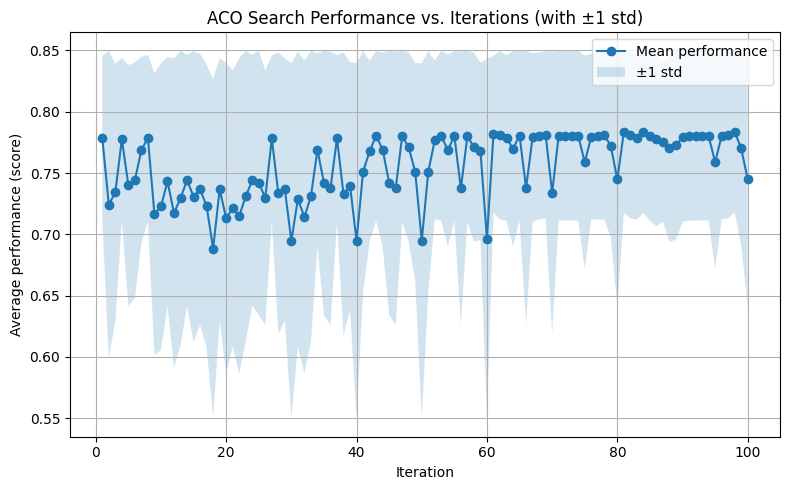

📊 Saved plot with std to: aco_performance_with_std.png


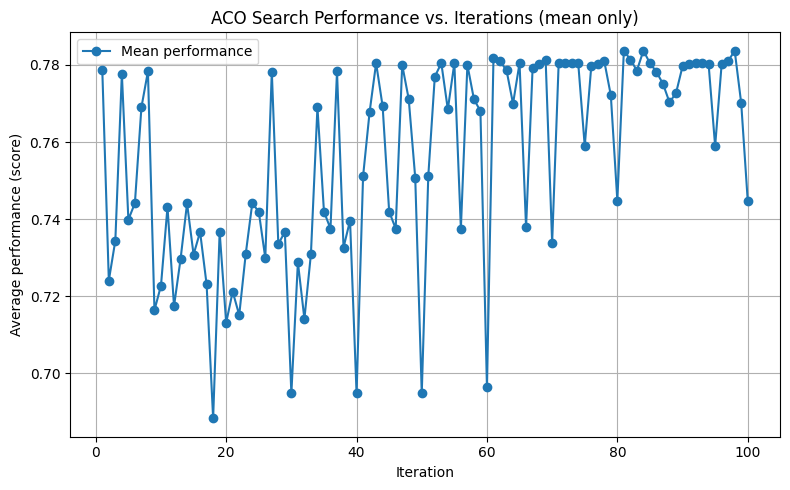

📈 Saved plot without std to: aco_performance_mean.png
✅ Saved iteration performance summary to 'aco_iteration_performance_summary.csv'


In [23]:
# Script for running recommendation + AutoGluon evals (raw vs recommended)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

results = []

print()
print("Training recommender system...")
recommender = MetaPipelineRecommender(train_performance_matrix,
                                      train_metafeatures_df, 
                                      pipeline_configs)

metric_path = recommender.default_metric_path()
if os.path.exists(metric_path):
    print()
    print(f"Loading existing metric model from {metric_path}...")
    recommender.load_metric(metric_path)
else:
    recommender.train_metric(method="regression", hidden_dim=32, epochs=100)
    recommender.save_metric(metric_path)

print()
print("Testing on test datasets...")

for test_dataset in test_datasets:
    print()
    print(f"{'='*60}")
    print(f"TESTING ON {test_dataset['name']} (ID: {test_dataset['id']})")
    print(f"{'='*60}")

    if not (isinstance(test_dataset, dict) and 'X' in test_dataset):
        print("Invalid dataset format, skipping.")
        results.append({
            'dataset_id': test_dataset.get('id'),
            'dataset_name': test_dataset.get('name'),
            'error': 'Invalid dataset format'
        })
        continue

    X = test_dataset['X']
    y = test_dataset['y']
    test_dataset_df = X.copy()
    test_dataset_df['target'] = y

    recommendation = recommender.recommend(
        new_dataset=test_dataset_df,
        target_column='target',
        options=options,
        k=5,
        eval_k=3,
        use_autogluon=True,
        use_aco=True,
        aco_params={
            'n_ants': 10,
            'n_iterations': 10
        },
        time_limit_per_model=10,
        metafeatures_func=lambda df: extract_enhanced_metafeatures(test_dataset)
    )

    if not recommendation:
        print("Could not generate recommendation")
        results.append({
            'dataset_id': test_dataset['id'],
            'dataset_name': test_dataset['name'],
            'error': 'No recommendation generated'
        })
        continue

    rec_cfg = recommendation["pipeline_config"]
    print(f"Recommended pipeline: {rec_cfg['name']}")

    # Optional profiling (raw + recommended pipeline)
    if ENABLE_PROFILING:
        dataset_slug = _slugify(test_dataset['name'])
        raw_df = _build_profile_df(test_dataset)
        _save_profile(
            raw_df,
            title=f"{test_dataset['name']} - Raw",
            filename=f"profile_{dataset_slug}_raw.html",
            sample_n=PROFILE_SAMPLE_N
        )

        rec_slug = _slugify(rec_cfg["name"])
        proc_df = _apply_pipeline_for_profile(test_dataset, rec_cfg)
        _save_profile(
            proc_df,
            title=f"{test_dataset['name']} - {rec_cfg['name']}",
            filename=f"profile_{dataset_slug}_{rec_slug}.html",
            sample_n=PROFILE_SAMPLE_N
        )

    # AutoGluon on raw data
    autogluon_raw = evaluate_autogluon_raw_for_test(test_dataset)
    if not np.isnan(autogluon_raw):
        print(f"AutoGluon RAW score: {autogluon_raw:.4f}")
    else:
        print("AutoGluon RAW score: NaN")

    # AutoGluon on data after recommended pipeline
    autogluon_rec = evaluate_pipeline_with_autogluon_for_test(test_dataset, rec_cfg)
    if not np.isnan(autogluon_rec):
        print(f"AutoGluon RECOMMENDED score: {autogluon_rec:.4f}")
    else:
        print("AutoGluon RECOMMENDED score: NaN")

    results.append({
        'dataset_id': test_dataset['id'],
        'dataset_name': test_dataset['name'],
        'recommended_pipeline': rec_cfg['name'],
        'autogluon_raw': autogluon_raw,
        'autogluon_recommended': autogluon_rec,
        'improvement': autogluon_rec - autogluon_raw if not (np.isnan(autogluon_rec) or np.isnan(autogluon_raw)) else np.nan
    })

# Save results
if results:
    results_df = pd.DataFrame(results)
    results_df.to_csv('test_recommendation_autogluon.csv', index=False)
    print()
    print("Saved results to 'test_recommendation_autogluon.csv'")
